# Introduction



## Problem Statement

Although extensive public data exist on poverty, educational attainment, unemployment, and population, these indicators are frequently stored in siloed systems and analyzed independently. This fragmentation limits the ability of public institutions—particularly those in rural regions—to conduct integrated, county-level assessments of regional need. As a result, many communities lack the analytic capacity to derive actionable insights that could inform local policy, educational programming, or economic development strategies.

**During preliminary modeling and exploratory data analysis (EDA), it became evident that the original focus on the 13 counties in North Central Arkansas (NCA) would not yield the statistical variance necessary to support meaningful clustering or predictive modeling.** The spread of key indicators—especially educational attainment and poverty rates—was too narrow across the NCA region to form clearly distinct groupings or uncover deeper structural patterns. To address this, the scope was expanded to include **all 75 Arkansas counties**, enabling a broader comparative analysis while preserving the original intent of highlighting regional disparities and development potential within the NCA subset.

The core data challenge is *twofold*:

1. **Pattern Identification:** Can we identify meaningful patterns and disparities in educational and economic conditions across counties in Arkansas, with specific attention to regional differences?
2. **Predictive Insight:** Can machine learning models be used to forecast future outcomes or classify counties based on shared vulnerabilities or developmental potential?

Addressing this challenge requires aggregating and standardizing multiple publicly available datasets, performing exploratory data analysis (EDA) to uncover relationships, and applying basic predictive modeling techniques to generate deeper insights. These insights can support more data-informed curriculum design, targeted workforce development programs, and competitive grant applications aligned with regional priorities.

## Section 1:  Work environment setup

In [2]:
# Section 1: Work Environment Setup

# Section 1.1: Imports and Dependencies
# --- Standard Imports ---
import pandas as pd
import numpy as np
import warnings
import logging
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import sys
import os
from pathlib import Path
from scipy import stats
import statsmodels.api as sm


# --- Data Analysis & Machine Learning ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from functools import reduce
from collections import Counter
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point


# --- Geospatial Analysis ---
import geopandas as gpd

# Section 1.2: Environment Configuration
# --- Setup Style and Warnings ---
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 10)
warnings.filterwarnings('ignore')

# --- Paths ---
data_dir = Path("data")
output_dir = Path("ar_outputs")
output_dir.mkdir(exist_ok=True)
figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
map_dir = output_dir / "maps"
map_dir.mkdir(parents=True, exist_ok=True)

log_dir = Path("ar_logs")
log_dir.mkdir(exist_ok=True)

image_dir = Path("ar_outputs/images")
image_dir.mkdir(parents=True, exist_ok=True)

# --- Logging Configuration ---
# Clear existing handlers
logging.getLogger().handlers.clear()

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(log_dir / "project.log", mode='w', encoding='utf-8'),
        logging.StreamHandler(sys.stdout)
    ]
)

#Section 1.3: Color Mapping and LaTeX Export
# --- Global Color Mapping for Key Variables (Percentages) ---
variable_colors = {
    "BachelorsDegreePct": "#2E86C1",    # Bright Blue - Education (positive)
    "HighSchoolGradPct": "#28B463",     # Emerald Green - Education (positive) 
    "PovertyRate": "#E74C3C",           # Bright Red - Economic hardship (negative)
    "UnemploymentRate": "#F39C12"       # Bright Orange - Employment issue (negative)
}



print("Environment ready. Paths and logging configured.")

Environment ready. Paths and logging configured.


# Section 2: Load and prepare Data sets

## Section 2.1: Load utility functions and national datasets

In [3]:
# Section 2.1: Load utility functions and national datasets

# Import custom utility functions
from utils import (
    standardize_column_names,
    filter_to_county_level,
    log_duplicate_attributes,
    clean_and_extract_year,
    nca_counties
)

data_dir = Path("data")
complete_dir = data_dir / "complete_sets"

complete_files = {
    "edu": "Education2023.csv",
    "pop": "PopulationEstimates.csv",
    "poverty": "Poverty2023.csv",
    "unemp": "Unemployment2023.csv"
}

# Choose analysis year
selected_year = '2023'

# Load, clean, and extract year from each dataset
complete_data = {}

for key, filename in complete_files.items():
    path = complete_dir / filename
    try:
        df = pd.read_csv(path, encoding='cp1252')
        df = standardize_column_names(df)
        logging.info(f" {key} columns after cleaning: {df.columns.tolist()}")
        df = filter_to_county_level(df)
        df = clean_and_extract_year(df)

        # Rename fields if necessary
        df.rename(columns={'area_name': 'county'}, inplace=True)

        log_duplicate_attributes(df, key)
        complete_data[key] = df
        logging.info(f"Loaded {filename}: {df.shape[0]} rows")

    except Exception as e:
        logging.error(f" Failed to load {filename}: {e}")


# Confirmation message
logging.info("Utility functions from utils.py loaded successfully.")


2025-07-30 15:30:33,020 [INFO] Utility functions loaded from updated utils.py
2025-07-30 15:30:33,180 [INFO]  edu columns after cleaning: ['ïfips_code', 'state', 'area_name', 'attribute', 'value']
2025-07-30 15:30:33,578 [WARNING] edu has duplicate county-attribute pairs.
2025-07-30 15:30:33,578 [INFO] Loaded Education2023.csv: 169245 rows
2025-07-30 15:30:33,687 [INFO]  pop columns after cleaning: ['fipstxt', 'state', 'area_name', 'attribute', 'value']
2025-07-30 15:30:34,065 [WARNING] pop has duplicate county-attribute pairs.
2025-07-30 15:30:34,066 [INFO] Loaded PopulationEstimates.csv: 205108 rows
2025-07-30 15:30:34,111 [INFO]  poverty columns after cleaning: ['ïfips_code', 'state', 'area_name', 'attribute', 'value']
2025-07-30 15:30:34,245 [WARNING] poverty has duplicate county-attribute pairs.
2025-07-30 15:30:34,246 [INFO] Loaded Poverty2023.csv: 79961 rows
2025-07-30 15:30:34,415 [INFO]  unemp columns after cleaning: ['fips_code', 'state', 'area_name', 'attribute', 'value']
20

## Section 2.2: Load and process national datasets

In [4]:
# Section 2.2: Data Loading Helper Function
def load_and_process_dataset(key, filename, selected_year):
    """
    Helper function to load and process individual datasets.
    Reduces code duplication and makes the process more maintainable.
    """
    path = complete_dir / filename
    try:
        # Load and standardize
        df = pd.read_csv(path, encoding='cp1252')
        df = standardize_column_names(df)
        logging.info(f"{key} columns after cleaning: {df.columns.tolist()}")
        df = filter_to_county_level(df)
        df.rename(columns={'area_name': 'county', 'fips_code': 'fips', 'fipstxt': 'fips'}, inplace=True)
        df['county'] = df['county'].str.strip().str.lower()

        # Extract year from attribute
        if 'attribute' in df.columns:
            df = clean_and_extract_year(df)
            
            # Only filter datasets where year tagging applies
            if key in ['pop', 'poverty', 'unemp']:
                df = df[df['attribute_year'] == selected_year]

        log_duplicate_attributes(df, key)
        logging.info(f"Loaded and processed {filename} with year filter: {selected_year if key != 'edu' else 'N/A'}")
        
        return df
        
    except Exception as e:
        logging.error(f"Failed to load {filename}: {e}")
        return None


### Section 2.3: Load All Datasets

In [5]:
# Section 2.3: Load All Datasets
complete_data = {}
state_lookup = None

for key, filename in complete_files.items():
    df = load_and_process_dataset(key, filename, selected_year)
    if df is not None:
        complete_data[key] = df
        
        # Save state info once from education dataset
        if key == 'edu':
            state_lookup = df[['county', 'state']].drop_duplicates().copy()
            state_lookup['county'] = state_lookup['county'].str.lower().str.strip()
            state_lookup['state'] = state_lookup['state'].str.upper().str.strip()

2025-07-30 15:30:35,281 [INFO] edu columns after cleaning: ['ïfips_code', 'state', 'area_name', 'attribute', 'value']
2025-07-30 15:30:35,699 [WARNING] edu has duplicate county-attribute pairs.
2025-07-30 15:30:35,700 [INFO] Loaded and processed Education2023.csv with year filter: N/A
2025-07-30 15:30:35,838 [INFO] pop columns after cleaning: ['fipstxt', 'state', 'area_name', 'attribute', 'value']
2025-07-30 15:30:36,227 [WARNING] pop has duplicate county-attribute pairs.
2025-07-30 15:30:36,227 [INFO] Loaded and processed PopulationEstimates.csv with year filter: 2023
2025-07-30 15:30:36,258 [INFO] poverty columns after cleaning: ['ïfips_code', 'state', 'area_name', 'attribute', 'value']
2025-07-30 15:30:36,404 [WARNING] poverty has duplicate county-attribute pairs.
2025-07-30 15:30:36,405 [INFO] Loaded and processed Poverty2023.csv with year filter: 2023
2025-07-30 15:30:36,537 [INFO] unemp columns after cleaning: ['fips_code', 'state', 'area_name', 'attribute', 'value']
2025-07-30 1

## Section 2.4: Subset Arkansas 

In [6]:
# Section 2.4: Create Arkansas-Wide Dataset
def get_ar_subset(df, dataset_name):
    """Helper function to subset and clean Arkansas counties"""
    df = df.copy()
    df = df[df['state'].str.upper() == 'AR']
    df['county'] = (
        df['county']
        .str.replace(" county", "", regex=False)
        .str.replace(", ar", "", regex=False)
        .str.strip()
        .str.lower()
    )
    logging.info(f"{dataset_name.upper()} → AR rows: {df.shape[0]}")
    return df

# Get AR-wide subsets
edu_ar = get_ar_subset(complete_data['edu'], 'edu')
poverty_ar = get_ar_subset(complete_data['poverty'], 'poverty')
unemp_ar = get_ar_subset(complete_data['unemp'], 'unemp')
pop_ar = get_ar_subset(complete_data['pop'], 'pop')

# Pivot to wide format
edu_wide_ar = edu_ar.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')
poverty_wide_ar = poverty_ar.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')
unemp_wide_ar = unemp_ar.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')
pop_wide_ar = pop_ar.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')

# Merge datasets
df_ar = reduce(
    lambda left, right: pd.merge(left, right, on='county', how='outer'),
    [edu_wide_ar, poverty_wide_ar, unemp_wide_ar, pop_wide_ar]
)

# Flatten column names
df_ar.columns = [col if isinstance(col, str) else col[1] for col in df_ar.columns]

# Save raw merged data
df_ar.to_csv(output_dir / f"ar_dataset_cleaned_{selected_year}.csv")
logging.info(f"AR final dataset saved: ar_dataset_cleaned_{selected_year}.csv")
print(f"AR dataset ready with shape: {df_ar.shape}")


2025-07-30 15:30:37,406 [INFO] EDU → AR rows: 3948
2025-07-30 15:30:37,415 [INFO] POVERTY → AR rows: 457
2025-07-30 15:30:37,420 [INFO] UNEMP → AR rows: 450
2025-07-30 15:30:37,442 [INFO] POP → AR rows: 1275
2025-07-30 15:30:37,459 [INFO] AR final dataset saved: ar_dataset_cleaned_2023.csv
AR dataset ready with shape: (75, 83)


### Section 2.5: Finalize Arkansas Dataset

In [7]:
# Section 2.5: Finalize Arkansas Dataset
print("Columns BEFORE renaming (AR):")
print(df_ar.columns.tolist())

# Ensure 'county' is a column, not index
df_ar = df_ar.reset_index()

# Rename long education/population columns
df_ar = df_ar.rename(columns={
    "percent of adults who are high school graduates (or equivalent), 2019-23": "HighSchoolGradRate",
    "percent of adults with a bachelor's degree or higher, 2019-23": "BachelorsDegreeRate",
    "pctpovall_2023": "PovertyRate",
    "unemployment_rate_2023": "UnemploymentRate",
    "pop_estimate_2023": "Population"
})

# Compute percentage variables (confirm your inputs are raw counts)
df_ar['BachelorsDegreePct'] = (df_ar['BachelorsDegreeRate'] / df_ar['Population']) * 100
df_ar['HighSchoolGradPct'] = (df_ar['HighSchoolGradRate'] / df_ar['Population']) * 100

# Final variable list
summary_vars_ar = [
    'BachelorsDegreePct',
    'HighSchoolGradPct',
    'PovertyRate',
    'UnemploymentRate',
    'Population'
]

# Filter to only rows with valid population
df_ar_final = df_ar[summary_vars_ar + ['county']].dropna(subset=['Population']).copy()
df_ar_final = df_ar_final.set_index('county')

# Tag NCA counties for comparison
nca_cleaned = [c.lower().strip() for c in nca_counties]
df_ar_final['IsNCA'] = df_ar_final.index.str.lower().isin(nca_cleaned).astype(int)

# Save finalized dataset
df_ar_final.to_csv(output_dir / "ar_final.csv", index=True)
logging.info("AR Final dataset saved: ar_final.csv")

# Display summary
print("AR dataset finalized with shape:", df_ar_final.shape)
print("Preview:")
display(df_ar_final.head())

Columns BEFORE renaming (AR):
['2013 rural-urban continuum code', '2013 urban influence code', '2023 rural-urban continuum code', '2024 urban influence code', "bachelor's degree or higher, 1990", "bachelor's degree or higher, 2000", "bachelor's degree or higher, 2008-12", "bachelor's degree or higher, 2019-23", 'four years of college or higher, 1970', 'four years of college or higher, 1980', 'high school diploma only, 1970', 'high school diploma only, 1980', 'high school graduate (or equivalency), 1990', 'high school graduate (or equivalency), 2000', 'high school graduate (or equivalency), 2008-12', 'high school graduate (or equivalency), 2019-23', 'less than a high school diploma, 1970', 'less than a high school diploma, 1980', 'less than high school graduate, 1990', 'less than high school graduate, 2000', 'less than high school graduate, 2008-12', 'less than high school graduate, 2019-23', 'percent of adults completing four years of college or higher, 1970', 'percent of adults comple

,BachelorsDegreePct,HighSchoolGradPct,PovertyRate,UnemploymentRate,Population,IsNCA
county,,,,,,
arkansas,0.153991,0.210868,15.4,2.7,16307.0,0
ashley,0.066686,0.285208,18.4,5.6,18262.0,0
baxter,0.043729,0.080813,16.0,3.6,42875.0,1
benton,0.011770,0.009046,7.8,2.4,311013.0,0
boone,0.042331,0.092508,14.9,3.1,38530.0,0


### Section 2.6: Create Arkansas County Maps

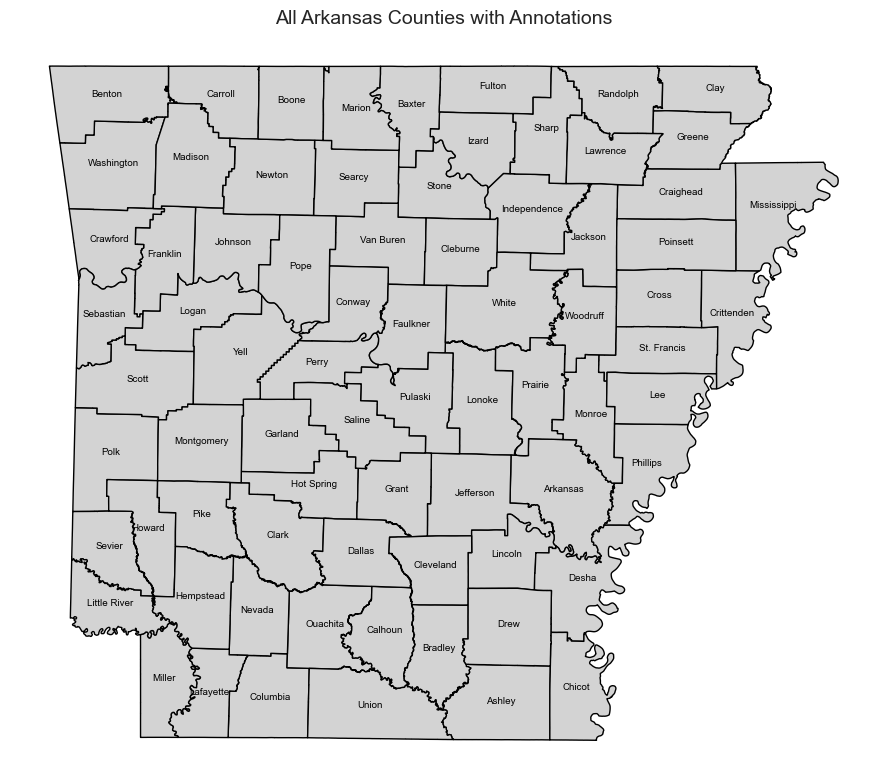

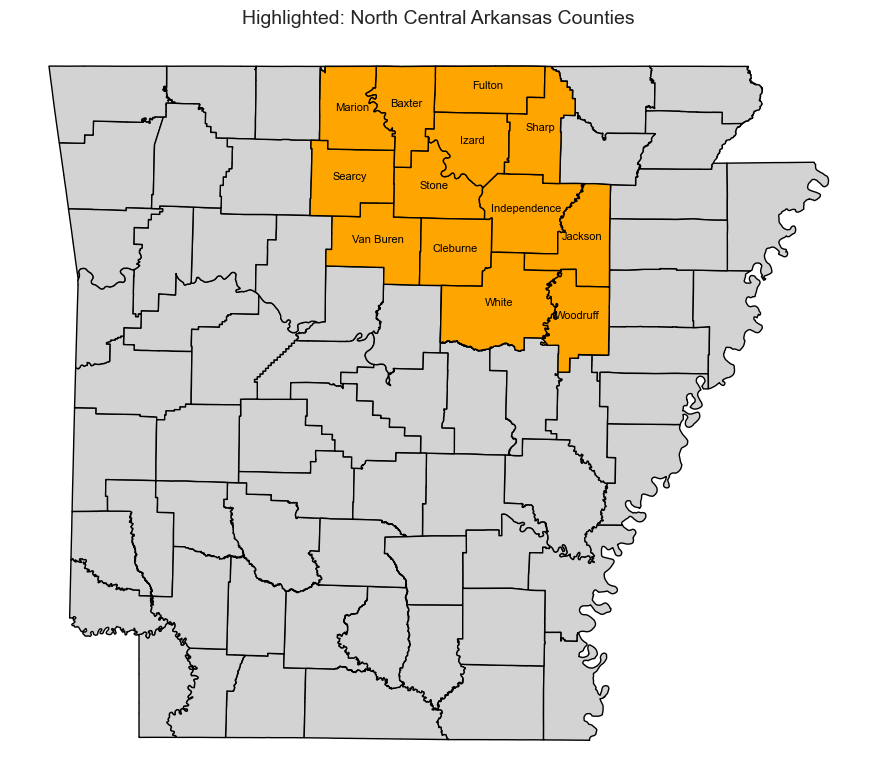

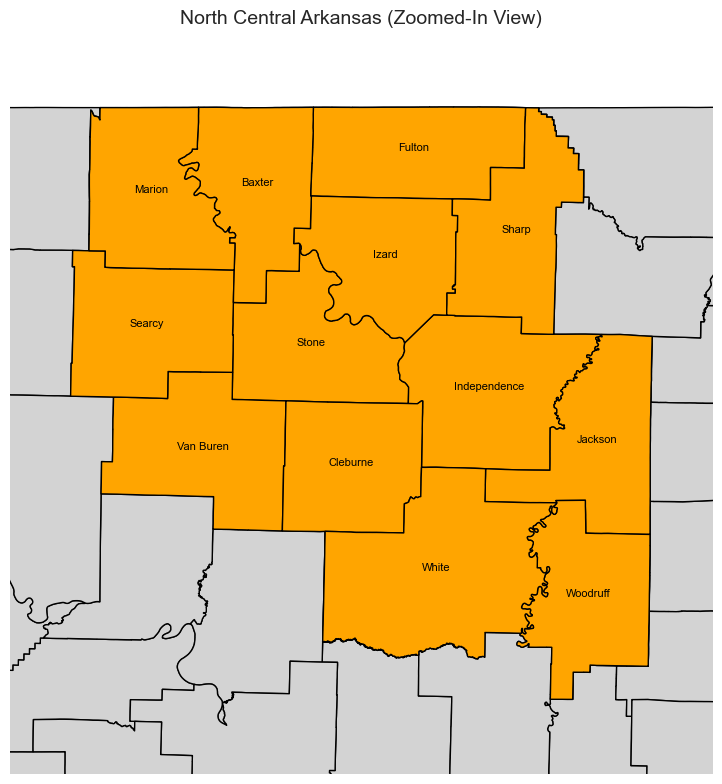

Section 2 complete: Datasets loaded, processed, and Arkansas maps created.


In [8]:
# Section 2.6: Create Arkansas County Maps
# Mapping Arkansas Counties
# Path to the TIGER shapefile
shapefile_path = Path("data") / "tl_2023_us_county.shp"

# Load all U.S. counties
us_counties = gpd.read_file(shapefile_path)
gdf_counties = us_counties.copy()

# Filter to Arkansas counties only (STATEFP = '05')
arkansas = us_counties[us_counties['STATEFP'] == '05'].copy()

arkansas['County'] = arkansas['NAME']

# Map 1: All Arkansas counties with labels
fig1, ax1 = plt.subplots(figsize=(12, 8))
arkansas.plot(ax=ax1, color='lightgrey', edgecolor='black')

# Annotate ALL counties in Arkansas
for idx, row in arkansas.iterrows():
    ax1.annotate(
        text=row['NAME'],
        xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
        ha='center',
        fontsize=7,
        color='black'
    )

ax1.set_title("All Arkansas Counties with Annotations", fontsize=14)
ax1.axis('off')
plt.tight_layout()

# Save the figure
fig1.savefig(map_dir / "arkansas_all_counties_annotated.png", dpi=300)
plt.show()

# Map 2: NCA counties highlighted
# Normalize names for shapefile match
nca_names = [c.title() for c in nca_counties]

# Subset the GeoDataFrame
nca = arkansas[arkansas['NAME'].isin(nca_names)].copy()

# Plot with NCA counties highlighted
fig2, ax2 = plt.subplots(figsize=(12, 8))
arkansas.plot(ax=ax2, color='lightgrey', edgecolor='black')
nca.plot(ax=ax2, color='orange', edgecolor='black')

# Label only NCA counties
for idx, row in nca.iterrows():
    ax2.annotate(
        text=row['NAME'],
        xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
        ha='center',
        fontsize=8,
        color='black'
    )

ax2.set_title("Highlighted: North Central Arkansas Counties", fontsize=14)
ax2.axis('off')
plt.tight_layout()

# Save figure
fig2.savefig(map_dir/ "arkansas_nca_highlighted.png", dpi=300)
plt.show()

# Map 3: Zoomed view of NCA counties
fig3, ax3 = plt.subplots(figsize=(12, 8))
arkansas.plot(ax=ax3, color='lightgrey', edgecolor='black')
nca.plot(ax=ax3, color='orange', edgecolor='black')

# Label only NCA counties
for idx, row in nca.iterrows():
    ax3.annotate(
        text=row['NAME'],
        xy=(row['geometry'].centroid.x, row['geometry'].centroid.y),
        ha='center',
        fontsize=8,
        color='black'
    )

# Zoom into the NCA bounding box
minx, miny, maxx, maxy = nca.total_bounds
ax3.set_xlim(minx - 0.2, maxx + 0.2)
ax3.set_ylim(miny - 0.2, maxy + 0.2)

ax3.set_title("North Central Arkansas (Zoomed-In View)", fontsize=14)
ax3.axis('off')
plt.tight_layout()

# Save zoomed map
fig3.savefig(map_dir / "arkansas_nca_zoomed.png", dpi=300)
plt.show()

print("Section 2 complete: Datasets loaded, processed, and Arkansas maps created.")

## Section 2.7  Data quality validation

In [9]:
# Data quality validation
print("Data Quality Report:")
for var in ['BachelorsDegreePct', 'PovertyRate', 'UnemploymentRate']:
    missing_pct = (df_ar_final[var].isna().sum() / len(df_ar_final)) * 100
    print(f"{var}: {missing_pct:.1f}% missing")

Data Quality Report:
BachelorsDegreePct: 0.0% missing
PovertyRate: 0.0% missing
UnemploymentRate: 0.0% missing


# Section 3 Exploratory Data Analysis and Visualization 

## Section 3.1 Dataset Overview

In [10]:
# Section 3.1: Dataset Overview
print("Dataset Dimensions (rows, columns):", df_ar_final.shape)

print("\nColumn Names:")
for col in df_ar_final.columns:
    print(" -", col)

print("\nDataset Info:")
df_ar_final.info()

print("\nPreview of First 5 Rows:")
display(df_ar_final.head())

# Verify the Counties in NCA
print("\nNCA County Distribution:")
print(df_ar_final['IsNCA'].value_counts())

Dataset Dimensions (rows, columns): (75, 6)

Column Names:
 - BachelorsDegreePct
 - HighSchoolGradPct
 - PovertyRate
 - UnemploymentRate
 - Population
 - IsNCA

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 75 entries, arkansas to yell
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BachelorsDegreePct  75 non-null     float64
 1   HighSchoolGradPct   75 non-null     float64
 2   PovertyRate         75 non-null     float64
 3   UnemploymentRate    75 non-null     float64
 4   Population          75 non-null     float64
 5   IsNCA               75 non-null     int64  
dtypes: float64(5), int64(1)
memory usage: 4.1+ KB

Preview of First 5 Rows:


,BachelorsDegreePct,HighSchoolGradPct,PovertyRate,UnemploymentRate,Population,IsNCA
county,,,,,,
arkansas,0.153991,0.210868,15.4,2.7,16307.0,0
ashley,0.066686,0.285208,18.4,5.6,18262.0,0
baxter,0.043729,0.080813,16.0,3.6,42875.0,1
benton,0.011770,0.009046,7.8,2.4,311013.0,0
boone,0.042331,0.092508,14.9,3.1,38530.0,0



NCA County Distribution:
IsNCA
0    62
1    13
Name: count, dtype: int64


## Section 3.2 Data Dictionary 

In [11]:
# Section 3.2: Data Dictionary
# Manually define the variable descriptions (aligned with df_ar_final)
data_dictionary = {
    "BachelorsDegreePct": "Percent of population with a bachelor's degree (calculated from rate and population)",
    "HighSchoolGradPct": "Percent of population with a high school diploma or equivalent (calculated)",
    "PovertyRate": "Estimated percentage of residents living below the poverty line (2023)",
    "UnemploymentRate": "Estimated unemployment rate of labor force (2023)",
    "Population": "Estimated total population of the county (2023)"
}

# Convert to a DataFrame for display and export
dictionary_df = pd.DataFrame.from_dict(data_dictionary, orient='index', columns=['Description'])
dictionary_df.index.name = 'Variable'

# Display and save
display(dictionary_df)
dictionary_df.to_csv(output_dir / "ar_data_dictionary.csv")
logging.info("Data dictionary saved to: ar_data_dictionary.csv")

,Description
Variable,
BachelorsDegreePct,Percent of population with a bachelor's degree...
HighSchoolGradPct,Percent of population with a high school diplo...
PovertyRate,Estimated percentage of residents living below...
UnemploymentRate,Estimated unemployment rate of labor force (2023)
Population,Estimated total population of the county (2023)


2025-07-30 15:30:40,411 [INFO] Data dictionary saved to: ar_data_dictionary.csv


## Section 3.3 Load Geographic Data for Mapping

In [12]:
# Section 3.3: Load Geographic Data for Mapping
# Load US counties shapefile and subset to Arkansas
shapefile_path = Path("data") / "tl_2023_us_county.shp"
us_counties = gpd.read_file(shapefile_path)
arkansas = us_counties[us_counties['STATEFP'] == '05'].copy()
arkansas['County'] = arkansas['NAME'].str.title()

# Prepare for merge and mapping
arkansas_geo = arkansas.copy()

# Convert utils-based NCA list to Title Case for matching
nca_names = [c.title() for c in nca_counties]
nca_outline = arkansas_geo[arkansas_geo['County'].isin(nca_names)]

# Fix index of data frame to Title Case for proper matching
df_ar_final.index = df_ar_final.index.str.title()

## Section 3.4: Variable Analysis and Summary Statistics

In [13]:
# Section 3.4: Variable Analysis and Summary Statistics
percent_vars = [
    'BachelorsDegreePct',
    'HighSchoolGradPct', 
    'PovertyRate',
    'UnemploymentRate'
]

summary_vars_ar = percent_vars + ['Population']

# Generate auto-summary for each variable
summary_lines = []

for var in percent_vars:
    series = df_ar_final[var]
    max_val = series.max()
    min_val = series.min()
    mean_val = series.mean()
    std_val = series.std()
    
    max_county = series.idxmax()
    min_county = series.idxmin()
    
    # Format summary
    summary = (
        f"\nInsight Summary for {var}:\n"
        f"  - Average across counties: {mean_val:.3f}\n"
        f"  - Standard deviation: {std_val:.3f}\n"
        f"  - Highest: {max_val:.3f} ({max_county})\n"
        f"  - Lowest: {min_val:.3f} ({min_county})\n"
    )
    
    print(summary)
    summary_lines.append(summary)

# Save insight summaries
insight_summary_path = figures_dir / "ar_insight_summaries.txt"
with open(insight_summary_path, "w", encoding="utf-8") as f:
    f.writelines(summary_lines)
logging.info(f"Insight summaries saved to {insight_summary_path}")


Insight Summary for BachelorsDegreePct:
  - Average across counties: 0.097
  - Standard deviation: 0.069
  - Highest: 0.390 (Calhoun)
  - Lowest: 0.009 (Pulaski)


Insight Summary for HighSchoolGradPct:
  - Average across counties: 0.262
  - Standard deviation: 0.206
  - Highest: 0.918 (Calhoun)
  - Lowest: 0.006 (Pulaski)


Insight Summary for PovertyRate:
  - Average across counties: 18.683
  - Standard deviation: 5.377
  - Highest: 38.700 (Lee)
  - Lowest: 7.800 (Benton)


Insight Summary for UnemploymentRate:
  - Average across counties: 3.812
  - Standard deviation: 0.809
  - Highest: 6.500 (Phillips)
  - Lowest: 2.300 (Washington)

2025-07-30 15:30:40,784 [INFO] Insight summaries saved to ar_outputs\figures\ar_insight_summaries.txt


## Section 3.5: Create County Profiles (Highest, Lowest, and NCA Counties Only)

In [14]:
# Section 3.5: Create County Profiles (Highest, Lowest, and NCA Counties Only)
def create_county_profiles():
    """Create profiles only for highest, lowest, and NCA counties for each variable"""
    
    export_vars = percent_vars + ['Population']
    counties_to_profile = set()
    
    # Find highest and lowest counties for each variable
    for var in percent_vars:
        series = df_ar_final[var]
        counties_to_profile.add(series.idxmax())  # Highest
        counties_to_profile.add(series.idxmin())  # Lowest
    
    # Add all NCA counties
    nca_counties_in_data = df_ar_final[df_ar_final['IsNCA'] == 1].index.tolist()
    counties_to_profile.update(nca_counties_in_data)
    
    print(f"\nCreating profiles for {len(counties_to_profile)} counties:")
    print("- Highest and lowest performers for each variable")
    print("- All NCA counties")
    print(f"Counties: {sorted(counties_to_profile)}")
    
    # Create profiles for selected counties only
    for county in counties_to_profile:
        if county in df_ar_final.index:
            row = df_ar_final.loc[county, export_vars]
            county_df = row.to_frame(name='Value')
            county_df.index.name = 'Variable'
            
            filename = f"{county.lower().replace(' ', '_')}_profile.csv"
            county_df.to_csv(figures_dir / filename)
            logging.info(f"Saved profile: {filename}")

create_county_profiles()


Creating profiles for 19 counties:
- Highest and lowest performers for each variable
- All NCA counties
Counties: ['Baxter', 'Benton', 'Calhoun', 'Cleburne', 'Fulton', 'Independence', 'Izard', 'Jackson', 'Lee', 'Marion', 'Phillips', 'Pulaski', 'Searcy', 'Sharp', 'Stone', 'Van Buren', 'Washington', 'White', 'Woodruff']
2025-07-30 15:30:40,822 [INFO] Saved profile: searcy_profile.csv
2025-07-30 15:30:40,824 [INFO] Saved profile: calhoun_profile.csv
2025-07-30 15:30:40,826 [INFO] Saved profile: woodruff_profile.csv
2025-07-30 15:30:40,827 [INFO] Saved profile: cleburne_profile.csv
2025-07-30 15:30:40,829 [INFO] Saved profile: lee_profile.csv
2025-07-30 15:30:40,830 [INFO] Saved profile: white_profile.csv
2025-07-30 15:30:40,831 [INFO] Saved profile: stone_profile.csv
2025-07-30 15:30:40,832 [INFO] Saved profile: jackson_profile.csv
2025-07-30 15:30:40,834 [INFO] Saved profile: baxter_profile.csv
2025-07-30 15:30:40,835 [INFO] Saved profile: van_buren_profile.csv
2025-07-30 15:30:40,836 [

## Section 3.6: Create Choropleth Maps for Each Variable


Creating choropleth maps for each variable...

Processing BachelorsDegreePct...
2025-07-30 15:30:40,856 [INFO] Saved data table: ar_bachelorsdegreepct_by_county.csv


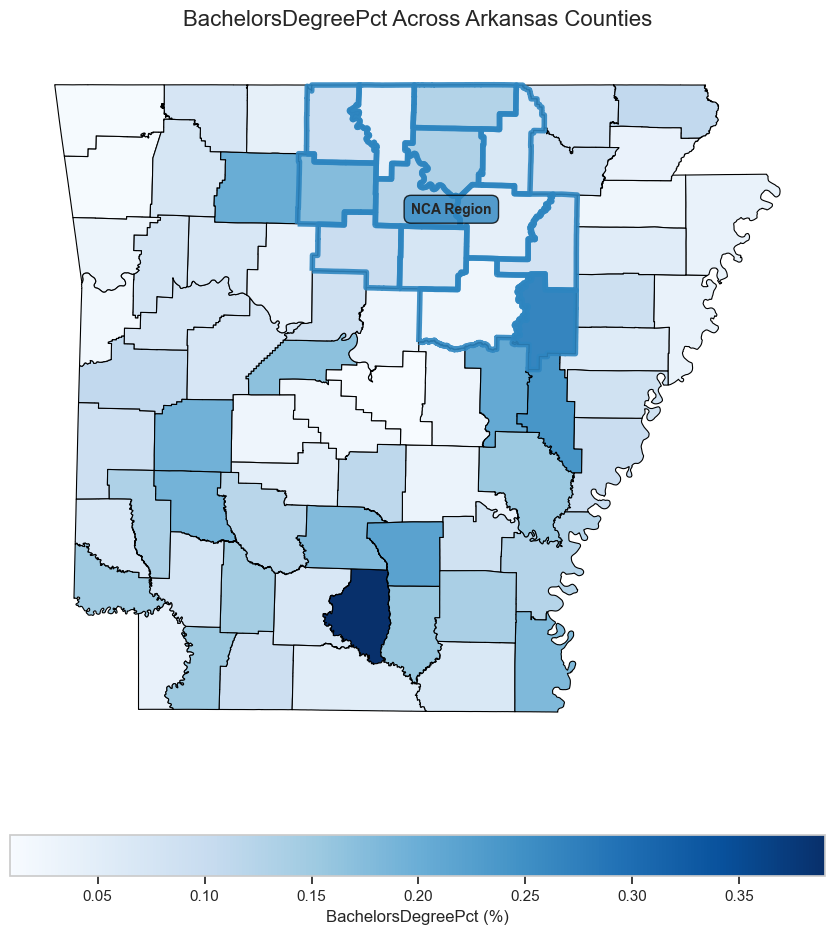

2025-07-30 15:30:41,493 [INFO] Saved choropleth map: ar_bachelorsdegreepct_choropleth_map.png

Processing HighSchoolGradPct...
2025-07-30 15:30:41,499 [INFO] Saved data table: ar_highschoolgradpct_by_county.csv


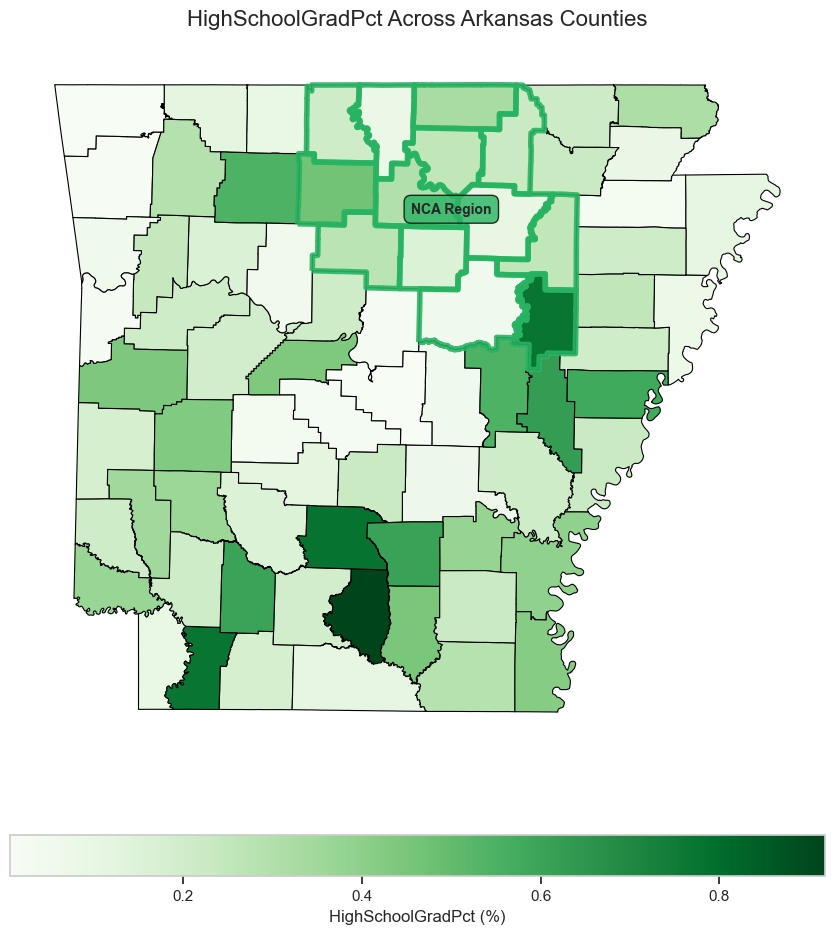

2025-07-30 15:30:42,083 [INFO] Saved choropleth map: ar_highschoolgradpct_choropleth_map.png

Processing PovertyRate...
2025-07-30 15:30:42,085 [INFO] Saved data table: ar_povertyrate_by_county.csv


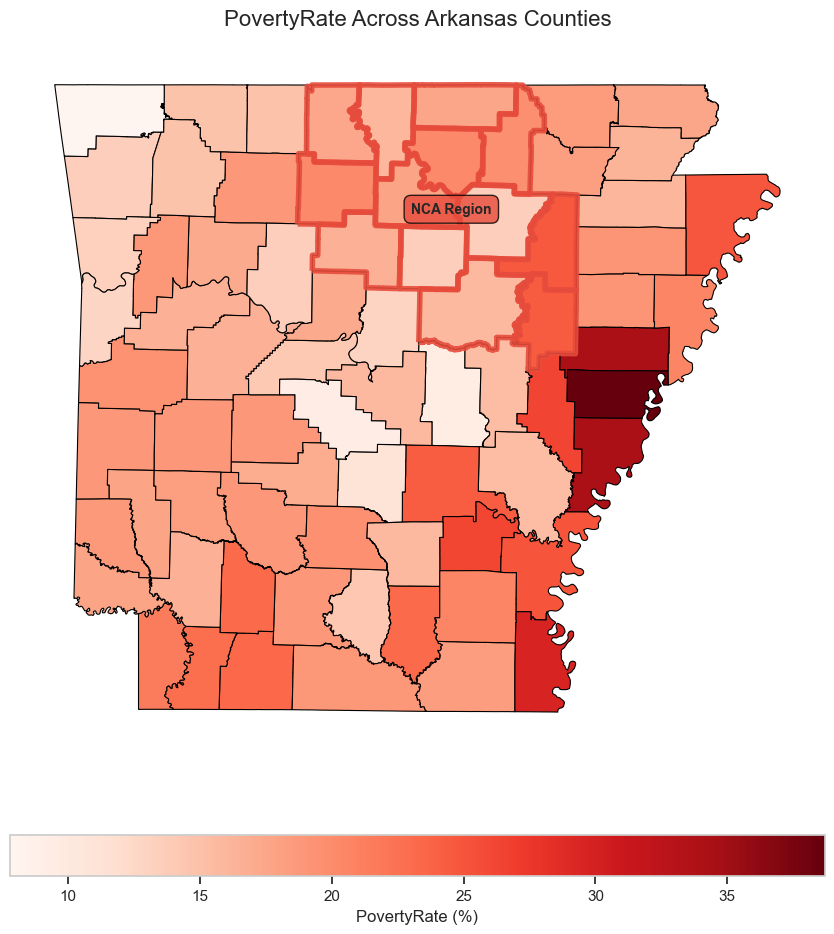

2025-07-30 15:30:42,732 [INFO] Saved choropleth map: ar_povertyrate_choropleth_map.png

Processing UnemploymentRate...
2025-07-30 15:30:42,735 [INFO] Saved data table: ar_unemploymentrate_by_county.csv


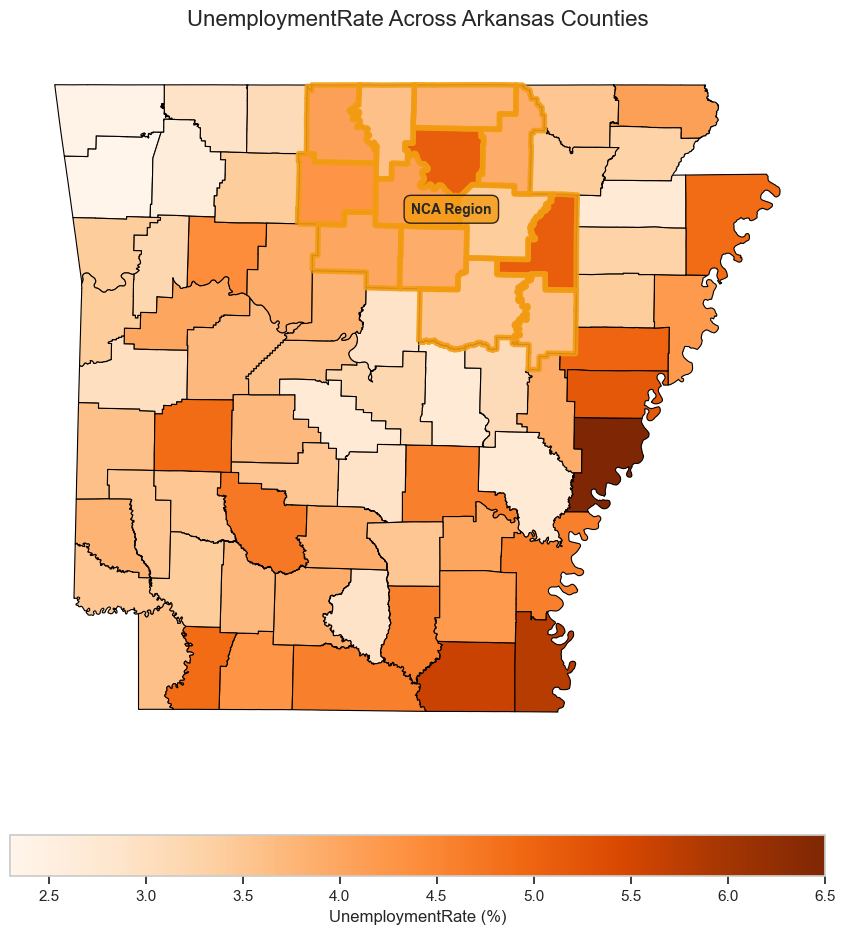

2025-07-30 15:30:43,543 [INFO] Saved choropleth map: ar_unemploymentrate_choropleth_map.png

 Section 3 complete: Data analysis, selective county profiles, and choropleth maps created.


In [15]:
# Section 3.6: Create Choropleth Maps for Each Variable
print("\nCreating choropleth maps for each variable...")

for var in percent_vars:
    print(f"\nProcessing {var}...")
    
    # Extract and prepare the data
    var_table = df_ar_final[[var]].copy()
    var_table.columns = ['Value']
    var_table.index.name = 'County'
    var_table = var_table.round(3)
    
    # Save data table
    filename_csv = f"ar_{var.lower()}_by_county.csv"
    var_table.to_csv(figures_dir / filename_csv)
    logging.info(f"Saved data table: {filename_csv}")
    
    # Merge with geometry
    map_df = arkansas_geo.merge(var_table, on='County', how='left')
    
    # Use global color mapping from Section 1 with better choropleth schemes
    if var in variable_colors:
        base_color = variable_colors[var]
        
        # Create much better, readable color schemes
        if var == 'BachelorsDegreePct':
            cmap = 'Blues'  # Light blue to dark blue - easy to read
        elif var == 'HighSchoolGradPct':
            cmap = 'Greens'  # Light green to dark green - clear progression
        elif var == 'PovertyRate':
            cmap = 'Reds'  # Light red to dark red - intuitive for "bad" metric
        elif var == 'UnemploymentRate':
            cmap = 'Oranges'  # Light orange to dark orange - clear and readable
        else:
            cmap = 'Blues'  # Fallback
    else:
        cmap = 'Blues'  # Fallback for unmapped variables
    
    # Create choropleth map
    fig, ax = plt.subplots(figsize=(12, 10))
    map_df.plot(
        column='Value',
        cmap=cmap,
        linewidth=0.8,
        ax=ax,
        edgecolor='black',
        legend=True,
        legend_kwds={'label': f"{var} (%)", 'shrink': 0.7, 'orientation': 'horizontal', 'pad': 0.1}
    )
    
    # Overlay NCA counties with the global variable color
    nca_outline.boundary.plot(ax=ax, color=variable_colors.get(var, 'red'), linewidth=4, alpha=0.9)
    
    # Add NCA label with background color matching the variable
    if len(nca_outline) > 0:
        # Get centroid of NCA region for label placement
        nca_bounds = nca_outline.total_bounds
        nca_center_x = (nca_bounds[0] + nca_bounds[2]) / 2
        nca_center_y = (nca_bounds[1] + nca_bounds[3]) / 2
        ax.annotate('NCA Region', xy=(nca_center_x, nca_center_y), 
                   xytext=(10, 10), textcoords='offset points',
                   bbox=dict(boxstyle='round,pad=0.5', 
                            facecolor=variable_colors.get(var, 'yellow'), 
                            alpha=0.8, 
                            edgecolor='black'),
                   fontsize=10, ha='center', weight='bold')
    
    # Map styling
    ax.set_title(f"{var} Across Arkansas Counties", fontsize=16, pad=20)
    ax.axis('off')
    plt.tight_layout()
    
    # Save map
    filename_map = f"ar_{var.lower()}_choropleth_map.png"
    fig.savefig(figures_dir / filename_map, dpi=300, bbox_inches='tight')
    plt.show()
    logging.info(f"Saved choropleth map: {filename_map}")

print("\n Section 3 complete: Data analysis, selective county profiles, and choropleth maps created.")

# Section 4 Statistical Visualization

## Section 4.1: Variable Review

In [16]:
# Section 4.1: Define Variables and Preview Data
# Define key indicators for visualization (remove redundant definitions)
percent_vars = [
    'BachelorsDegreePct',
    'HighSchoolGradPct', 
    'PovertyRate',
    'UnemploymentRate'
]

all_vars = percent_vars + ['Population']

print("Variables selected for visualization:")
for var in percent_vars:
    print(f" - {var}")

print("\nPreview of data to visualize:")
display(df_ar_final[all_vars].head())

# Save preview for documentation
df_ar_final[all_vars].head().to_csv(figures_dir / "visualization_data_preview.csv")
logging.info("Saved visualization data preview.")

Variables selected for visualization:
 - BachelorsDegreePct
 - HighSchoolGradPct
 - PovertyRate
 - UnemploymentRate

Preview of data to visualize:


,BachelorsDegreePct,HighSchoolGradPct,PovertyRate,UnemploymentRate,Population
county,,,,,
Arkansas,0.153991,0.210868,15.4,2.7,16307.0
Ashley,0.066686,0.285208,18.4,5.6,18262.0
Baxter,0.043729,0.080813,16.0,3.6,42875.0
Benton,0.011770,0.009046,7.8,2.4,311013.0
Boone,0.042331,0.092508,14.9,3.1,38530.0


2025-07-30 15:30:43,558 [INFO] Saved visualization data preview.


## Section 4.2 Distribution Analysis


Creating distribution plots...
2025-07-30 15:30:43,823 [INFO] Saved distribution plot: distribution_bachelorsdegreepct.png


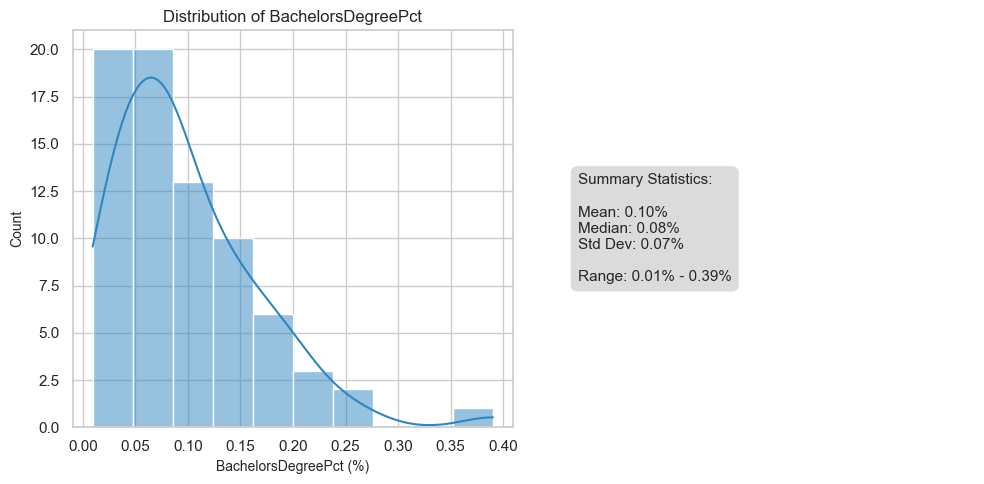

2025-07-30 15:30:44,065 [INFO] Saved distribution plot: distribution_highschoolgradpct.png


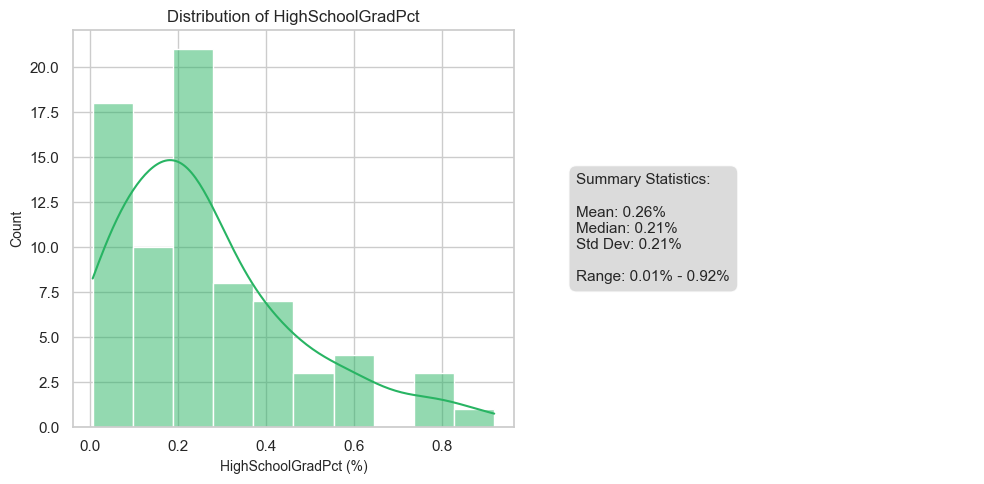

2025-07-30 15:30:44,309 [INFO] Saved distribution plot: distribution_povertyrate.png


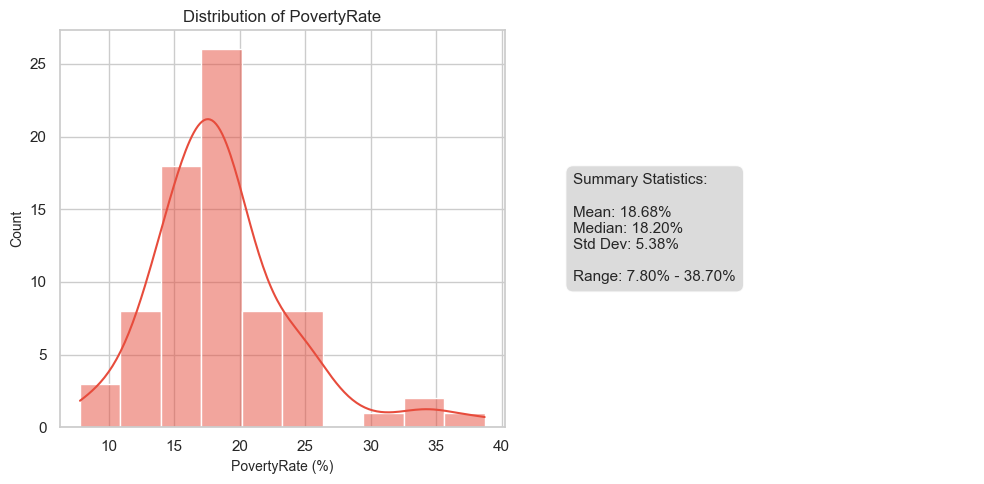

2025-07-30 15:30:44,549 [INFO] Saved distribution plot: distribution_unemploymentrate.png


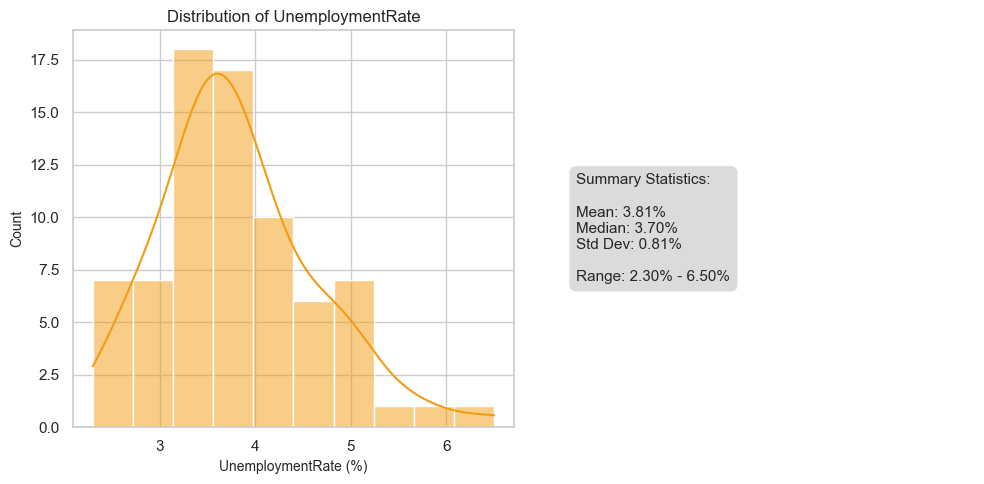

In [17]:
# Section 4.2: Distribution Analysis
print("\nCreating distribution plots...")

for var in percent_vars:
    plt.figure(figsize=(10, 5))
    
    # Create subplot with histogram and summary stats
    plt.subplot(1, 2, 1)
    sns.histplot(df_ar_final[var], kde=True, bins=10, color=variable_colors.get(var, 'skyblue'))
    plt.title(f"Distribution of {var}", fontsize=12)
    plt.xlabel(f"{var} (%)", fontsize=10)
    plt.ylabel("Count", fontsize=10)
    
    # Add summary statistics text
    plt.subplot(1, 2, 2)
    plt.axis('off')
    
    # Calculate statistics
    mean_val = df_ar_final[var].mean()
    median_val = df_ar_final[var].median()
    std_val = df_ar_final[var].std()
    
    stats_text = f"""Summary Statistics:
    
Mean: {mean_val:.2f}%
Median: {median_val:.2f}%
Std Dev: {std_val:.2f}%
    
Range: {df_ar_final[var].min():.2f}% - {df_ar_final[var].max():.2f}%"""
    
    plt.text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
    
    plt.tight_layout()
    
    # Save
    filename = f"distribution_{var.lower()}.png"
    plt.savefig(image_dir / filename, dpi=300, bbox_inches='tight')
    logging.info(f"Saved distribution plot: {filename}")
    plt.show()


## Section 4.3 NCA vs Non-NCA Comparison Plots


Creating NCA comparison visualizations...
2025-07-30 15:30:45,848 [INFO] Saved NCA comparison: nca_comparison_bachelorsdegreepct.png


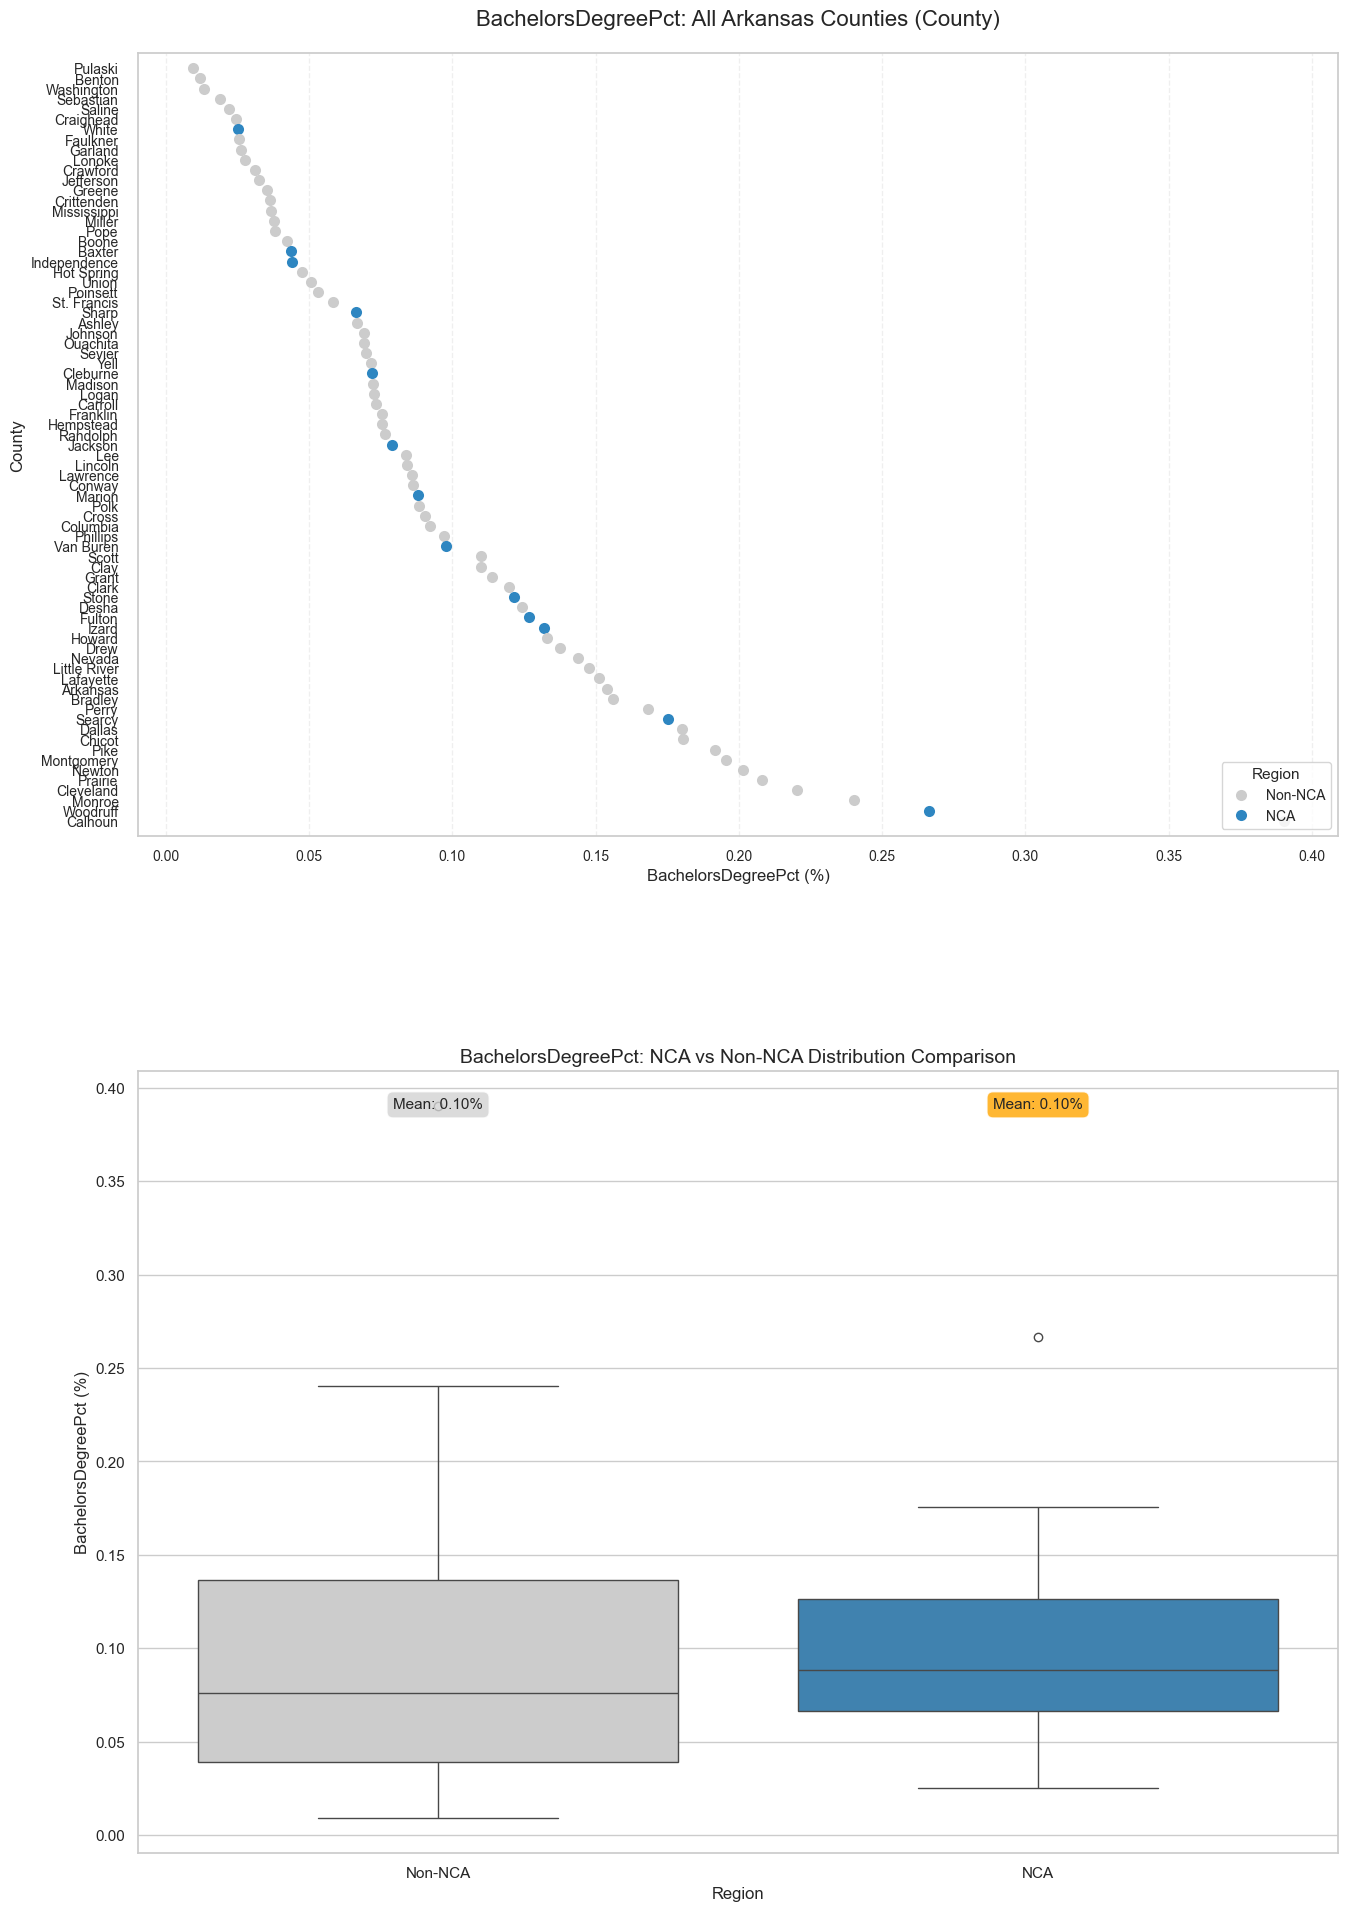

2025-07-30 15:30:47,476 [INFO] Saved NCA comparison: nca_comparison_highschoolgradpct.png


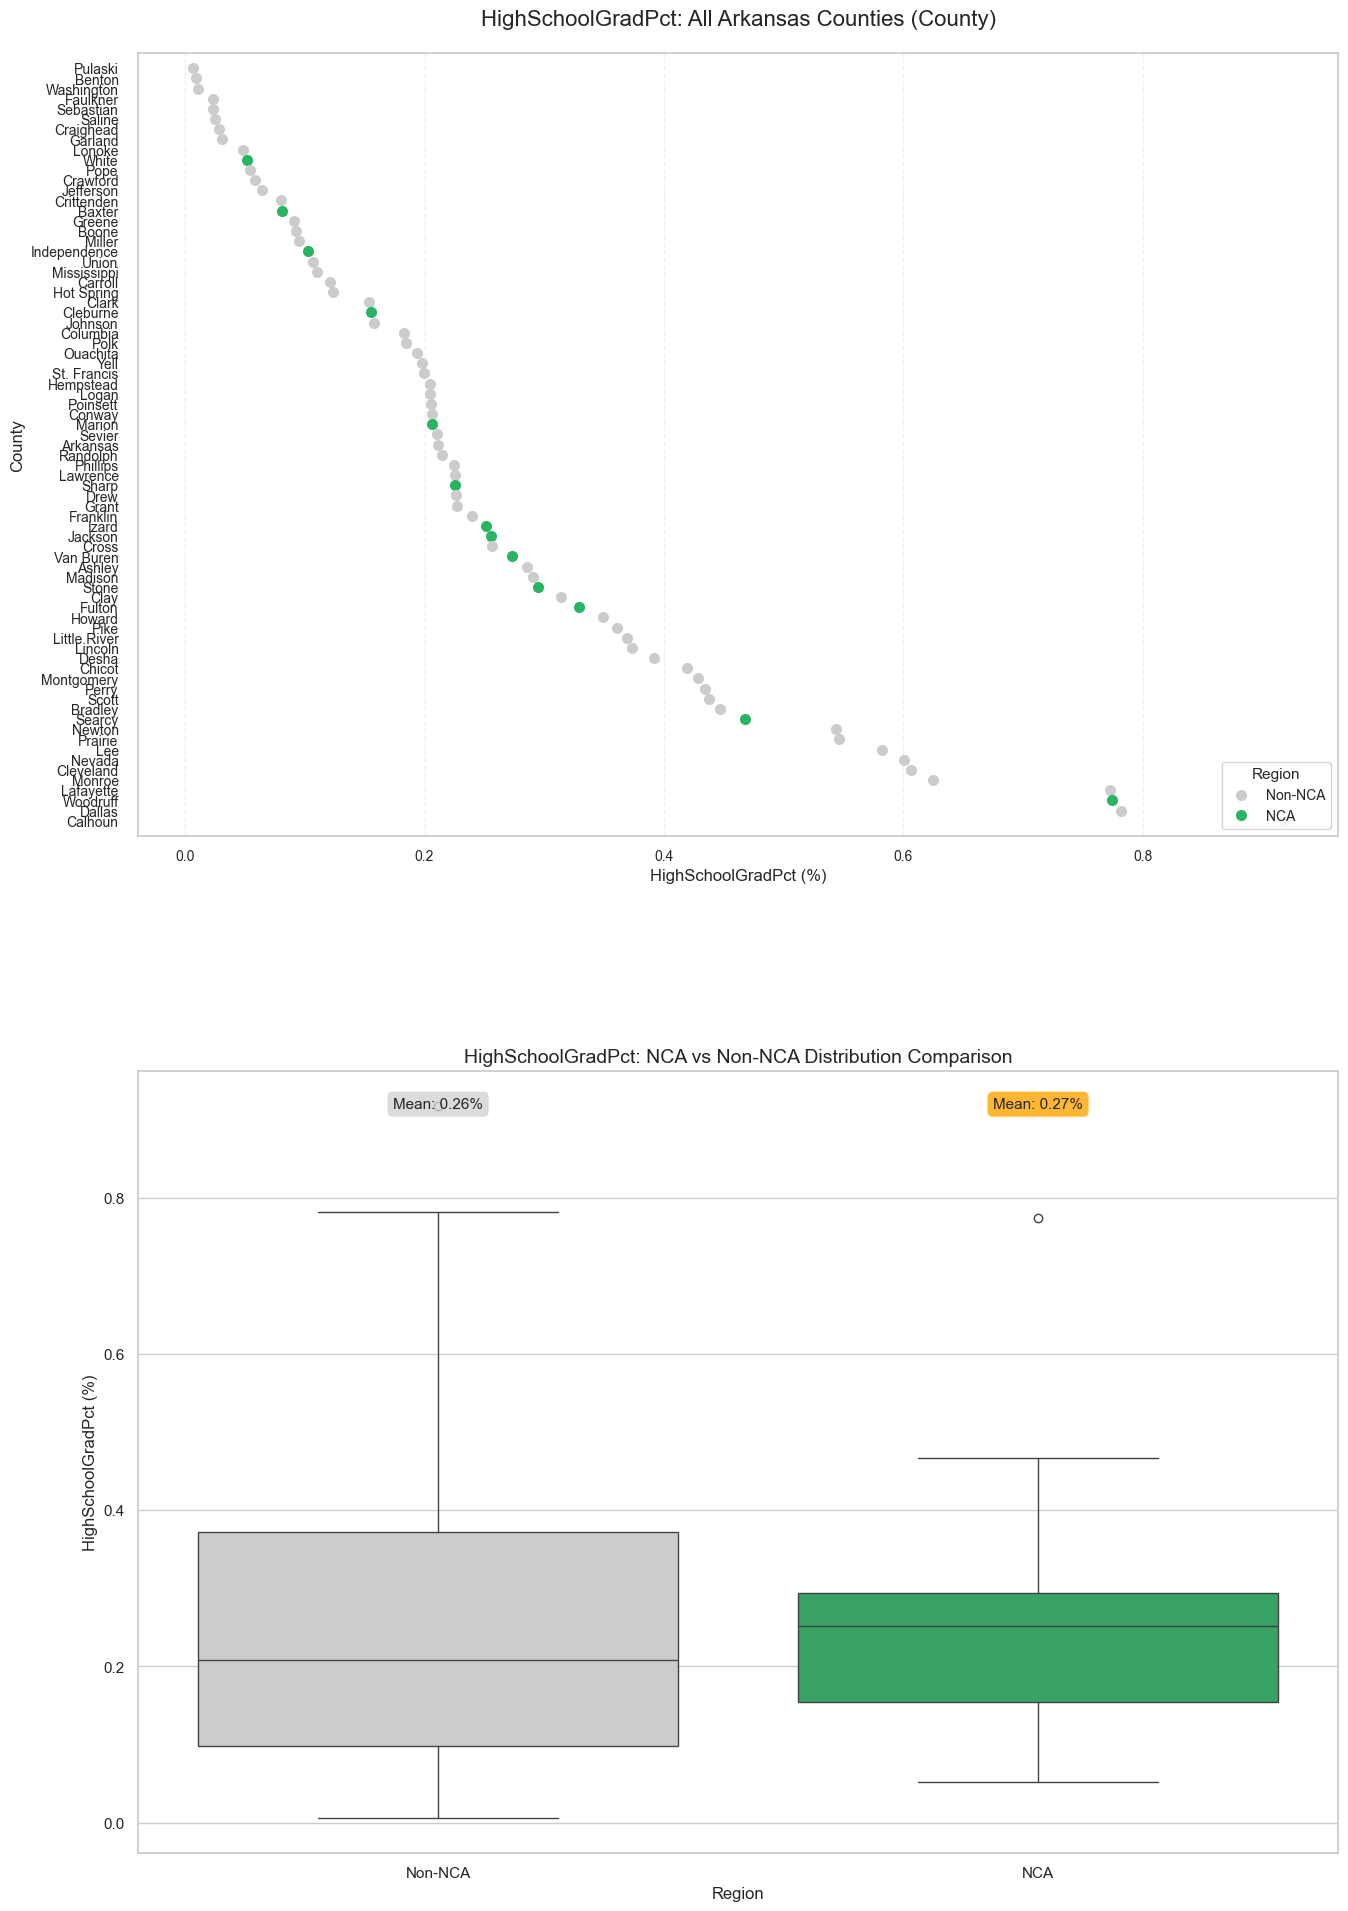

2025-07-30 15:30:49,190 [INFO] Saved NCA comparison: nca_comparison_povertyrate.png


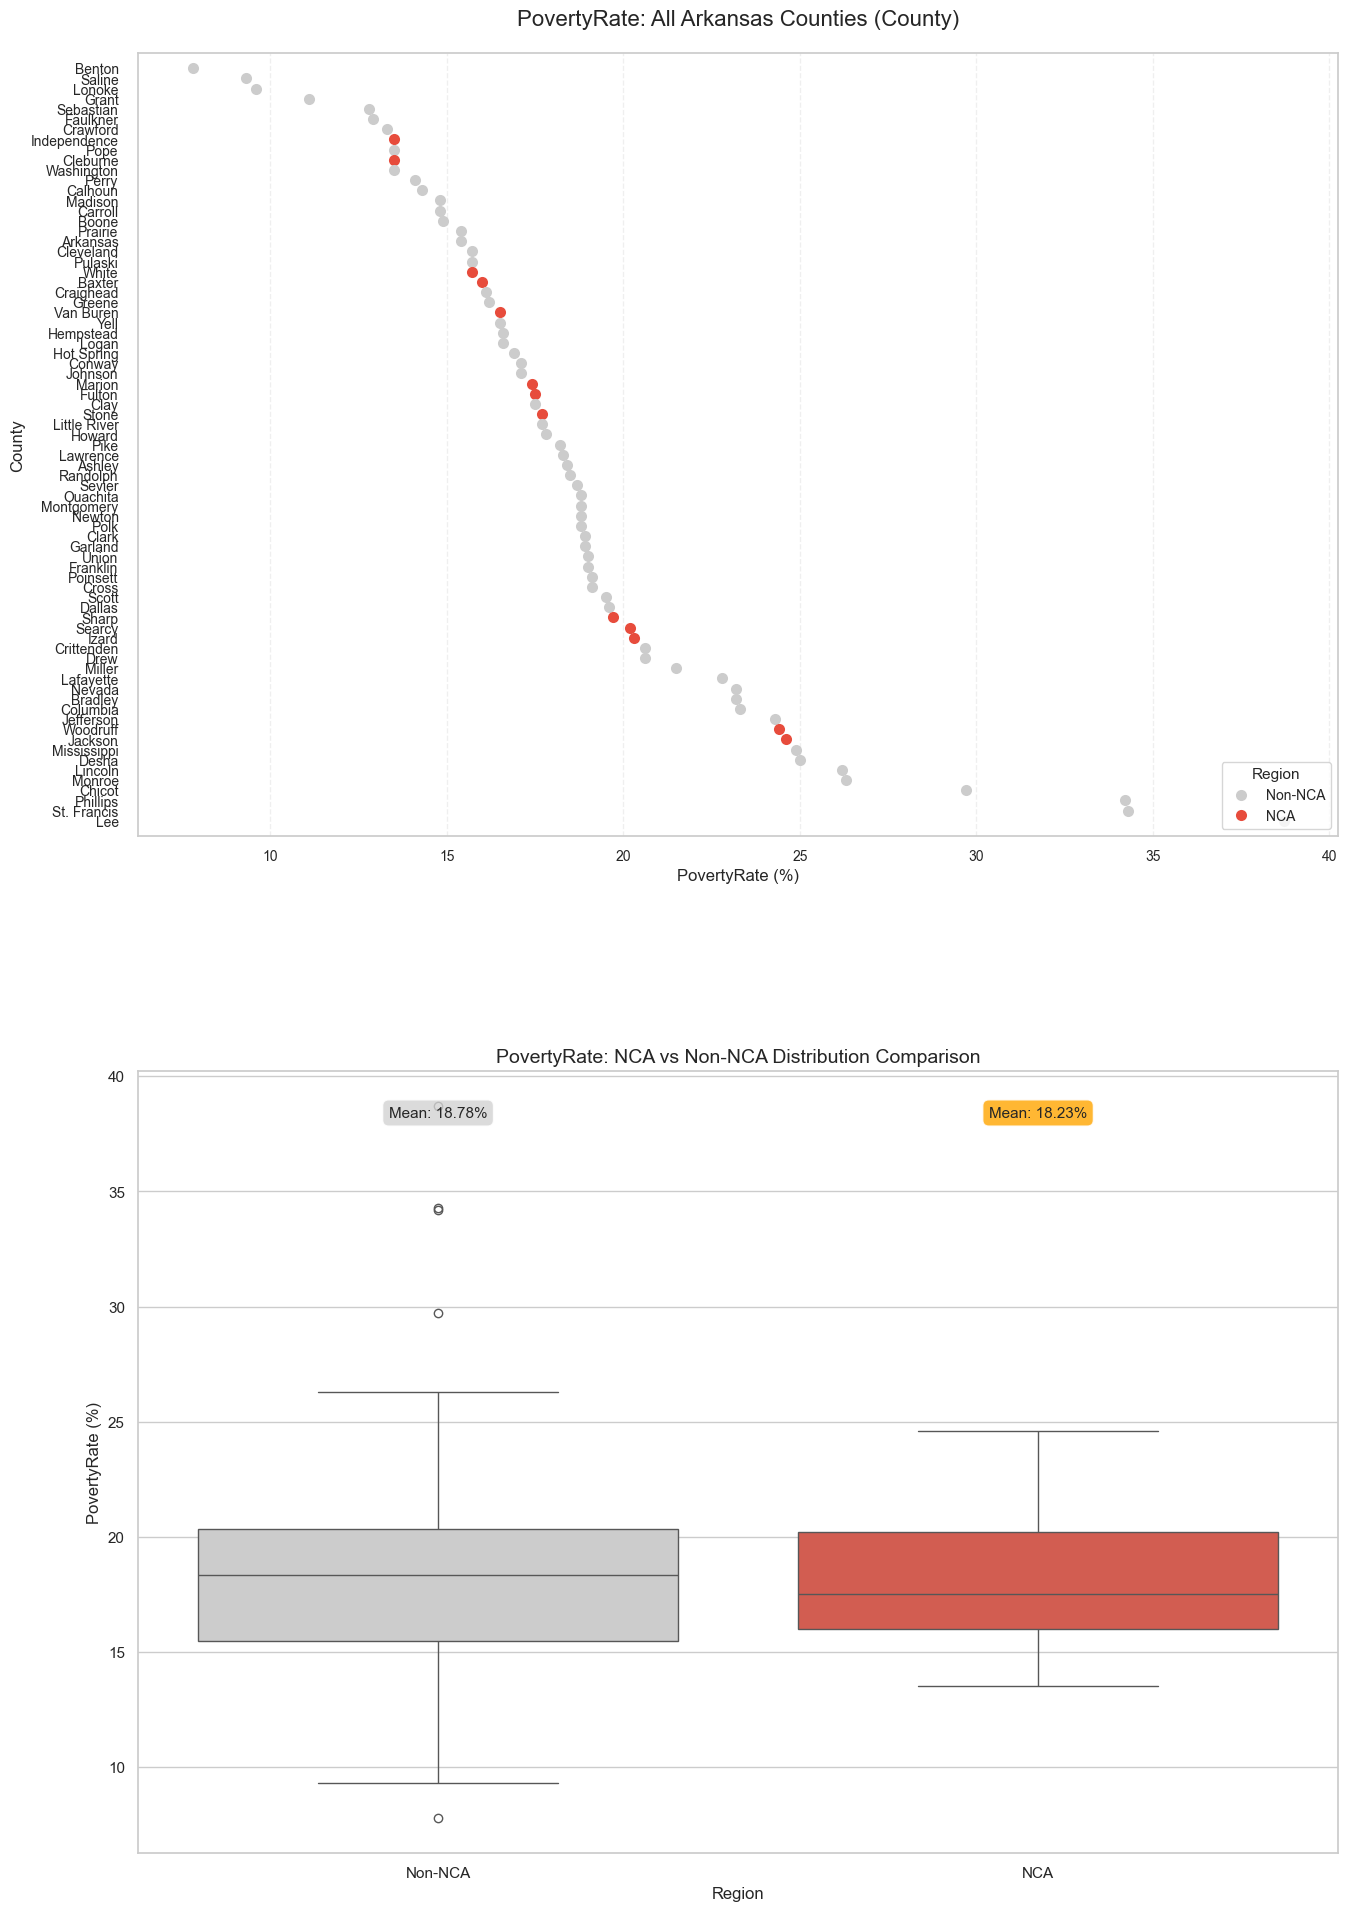

2025-07-30 15:30:50,622 [INFO] Saved NCA comparison: nca_comparison_unemploymentrate.png


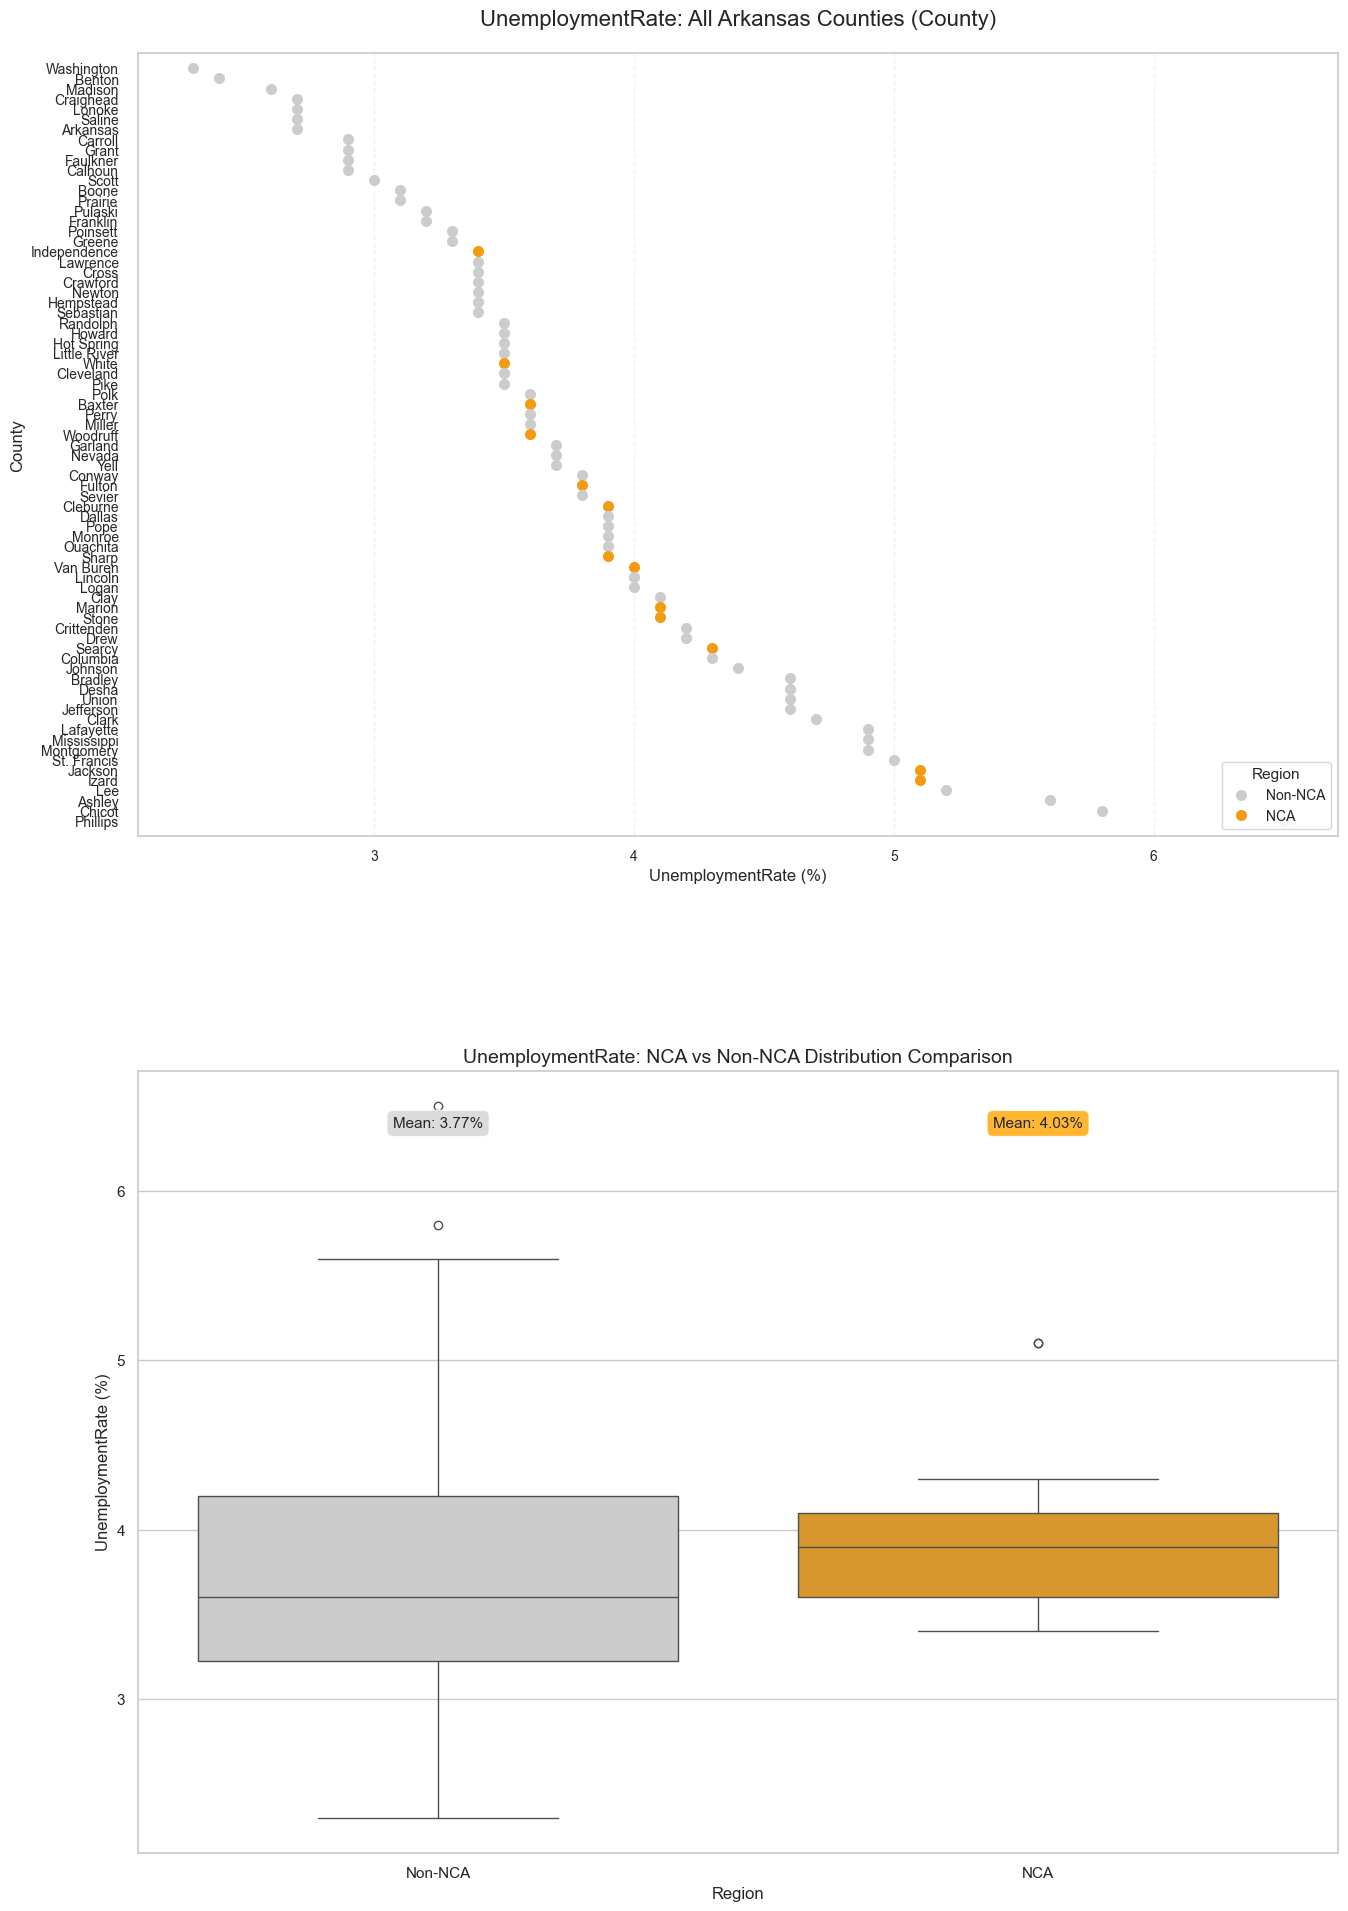

In [18]:
# Section 4.3: NCA vs Non-NCA Comparison Plots
print("\nCreating NCA comparison visualizations...")

for var in percent_vars:
    # Create figure with much larger height for readability
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 20))
    
    # Dot plot highlighting NCA counties - 
    df_plot = df_ar_final.reset_index().sort_values(var)  # Sort alphabetically by county name
    
    # Create strip plot with proper color mapping
    strip_plot = sns.stripplot(
        x=var,
        y='county',
        data=df_plot,
        hue='IsNCA',
        palette={0: '#cccccc', 1: variable_colors.get(var, 'red')},
        size=8,
        jitter=False,
        ax=ax1
    )
    
    ax1.set_title(f"{var}: All Arkansas Counties (County)", fontsize=16, pad=20)
    ax1.set_xlabel(f"{var} (%)", fontsize=12)
    ax1.set_ylabel("County", fontsize=12)
    
    # Fix legend with proper colors
    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles, ["Non-NCA", "NCA"], title="Region", loc='lower right',
              title_fontsize=11, fontsize=10)
    
    # Improve spacing and readability significantly
    ax1.tick_params(axis='y', labelsize=10, pad=8)  # More padding for y-axis
    ax1.tick_params(axis='x', labelsize=10)
    
    # Add even more space between counties
    ax1.margins(y=0.02)  # Add margins to y-axis for better spacing
    
    # Add grid for easier reading
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    ax1.set_axisbelow(True)
    
    # Box plot comparison
    df_plot['Region'] = df_plot['IsNCA'].map({0: 'Non-NCA', 1: 'NCA'})
    sns.boxplot(x='Region', y=var, data=df_plot, 
                palette={'Non-NCA': '#cccccc', 'NCA': variable_colors.get(var, 'red')},
                ax=ax2)
    ax2.set_title(f"{var}: NCA vs Non-NCA Distribution Comparison", fontsize=14)
    ax2.set_ylabel(f"{var} (%)", fontsize=12)
    ax2.set_xlabel("Region", fontsize=12)
    ax2.tick_params(axis='both', labelsize=11)
    
    # Add mean values as text with better positioning
    nca_mean = df_plot[df_plot['IsNCA'] == 1][var].mean()
    non_nca_mean = df_plot[df_plot['IsNCA'] == 0][var].mean()
    
    y_pos = ax2.get_ylim()[1] * 0.95
    ax2.text(0, y_pos, f'Mean: {non_nca_mean:.2f}%', 
             ha='center', fontsize=11, 
             bbox=dict(boxstyle="round,pad=0.4", facecolor="lightgray", alpha=0.8))
    ax2.text(1, y_pos, f'Mean: {nca_mean:.2f}%', 
             ha='center', fontsize=11, 
             bbox=dict(boxstyle="round,pad=0.4", facecolor="orange", alpha=0.8))
    
    # Better layout with more padding
    plt.subplots_adjust(left=0.2, right=0.95, top=0.95, bottom=0.05, hspace=0.3)
    
    filename = f"nca_comparison_{var.lower()}.png"
    plt.savefig(image_dir / filename, dpi=300, bbox_inches='tight')
    logging.info(f"Saved NCA comparison: {filename}")
    plt.show()


## Section 4.4 Correlation Analysis


Creating correlation analysis...
2025-07-30 15:30:51,435 [INFO] Saved correlation heatmap: correlation_heatmap.png


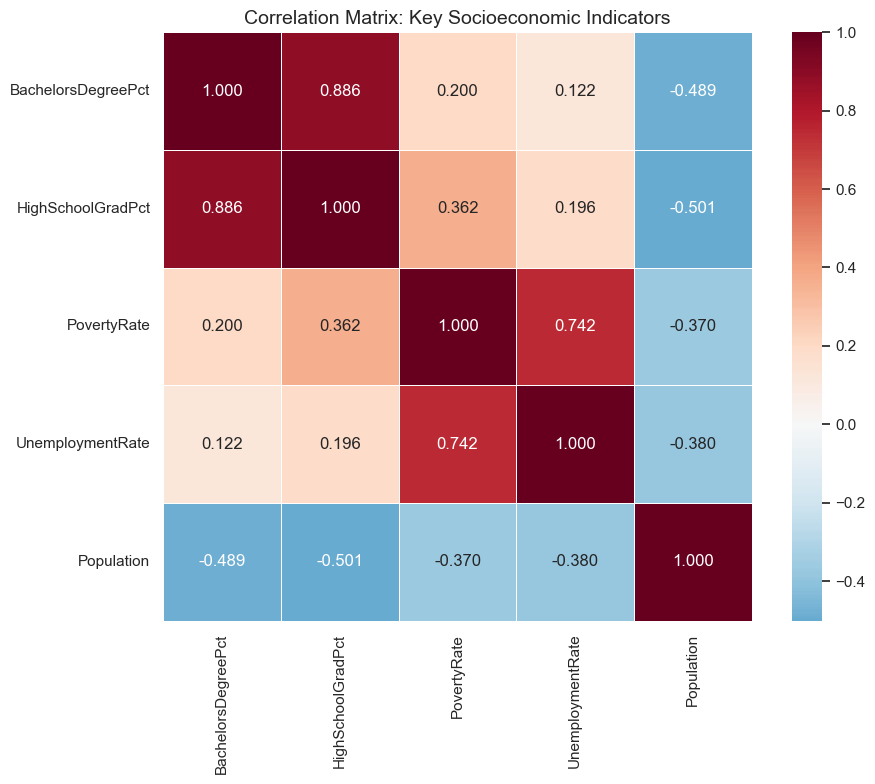

In [19]:
# Section 4.4: Correlation Analysis
print("\nCreating correlation analysis...")

# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_data = df_ar_final[percent_vars + ['Population']].corr()

sns.heatmap(correlation_data, 
            annot=True, 
            cmap="RdBu_r", 
            center=0,
            fmt=".3f", 
            linewidths=0.5,
            square=True)

plt.title("Correlation Matrix: Key Socioeconomic Indicators", fontsize=14)
plt.tight_layout()

filename = "correlation_heatmap.png"
plt.savefig(image_dir / filename, dpi=300, bbox_inches='tight')
logging.info(f"Saved correlation heatmap: {filename}")
plt.show()

## Section 4.5 Outlier Analysis


Creating outlier analysis...
2025-07-30 15:30:51,652 [INFO] Saved outlier analysis: outliers_bachelorsdegreepct.png


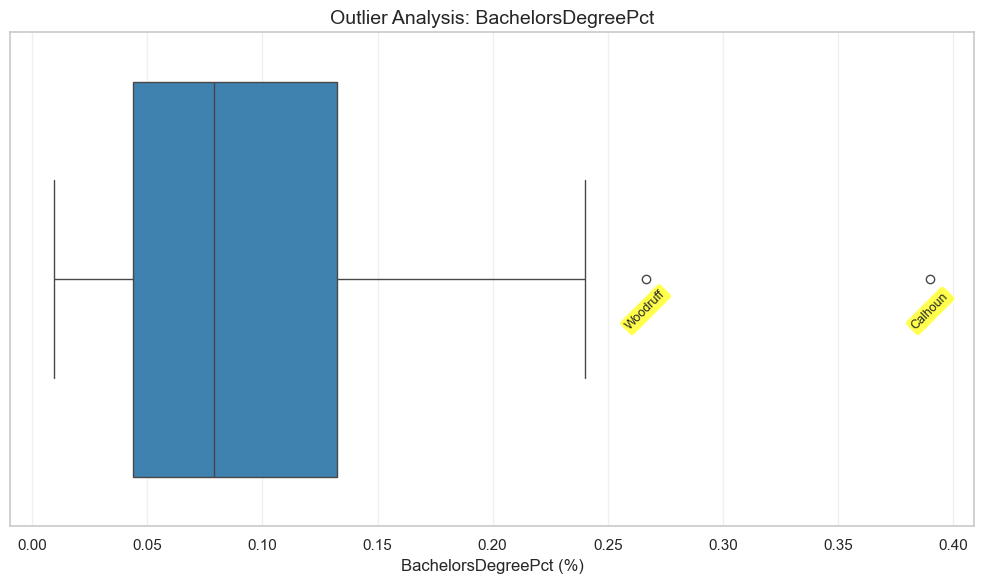


Outliers for BachelorsDegreePct:
  - Calhoun: 0.39%
  - Woodruff: 0.27%
2025-07-30 15:30:51,816 [INFO] Saved outlier analysis: outliers_highschoolgradpct.png


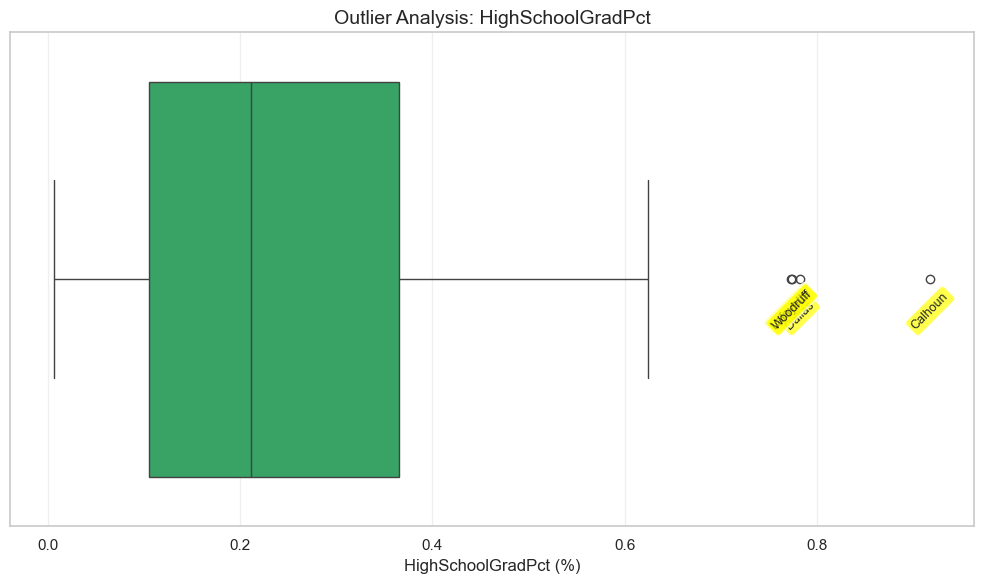


Outliers for HighSchoolGradPct:
  - Calhoun: 0.92%
  - Dallas: 0.78%
  - Lafayette: 0.77%
  - Woodruff: 0.77%
2025-07-30 15:30:51,995 [INFO] Saved outlier analysis: outliers_povertyrate.png


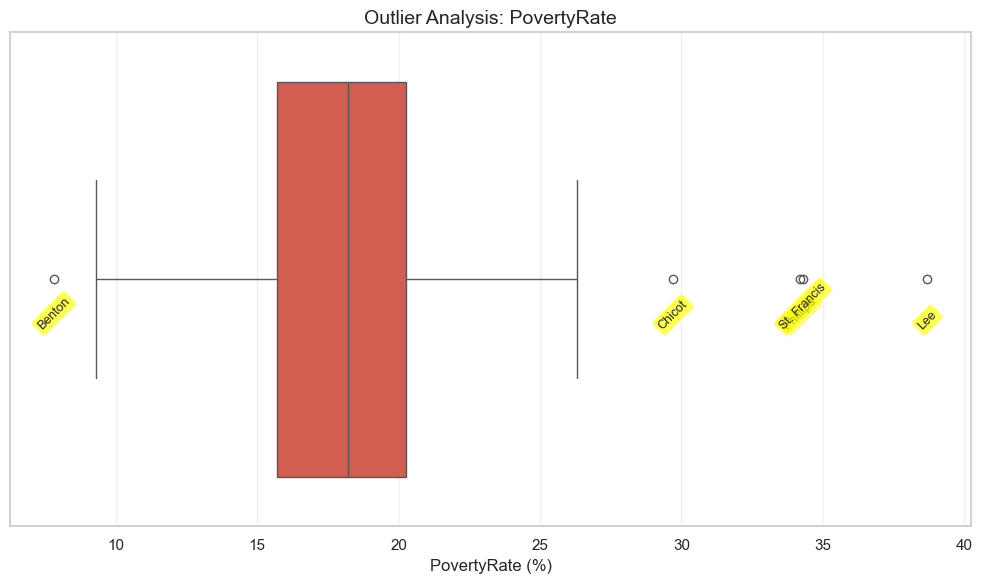


Outliers for PovertyRate:
  - Benton: 7.80%
  - Chicot: 29.70%
  - Lee: 38.70%
  - Phillips: 34.20%
  - St. Francis: 34.30%
2025-07-30 15:30:52,175 [INFO] Saved outlier analysis: outliers_unemploymentrate.png


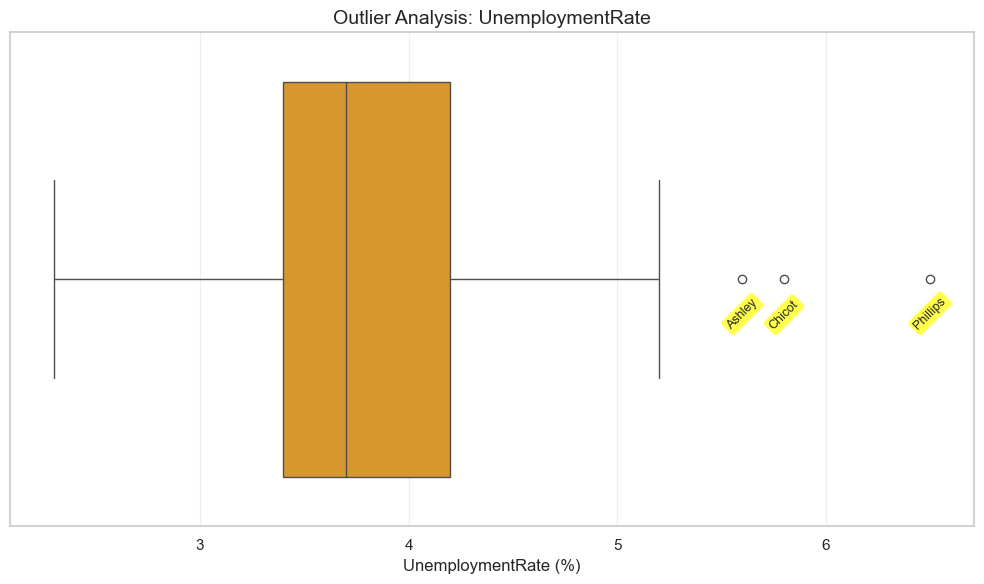


Outliers for UnemploymentRate:
  - Ashley: 5.60%
  - Chicot: 5.80%
  - Phillips: 6.50%


In [20]:
# Section 4.5: Outlier Analysis
print("\nCreating outlier analysis...")

def create_outlier_boxplot(df, var):
    """Create boxplot with outlier labels"""
    # Calculate IQR bounds for outlier detection
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]
    
    plt.figure(figsize=(10, 6))
    
    # Create boxplot
    sns.boxplot(x=var, data=df, color=variable_colors.get(var, 'gray'))
    
    # Annotate outliers with county names
    for county, row in outliers.iterrows():
        plt.annotate(county, 
                    xy=(row[var], 0), 
                    xytext=(row[var], 0.1),
                    ha='center', 
                    fontsize=9,
                    rotation=45,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    plt.title(f"Outlier Analysis: {var}", fontsize=14)
    plt.xlabel(f"{var} (%)")
    plt.yticks([])
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    
    # Save
    filename = f"outliers_{var.lower()}.png"
    plt.savefig(image_dir / filename, dpi=300, bbox_inches='tight')
    logging.info(f"Saved outlier analysis: {filename}")
    plt.show()
    
    # Print outlier summary
    if len(outliers) > 0:
        print(f"\nOutliers for {var}:")
        for county, row in outliers.iterrows():
            print(f"  - {county}: {row[var]:.2f}%")
    else:
        print(f"\nNo outliers detected for {var}")

# Create outlier analysis for each variable
for var in percent_vars:
    create_outlier_boxplot(df_ar_final, var)

## Section 4.6: Summary Statistics Table

In [21]:
# Section 4.6: Summary Statistics Table
print("\nGenerating summary statistics table...")

# Create comprehensive summary table
summary_stats = pd.DataFrame()

# Test NCA vs Non-NCA differences
for var in percent_vars:
    nca_vals = df_ar_final[df_ar_final['IsNCA']==1][var]
    non_nca_vals = df_ar_final[df_ar_final['IsNCA']==0][var]
    t_stat, p_val = stats.ttest_ind(nca_vals, non_nca_vals)
    print(f"{var}: t={t_stat:.3f}, p={p_val:.3f}")

for var in percent_vars:
    stats = df_ar_final[var].describe()
    summary_stats[var] = stats

# Add custom statistics
for var in percent_vars:
    # NCA vs Non-NCA means
    nca_mean = df_ar_final[df_ar_final['IsNCA'] == 1][var].mean()
    non_nca_mean = df_ar_final[df_ar_final['IsNCA'] == 0][var].mean()
    
    summary_stats.loc['NCA_mean', var] = nca_mean
    summary_stats.loc['Non_NCA_mean', var] = non_nca_mean
    summary_stats.loc['NCA_difference', var] = nca_mean - non_nca_mean

# Display and save
summary_stats = summary_stats.round(3)
print("\nSummary Statistics:")
display(summary_stats)

summary_stats.to_csv(figures_dir / "summary_statistics.csv")
logging.info("Saved summary statistics table.")

print("\n Section 4 complete: Statistical visualizations and analysis created.")


Generating summary statistics table...
BachelorsDegreePct: t=0.324, p=0.747
HighSchoolGradPct: t=0.084, p=0.933
PovertyRate: t=-0.331, p=0.741
UnemploymentRate: t=1.073, p=0.287

Summary Statistics:


,BachelorsDegreePct,HighSchoolGradPct,PovertyRate,UnemploymentRate
count,75.000,75.000,75.000,75.000
mean,0.097,0.262,18.683,3.812
std,0.069,0.206,5.377,0.809
min,0.009,0.006,7.800,2.300
25%,0.044,0.105,15.700,3.400
50%,0.079,0.211,18.200,3.700
75%,0.133,0.365,20.250,4.200
max,0.390,0.918,38.700,6.500
NCA_mean,0.103,0.267,18.231,4.031
Non_NCA_mean,0.096,0.261,18.777,3.766


2025-07-30 15:30:52,228 [INFO] Saved summary statistics table.

 Section 4 complete: Statistical visualizations and analysis created.


## Section 5: Feature Engineering – County-Level Indices and Flags
To support meaningful interpretation and modeling, a series of derived features and binary flags were engineered to capture structural disparities across Arkansas counties.

Derived Variable: EducationGap
We calculated an Education Gap by subtracting the percentage of adults with a bachelor’s degree from the percentage with a high school diploma or equivalent. This captures the extent to which postsecondary attainment lags behind basic educational access, offering a simple but insightful lens on educational opportunity gaps. In counties where the gap exceeds 30 percentage points, we flag this as a WideEducationGap condition.

Binary Risk Flags
Five binary indicators were constructed using evidence-based or policy-relevant thresholds:

Flag	Threshold & Rationale
HighPoverty	Poverty rate > 20% (U.S. Census standard for concentrated poverty)
LowBachelorRate	Bachelor's attainment < 15% (proxy for limited postsecondary access)
HighUnemployment	Unemployment > 6% (elevated vs. state average in post-COVID context)
LargePopulation	Population > 20,000 (reframed as proxy for potential resource strain in service delivery or rural-urban interface zones)
WideEducationGap	Gap > 30 percentage points between high school and bachelor’s rates

Clarification: The LargePopulation flag is not a risk in and of itself, but was retained as a signal for counties that may face resource allocation or infrastructure stress if coupled with other vulnerabilities. This variable may also help flag counties at the rural-urban threshold where dynamics shift.

Composite Vulnerability Score
To synthesize multiple indicators, a Vulnerability Score was created by summing the five binary flags. Each flag contributes equally to the score (weight = 1), yielding a range from 0 to 5.

Rationale for Equal Weights: The decision to assign equal weights reflects an initial exploratory intent—emphasizing transparency and interpretability over complex weighting schemes. This approach avoids overfitting or subjective prioritization during early modeling. Future iterations may explore alternative weighting based on empirical correlations or policy-driven priorities (e.g., weighting poverty more heavily in predictive modeling or funding allocation contexts).

Finally, the composite score was normalized to a 0–1 range to support clustering and modeling in subsequent sections.

### Section 5.1: Data Preparation and Initial Features

In [22]:
# Section 5: Enhanced Feature Engineering for Predictive Modeling

# Section 5.1: Data Preparation and Initial Features
# Make a working copy of final dataset
df_fe_ar = df_ar_final.copy()

# Save the working copy
df_fe_ar.to_csv(output_dir / "ar_final_working_copy.csv", index=True)
logging.info("Working copy of final dataset saved.")
print("Working copy of final dataset created.")


2025-07-30 15:30:52,252 [INFO] Working copy of final dataset saved.
Working copy of final dataset created.


### Section 5.2: Derived Ratio and Gap Features

In [23]:
# Section 5.2: Derived Ratio and Gap Features
print("\n Creating derived features...")

# Education Gap = HighSchoolGradPct - BachelorsDegreePct
df_fe_ar['EducationGap'] = df_fe_ar['HighSchoolGradPct'] - df_fe_ar['BachelorsDegreePct']

# Additional meaningful ratios for better modeling
df_fe_ar['EducationRatio'] = df_fe_ar['BachelorsDegreePct'] / (df_fe_ar['HighSchoolGradPct'] + 0.01)  # Avoid division by zero
df_fe_ar['PovertyUnemploymentRatio'] = df_fe_ar['PovertyRate'] / (df_fe_ar['UnemploymentRate'] + 0.01)
df_fe_ar['PopulationDensityProxy'] = np.log1p(df_fe_ar['Population'])  # Log transformation for better distribution

# Economic Pressure Index (combines poverty and unemployment)
df_fe_ar['EconomicPressure'] = (df_fe_ar['PovertyRate'] + df_fe_ar['UnemploymentRate']) / 2

print("Derived features created:")
derived_features = ['EducationGap', 'EducationRatio', 'PovertyUnemploymentRatio', 
                   'PopulationDensityProxy', 'EconomicPressure']
display(df_fe_ar[derived_features].describe().round(3))


 Creating derived features...
Derived features created:


,EducationGap,EducationRatio,PovertyUnemploymentRatio,PopulationDensityProxy,EconomicPressure
count,75.000,75.000,75.000,75.000,75.000
mean,0.165,0.408,4.888,10.022,11.247
std,0.149,0.129,0.898,0.966,3.001
min,-0.003,0.141,3.237,8.443,5.100
25%,0.056,0.340,4.246,9.402,9.425
50%,0.129,0.379,4.893,9.813,10.850
75%,0.220,0.463,5.319,10.556,12.325
max,0.622,0.765,7.428,12.899,21.950


### Section 5.3: Binary Risk Flags
| Threshold Label       | Value  | Description                                         |
|-----------------------|--------|-----------------------------------------------------|
| HighPoverty           | 20.0   | U.S. Census concentrated poverty threshold          |
| LowBachelorRate       | 15.0   | Below national rural average (~18%)                 |
| HighUnemployment      | 6.0    | Above typical full employment threshold             |
| LargePopulation       | 20000  | Rural-urban transition point                        |
| WideEducationGap      | 30.0   | Significant attainment gap                          |
| VeryHighPoverty       | 30.0   | Extreme poverty threshold                           |
| VeryLowEducation      | 10.0   | Severely limited bachelor's attainment              |
| EconomicDistress      | 15.0   | High economic pressure threshold                    |


In [24]:
# Section 5.3: Enhanced Binary Flags with Better Thresholds
print("\n Creating enhanced binary flags...")

# Research-based thresholds with better justification
thresholds = {
    'HighPoverty': 20.0,        # U.S. Census concentrated poverty threshold
    'LowBachelorRate': 15.0,    # Below national rural average (~18%)
    'HighUnemployment': 6.0,    # Above typical full employment threshold
    'LargePopulation': 20000,   # Rural-urban transition point
    'WideEducationGap': 30.0,   # Significant attainment gap
    'VeryHighPoverty': 30.0,    # Extreme poverty threshold
    'VeryLowEducation': 10.0,   # Severely limited bachelor's attainment
    'EconomicDistress': 15.0    # High economic pressure threshold
}

# Create comprehensive flag set
df_fe_ar['HighPoverty'] = (df_fe_ar['PovertyRate'] > thresholds['HighPoverty']).astype(int)
df_fe_ar['LowBachelorRate'] = (df_fe_ar['BachelorsDegreePct'] < thresholds['LowBachelorRate']).astype(int)
df_fe_ar['HighUnemployment'] = (df_fe_ar['UnemploymentRate'] > thresholds['HighUnemployment']).astype(int)
df_fe_ar['LargePopulation'] = (df_fe_ar['Population'] > thresholds['LargePopulation']).astype(int)
df_fe_ar['WideEducationGap'] = (df_fe_ar['EducationGap'] > thresholds['WideEducationGap']).astype(int)

# Additional severity flags for better granularity
df_fe_ar['VeryHighPoverty'] = (df_fe_ar['PovertyRate'] > thresholds['VeryHighPoverty']).astype(int)
df_fe_ar['VeryLowEducation'] = (df_fe_ar['BachelorsDegreePct'] < thresholds['VeryLowEducation']).astype(int)
df_fe_ar['EconomicDistress'] = (df_fe_ar['EconomicPressure'] > thresholds['EconomicDistress']).astype(int)

# Core flags for primary vulnerability score
primary_flags = ['HighPoverty', 'LowBachelorRate', 'HighUnemployment', 'LargePopulation', 'WideEducationGap']
# Extended flags for enhanced analysis
extended_flags = ['VeryHighPoverty', 'VeryLowEducation', 'EconomicDistress']
all_flags = primary_flags + extended_flags

# Flag summary analysis
flag_summary = pd.DataFrame({
    'Count': df_fe_ar[all_flags].sum(),
    'Percentage': (df_fe_ar[all_flags].sum() / len(df_fe_ar) * 100).round(1),
    'Threshold': [thresholds[flag.replace('Wide', '').replace('Low', '').replace('High', '').replace('Large', '')] 
                 if flag.replace('Wide', '').replace('Low', '').replace('High', '').replace('Large', '') in thresholds
                 else thresholds.get(flag, 'N/A') for flag in all_flags]
})

print("Flag Summary:")
display(flag_summary)


 Creating enhanced binary flags...
Flag Summary:


,Count,Percentage,Threshold
HighPoverty,20,26.7,20.0
LowBachelorRate,75,100.0,15.0
HighUnemployment,1,1.3,6.0
LargePopulation,33,44.0,20000.0
WideEducationGap,0,0.0,30.0
VeryHighPoverty,3,4.0,30.0
VeryLowEducation,75,100.0,10.0
EconomicDistress,6,8.0,15.0


### Section 5.4: Create Composite Economic Vulnerability Score

In [25]:
# Section 5.4: Advanced Composite Scoring
print("\n Creating composite vulnerability scores...")

# Primary Vulnerability Score (equal weights)
df_fe_ar['VulnerabilityScore'] = df_fe_ar[primary_flags].sum(axis=1)

# Weighted Vulnerability Score (research-informed weights)
vulnerability_weights = {
    'HighPoverty': 2.0,        # Higher weight - most direct impact
    'LowBachelorRate': 1.5,    # Education is key for economic mobility
    'HighUnemployment': 1.5,   # Direct economic impact
    'LargePopulation': 0.5,    # Lower weight - not inherently negative
    'WideEducationGap': 1.0    # Structural indicator
}

df_fe_ar['WeightedVulnerabilityScore'] = sum(
    df_fe_ar[flag] * weight for flag, weight in vulnerability_weights.items()
)

# Normalize scores to 0-1 range
scaler = MinMaxScaler()
df_fe_ar['VulnerabilityScoreNorm'] = scaler.fit_transform(df_fe_ar[['VulnerabilityScore']])
df_fe_ar['WeightedVulnerabilityScoreNorm'] = scaler.fit_transform(df_fe_ar[['WeightedVulnerabilityScore']])

# Create risk categories for interpretability
df_fe_ar['RiskCategory'] = pd.cut(
    df_fe_ar['WeightedVulnerabilityScoreNorm'],
    bins=[0, 0.25, 0.5, 0.75, 1.0],
    labels=['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk'],
    include_lowest=True
)

print(" Risk Category Distribution:")
print(df_fe_ar['RiskCategory'].value_counts())


 Creating composite vulnerability scores...
 Risk Category Distribution:
RiskCategory
Low Risk          55
High Risk         19
Very High Risk     1
Moderate Risk      0
Name: count, dtype: int64


### Section 5.5: Feature Scaling and Preparation for ML

In [26]:
# Section 5.5: Feature Scaling and Preparation for ML

print("\n Preparing features for machine learning...")

# Select features for modeling
base_features = ['BachelorsDegreePct', 'HighSchoolGradPct', 'PovertyRate', 'UnemploymentRate', 'Population']
derived_features = ['EducationGap', 'EducationRatio', 'PovertyUnemploymentRatio', 'PopulationDensityProxy', 'EconomicPressure']
flag_features = all_flags

# All features for modeling
modeling_features = base_features + derived_features + flag_features

# Create scaled versions using different scalers for robustness
scalers = {
    'MinMax': MinMaxScaler(),
    'Standard': StandardScaler() if 'StandardScaler' in dir() else MinMaxScaler(),
    'Robust': None  # We'll implement a simple version
}

# Apply MinMax scaling (most important for our use case)
minmax_scaler = MinMaxScaler()
scaled_features = minmax_scaler.fit_transform(df_fe_ar[base_features + derived_features])
scaled_df = pd.DataFrame(
    scaled_features, 
    columns=[f"{col}_Scaled" for col in base_features + derived_features],
    index=df_fe_ar.index
)

# Combine scaled features with original data
df_fe_ar = pd.concat([df_fe_ar, scaled_df], axis=1)


 Preparing features for machine learning...


### Section 5.6: Feature Quality Assessment

In [27]:
# Section 5.6: Feature Quality Assessment
print("\n🔍 Assessing feature quality...")

# Calculate feature correlations
correlation_matrix = df_fe_ar[base_features + derived_features].corr()

# Identify highly correlated features (potential multicollinearity)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                correlation_matrix.columns[i], 
                correlation_matrix.columns[j], 
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print("High correlation pairs (>0.8):")
    for pair in high_corr_pairs:
        print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("No highly correlated feature pairs detected")

# Feature variance analysis
feature_variance = df_fe_ar[base_features + derived_features].var().sort_values(ascending=False)
print("\n Feature variance (top 5):")
display(feature_variance.head().round(4))



🔍 Assessing feature quality...
High correlation pairs (>0.8):
  BachelorsDegreePct - HighSchoolGradPct: 0.886
  BachelorsDegreePct - PopulationDensityProxy: -0.804
  HighSchoolGradPct - EducationGap: 0.977
  HighSchoolGradPct - PopulationDensityProxy: -0.847
  PovertyRate - EconomicPressure: 0.996
  Population - PopulationDensityProxy: 0.836
  EducationGap - PopulationDensityProxy: -0.802

 Feature variance (top 5):


Population                  4.396444e+09
PovertyRate                 2.891280e+01
EconomicPressure            9.007000e+00
PopulationDensityProxy      9.331000e-01
PovertyUnemploymentRatio    8.067000e-01
dtype: float64

### Section 5.7: NCA-Specific Analysis

In [28]:
# Section 5.7: NCA-Specific Analysis
print("\n NCA-specific feature analysis...")

# Compare NCA vs Non-NCA on key metrics
comparison_features = base_features + derived_features + ['VulnerabilityScore', 'WeightedVulnerabilityScore']
nca_comparison = pd.DataFrame({
    'NCA_Mean': df_fe_ar[df_fe_ar['IsNCA'] == 1][comparison_features].mean(),
    'Non_NCA_Mean': df_fe_ar[df_fe_ar['IsNCA'] == 0][comparison_features].mean()
})
nca_comparison['Difference'] = nca_comparison['NCA_Mean'] - nca_comparison['Non_NCA_Mean']
nca_comparison['Abs_Difference'] = abs(nca_comparison['Difference'])

print(" NCA vs Non-NCA Comparison (largest differences):")
display(nca_comparison.sort_values('Abs_Difference', ascending=False).round(3))



 NCA-specific feature analysis...
 NCA vs Non-NCA Comparison (largest differences):


,NCA_Mean,Non_NCA_Mean,Difference,Abs_Difference
Population,23579.308,44535.500,-20956.192,20956.192
PovertyRate,18.231,18.777,-0.547,0.547
PovertyUnemploymentRatio,4.526,4.964,-0.438,0.438
UnemploymentRate,4.031,3.766,0.265,0.265
PopulationDensityProxy,9.824,10.063,-0.239,0.239
EconomicPressure,11.131,11.272,-0.141,0.141
VulnerabilityScore,1.615,1.742,-0.127,0.127
EducationRatio,0.387,0.412,-0.025,0.025
BachelorsDegreePct,0.103,0.096,0.007,0.007
HighSchoolGradPct,0.267,0.261,0.005,0.005


### Section 5.8: Save Enhanced Dataset

In [29]:
# Section 5.8: Save Enhanced Dataset
print("\n Saving enhanced dataset...")

# Create feature documentation
feature_documentation = {
    'Base Features': base_features,
    'Derived Features': derived_features,
    'Flag Features': all_flags,
    'Scaled Features': [f"{col}_Scaled" for col in base_features + derived_features],
    'Composite Scores': ['VulnerabilityScore', 'WeightedVulnerabilityScore', 
                        'VulnerabilityScoreNorm', 'WeightedVulnerabilityScoreNorm'],
    'Categories': ['RiskCategory']
}

# Save main dataset
df_fe_ar.to_csv(output_dir / "ar_enhanced_features.csv", index=True)

# Save feature subsets for different modeling approaches
df_fe_ar[base_features + ['IsNCA']].to_csv(output_dir / "ar_base_features.csv", index=True)
df_fe_ar[derived_features + ['IsNCA']].to_csv(output_dir / "ar_derived_features.csv", index=True)
df_fe_ar[all_flags + ['IsNCA']].to_csv(output_dir / "ar_flag_features.csv", index=True)

# Save documentation
with open(output_dir / "feature_documentation.txt", "w") as f:
    for category, features in feature_documentation.items():
        f.write(f"{category}:\n")
        for feature in features:
            f.write(f"  - {feature}\n")
        f.write("\n")

# Final summary
print("\n Enhanced feature engineering complete!")
print("Dataset shape: {df_fe_ar.shape}")
print("Total features created: {len(derived_features + all_flags + [f'{col}_Scaled' for col in base_features + derived_features])}")
print("Files saved:")
print("  - ar_enhanced_features.csv (complete dataset)")
print("  - ar_base_features.csv (base features only)")
print("  - ar_derived_features.csv (derived features only)")
print("  - ar_flag_features.csv (binary flags only)")
print("  - feature_documentation.txt (feature descriptions)")

logging.info("Section 5 enhanced feature engineering completed successfully.")


 Saving enhanced dataset...

 Enhanced feature engineering complete!
Dataset shape: {df_fe_ar.shape}
Total features created: {len(derived_features + all_flags + [f'{col}_Scaled' for col in base_features + derived_features])}
Files saved:
  - ar_enhanced_features.csv (complete dataset)
  - ar_base_features.csv (base features only)
  - ar_derived_features.csv (derived features only)
  - ar_flag_features.csv (binary flags only)
  - feature_documentation.txt (feature descriptions)
2025-07-30 15:30:52,356 [INFO] Section 5 enhanced feature engineering completed successfully.


# Section 6 Modeling

## 6.1 Linear Regression Analysis

                            OLS Regression Results                            
Dep. Variable:            PovertyRate   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     46.34
Date:                Wed, 30 Jul 2025   Prob (F-statistic):           1.16e-13
Time:                        15:30:52   Log-Likelihood:                -201.05
No. Observations:                  75   AIC:                             408.1
Df Residuals:                      72   BIC:                             415.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.6079      2

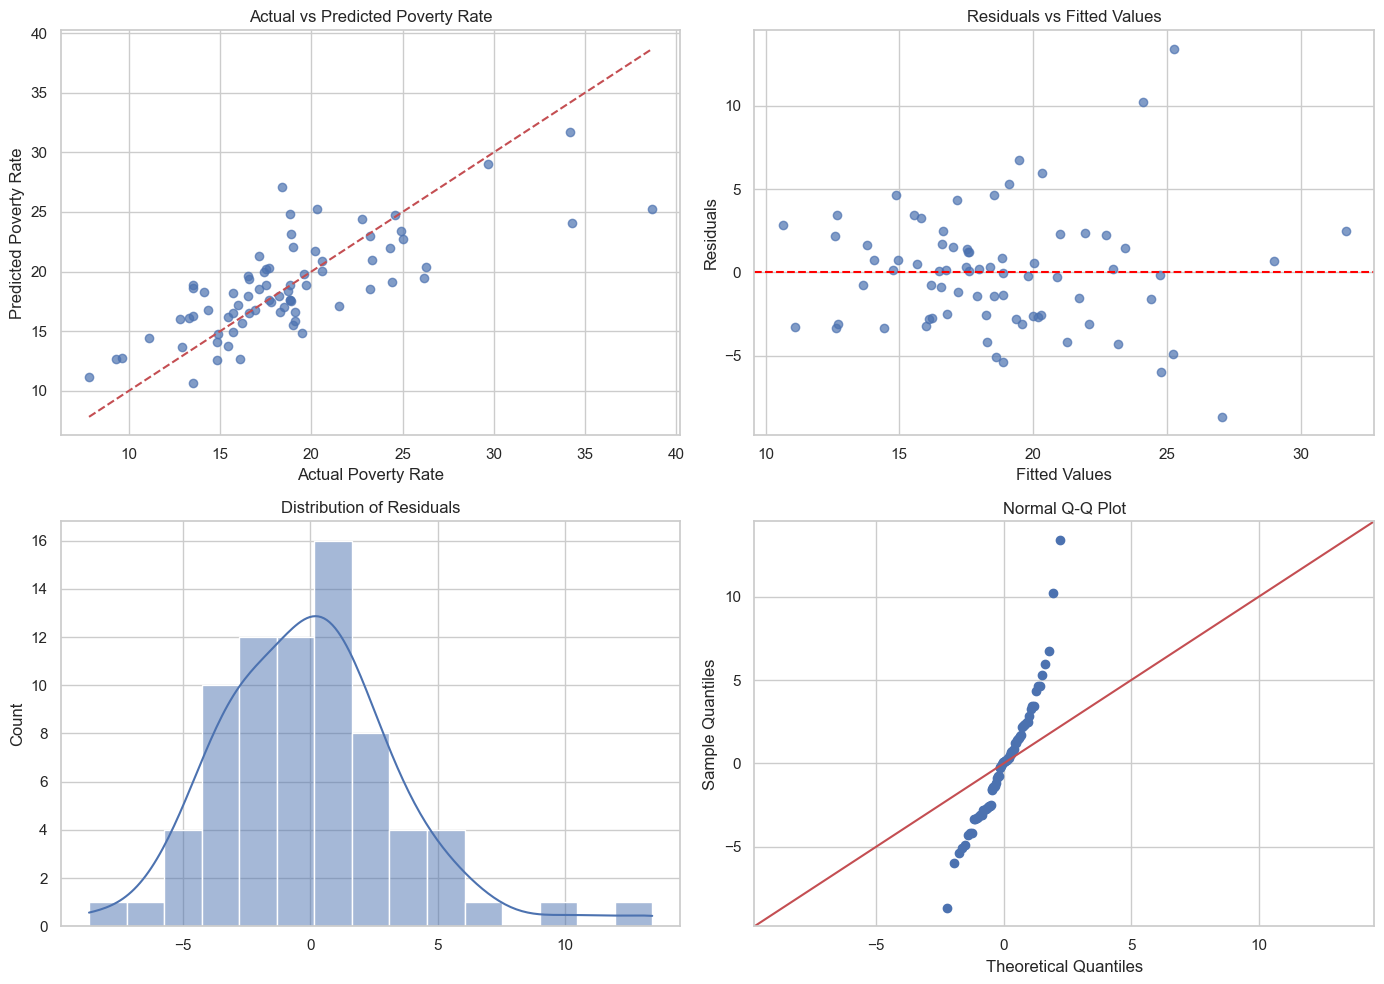

In [30]:
# 6.1 Linear Regression Analysis
# Define predictors and outcome
X = df_fe_ar[['BachelorsDegreePct', 'UnemploymentRate']]
y = df_fe_ar['PovertyRate']

# Add constant for intercept
X_const = sm.add_constant(X)

# Fit OLS regression model
model = sm.OLS(y, X_const).fit()

# Display model summary
print(model.summary())

# Generate diagnostics
y_pred = model.predict(X_const)
residuals = y - y_pred

# Plot diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y, y_pred, alpha=0.7)
axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0, 0].set_title('Actual vs Predicted Poverty Rate')
axes[0, 0].set_xlabel('Actual Poverty Rate')
axes[0, 0].set_ylabel('Predicted Poverty Rate')

# Plot 2: Residuals vs Fitted
axes[0, 1].scatter(y_pred, residuals, alpha=0.7)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residuals vs Fitted Values')
axes[0, 1].set_xlabel('Fitted Values')
axes[0, 1].set_ylabel('Residuals')

# Plot 3: Histogram of residuals
sns.histplot(residuals, kde=True, bins=15, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Residuals')

# Plot 4: Q-Q plot
sm.qqplot(residuals, line='45', ax=axes[1, 1])
axes[1, 1].set_title('Normal Q-Q Plot')

plt.tight_layout()
plt.savefig("ar_outputs/images/linear_regression_diagnostics.png", dpi=300)
plt.show()

### Section 6.1.1: Linear Regression – Predicting Composite Vulnerability Score

                            OLS Regression Results                            
Dep. Variable:     VulnerabilityScore   R-squared:                       0.315
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     10.87
Date:                Wed, 30 Jul 2025   Prob (F-statistic):           5.87e-06
Time:                        15:30:53   Log-Likelihood:                -56.774
No. Observations:                  75   AIC:                             121.5
Df Residuals:                      71   BIC:                             130.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.9446      0

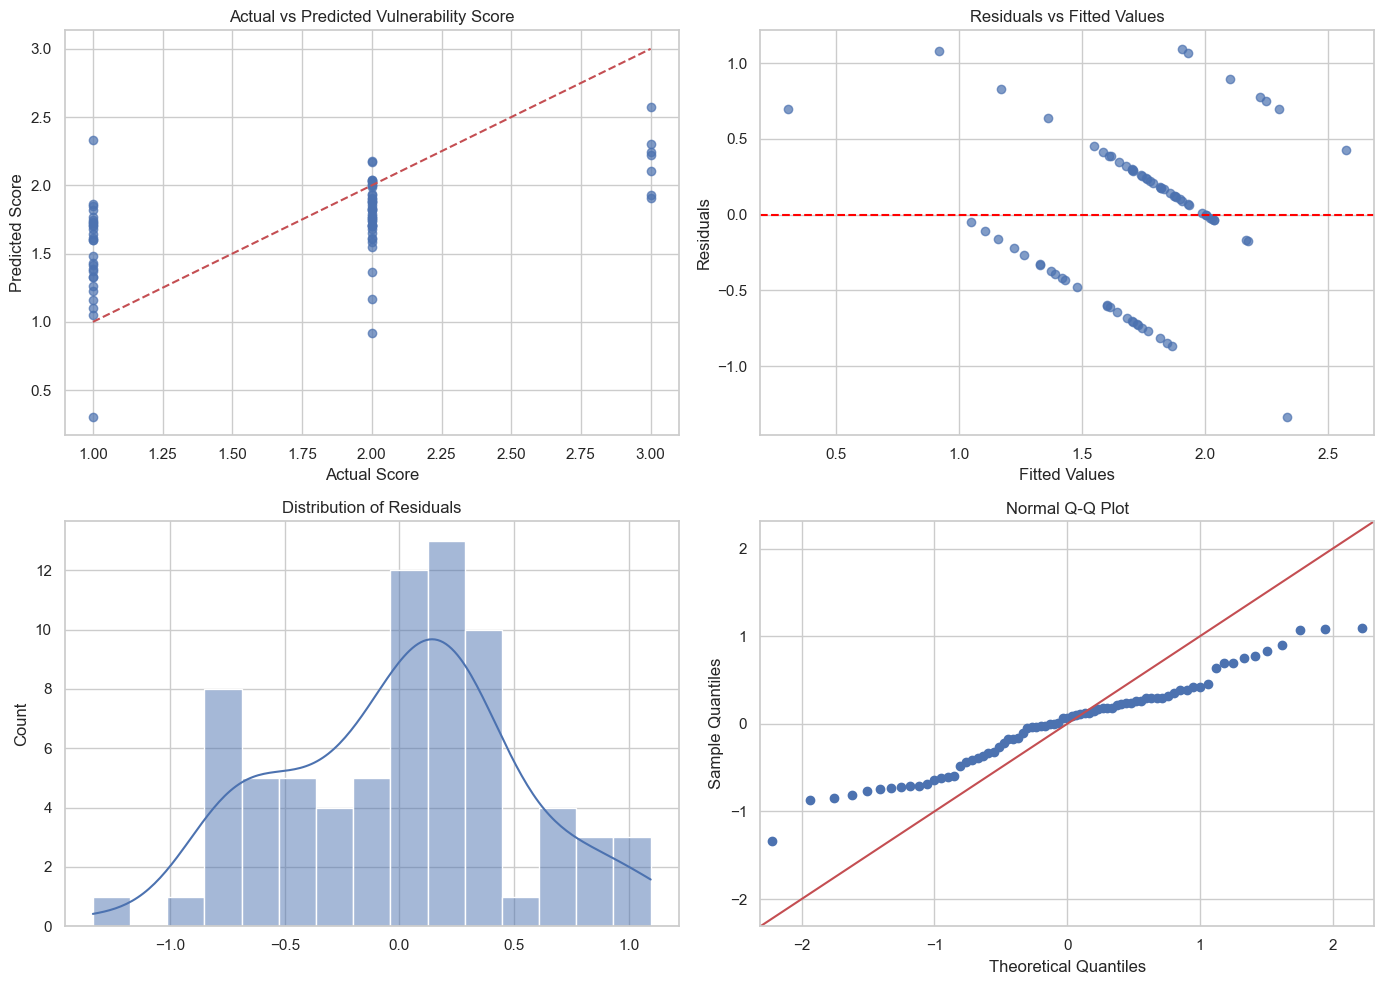

In [31]:
# Section 6.1.1: Linear Regression – Predicting Composite Vulnerability Score

# Define predictors and target
X_vuln = df_fe_ar[['BachelorsDegreePct', 'UnemploymentRate', 'EducationGap']]
y_vuln = df_fe_ar['VulnerabilityScore']

# Add intercept
X_vuln_const = sm.add_constant(X_vuln)

# Fit the regression model
vuln_model = sm.OLS(y_vuln, X_vuln_const).fit()

# Show model summary
print(vuln_model.summary())

# Diagnostics
y_pred_vuln = vuln_model.predict(X_vuln_const)
residuals_vuln = y_vuln - y_pred_vuln

# Plot diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_vuln, y_pred_vuln, alpha=0.7)
axes[0, 0].plot([y_vuln.min(), y_vuln.max()], [y_vuln.min(), y_vuln.max()], 'r--')
axes[0, 0].set_title('Actual vs Predicted Vulnerability Score')
axes[0, 0].set_xlabel('Actual Score')
axes[0, 0].set_ylabel('Predicted Score')

# Plot 2: Residuals vs Fitted
axes[0, 1].scatter(y_pred_vuln, residuals_vuln, alpha=0.7)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residuals vs Fitted Values')
axes[0, 1].set_xlabel('Fitted Values')
axes[0, 1].set_ylabel('Residuals')

# Plot 3: Histogram of residuals
sns.histplot(residuals_vuln, kde=True, bins=15, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Residuals')

# Plot 4: Q-Q plot
sm.qqplot(residuals_vuln, line='45', ax=axes[1, 1])
axes[1, 1].set_title('Normal Q-Q Plot')

plt.tight_layout()
plt.savefig("ar_outputs/images/vulnerability_score_regression_diagnostics.png", dpi=300)
plt.show()


## Section 6.2: Optimal Clustering Analysis

Section 6.2: Determining Optimal Number of Clusters


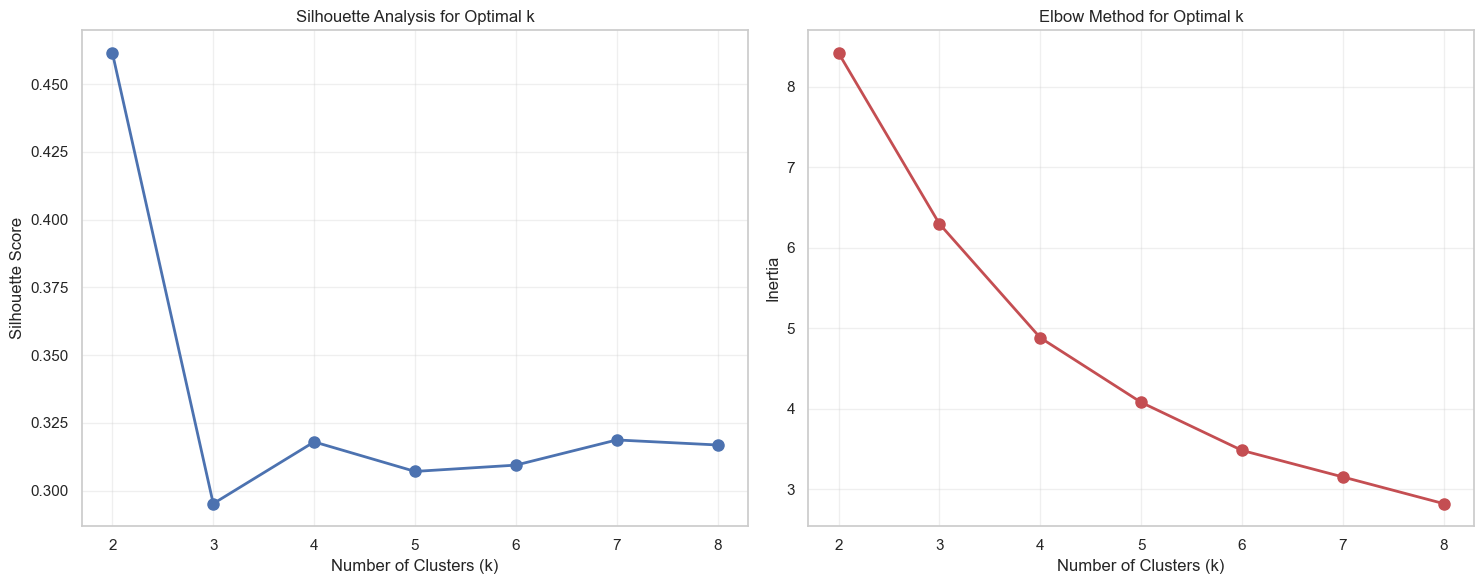

Optimal number of clusters based on silhouette score: 2
Best silhouette score: 0.461


In [32]:
# Section 6.2: Optimal Clustering Analysis
print("Section 6.2: Determining Optimal Number of Clusters")

# Select features for clustering
cluster_features = [
    'BachelorsDegreePct_Scaled',
    'HighSchoolGradPct_Scaled', 
    'PovertyRate_Scaled',
    'UnemploymentRate_Scaled',
    'EducationGap_Scaled'
]

X_cluster = df_fe_ar[cluster_features]

# Determine optimal number of clusters using multiple methods
def evaluate_clustering(X, max_k=8):
    """Evaluate clustering performance for different k values"""
    k_range = range(2, max_k + 1)
    silhouette_scores = []
    inertias = []
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)
        
        # Calculate silhouette score
        sil_score = silhouette_score(X, cluster_labels)
        silhouette_scores.append(sil_score)
        
        # Calculate inertia for elbow method
        inertias.append(kmeans.inertia_)
    
    return k_range, silhouette_scores, inertias

k_range, silhouette_scores, inertias = evaluate_clustering(X_cluster)

# Plot evaluation metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Silhouette scores
ax1.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Silhouette Analysis for Optimal k')
ax1.grid(True, alpha=0.3)

# Elbow method
ax2.plot(k_range, inertias, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Inertia')
ax2.set_title('Elbow Method for Optimal k')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(image_dir / "clustering_evaluation.png", dpi=300, bbox_inches='tight')
plt.show()

# Select optimal k based on silhouette score
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")
print(f"Best silhouette score: {max(silhouette_scores):.3f}")

### Section 6.3: Final Clustering with Optimal Parameters 

In [33]:
# Section 6.3: Final Clustering with Optimal Parameters
print(f"\nSection 6.3: Performing Final Clustering with k={optimal_k}")

# Perform final clustering
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_fe_ar['ClusterLabel'] = final_kmeans.fit_predict(X_cluster)

# Calculate final silhouette score
final_sil_score = silhouette_score(X_cluster, df_fe_ar['ClusterLabel'])
print(f"Final Silhouette Score: {final_sil_score:.3f}")

# Analyze cluster characteristics
cluster_analysis = df_fe_ar.groupby('ClusterLabel').agg({
    'BachelorsDegreePct': ['mean', 'std', 'count'],
    'HighSchoolGradPct': ['mean', 'std'],
    'PovertyRate': ['mean', 'std'],
    'UnemploymentRate': ['mean', 'std'],
    'EducationGap': ['mean', 'std'],
    'Population': ['mean', 'std'],
    'VulnerabilityScore': ['mean', 'std'],
    'IsNCA': 'sum'
}).round(2)

print("\nCluster Analysis Summary:")
display(cluster_analysis)

# Create interpretable cluster names based on characteristics
def assign_cluster_names(df, cluster_col='ClusterLabel'):
    """Assign meaningful names to clusters based on their characteristics"""
    cluster_summary = df.groupby(cluster_col)[['PovertyRate', 'BachelorsDegreePct', 'UnemploymentRate']].mean()
    
    cluster_names = {}
    for cluster_id in cluster_summary.index:
        poverty = cluster_summary.loc[cluster_id, 'PovertyRate']
        education = cluster_summary.loc[cluster_id, 'BachelorsDegreePct']
        unemployment = cluster_summary.loc[cluster_id, 'UnemploymentRate']
        
        # Define cluster names based on dominant characteristics
        if poverty > 20 and education < 15:
            name = "High Risk - Low Education/High Poverty"
        elif poverty < 15 and education > 20:
            name = "Low Risk - High Education/Low Poverty"
        elif education < 15 and unemployment > 6:
            name = "Economic Distress - Low Education/High Unemployment"
        else:
            name = "Moderate Risk - Mixed Characteristics"
        
        cluster_names[cluster_id] = name
    
    return cluster_names

cluster_names = assign_cluster_names(df_fe_ar)
df_fe_ar['ClusterName'] = df_fe_ar['ClusterLabel'].map(cluster_names)

print("\nCluster Names and County Assignments:")
for cluster_id, name in cluster_names.items():
    counties = df_fe_ar[df_fe_ar['ClusterLabel'] == cluster_id].index.tolist()
    nca_count = df_fe_ar[df_fe_ar['ClusterLabel'] == cluster_id]['IsNCA'].sum()
    print("\nCluster {cluster_id}: {name}")
    print("Counties ({len(counties)} total, {nca_count} NCA): {', '.join([c.title() for c in counties])}")



Section 6.3: Performing Final Clustering with k=2
Final Silhouette Score: 0.461

Cluster Analysis Summary:


BachelorsDegreePct             HighSchoolGradPct        \
                           mean   std count              mean   std   
ClusterLabel                                                          
0                          0.07  0.04    57              0.17  0.10   
1                          0.18  0.07    18              0.56  0.16   

             PovertyRate       UnemploymentRate       EducationGap        \
                    mean   std             mean   std         mean   std   
ClusterLabel                                                               
0                  17.64  4.72             3.74  0.80         0.10  0.07   
1                  21.99  6.10             4.05  0.81         0.38  0.12   

             Population           VulnerabilityScore       IsNCA  
                   mean       std               mean   std   sum  
ClusterLabel                                                      
0              51228.93  73185.58               1.77  0.66    11  
1               8204.61   2038.80               1.56  0.51     2


Cluster Names and County Assignments:

Cluster {cluster_id}: {name}
Counties ({len(counties)} total, {nca_count} NCA): {', '.join([c.title() for c in counties])}

Cluster {cluster_id}: {name}
Counties ({len(counties)} total, {nca_count} NCA): {', '.join([c.title() for c in counties])}


## Section 6.4 – Cluster Visualizations


Section 6.3: Creating Cluster Visualizations


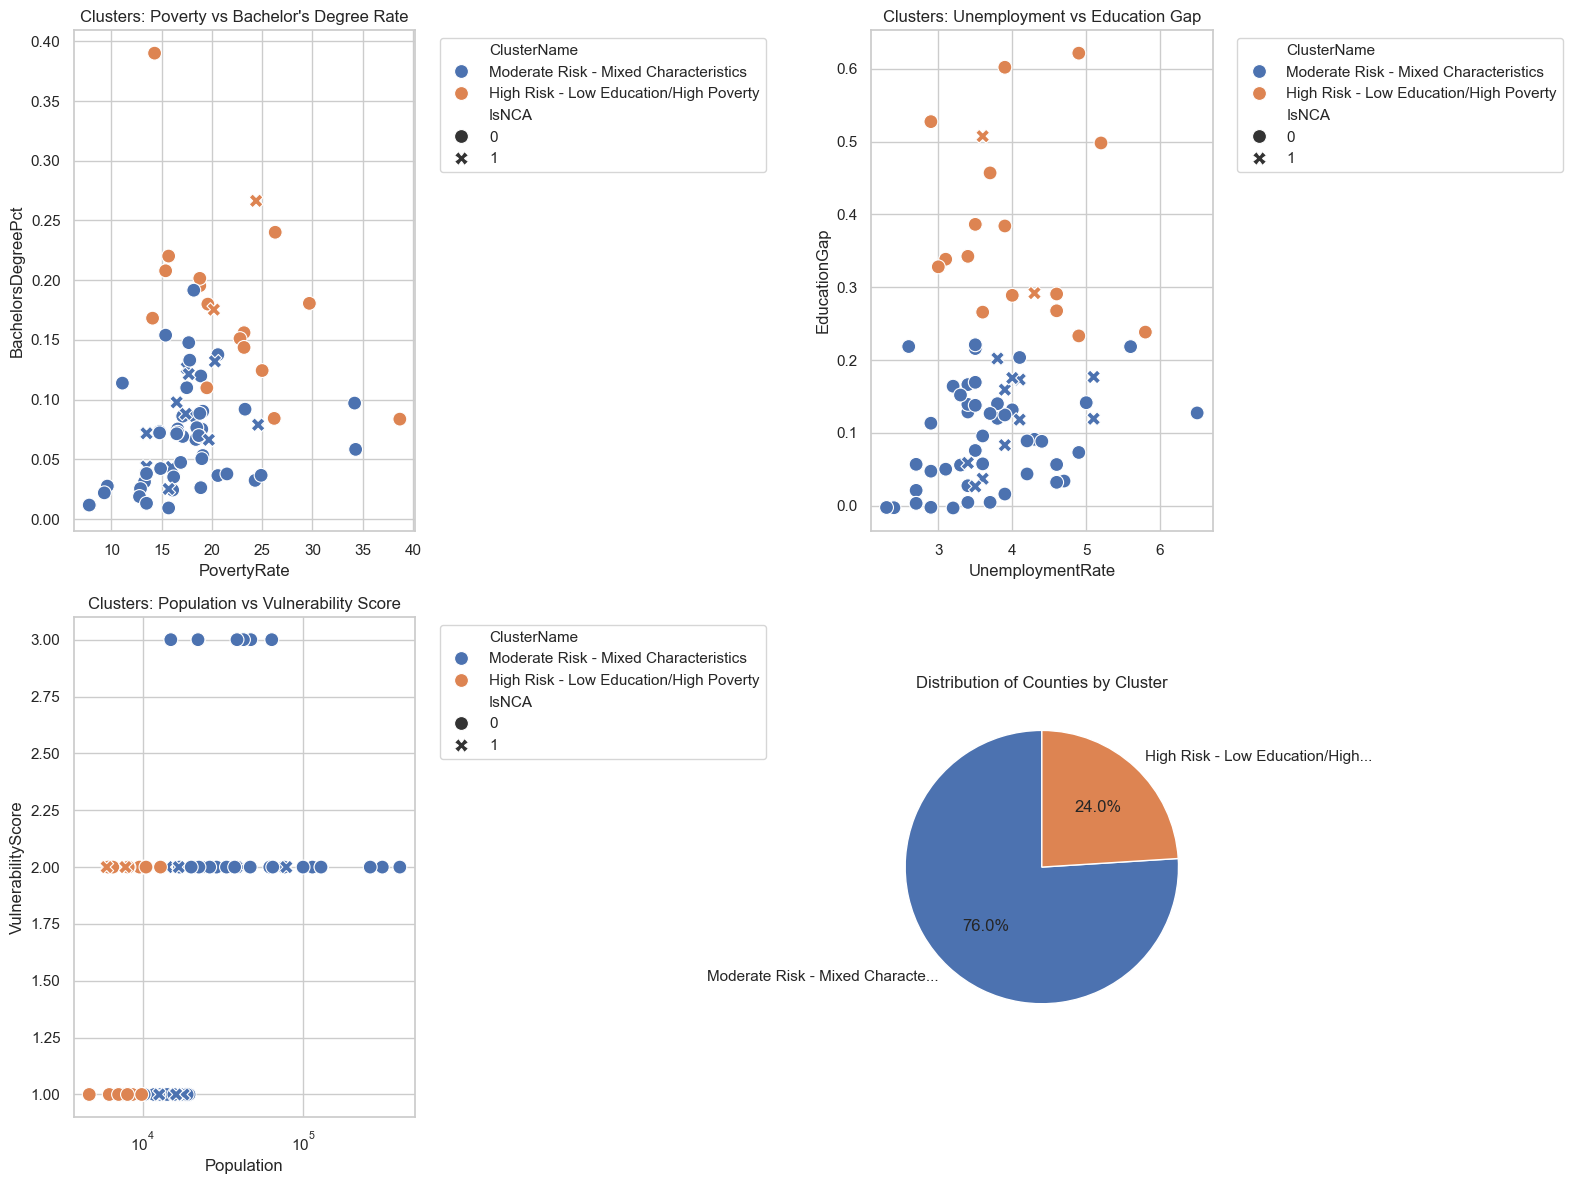

In [34]:
# Section 6.4: Cluster Visualization
print("\nSection 6.3: Creating Cluster Visualizations")

# Multi-dimensional cluster visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Poverty vs Bachelor's Degree
sns.scatterplot(data=df_fe_ar.reset_index(), x='PovertyRate', y='BachelorsDegreePct', 
                hue='ClusterName', style='IsNCA', s=100, ax=axes[0,0])
axes[0,0].set_title('Clusters: Poverty vs Bachelor\'s Degree Rate')
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Unemployment vs Education Gap
sns.scatterplot(data=df_fe_ar.reset_index(), x='UnemploymentRate', y='EducationGap',
                hue='ClusterName', style='IsNCA', s=100, ax=axes[0,1])
axes[0,1].set_title('Clusters: Unemployment vs Education Gap')
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 3: Population vs Vulnerability Score
sns.scatterplot(data=df_fe_ar.reset_index(), x='Population', y='VulnerabilityScore',
                hue='ClusterName', style='IsNCA', s=100, ax=axes[1,0])
axes[1,0].set_title('Clusters: Population vs Vulnerability Score')
axes[1,0].set_xscale('log')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 4: Cluster distribution
cluster_counts = df_fe_ar['ClusterName'].value_counts()
axes[1,1].pie(cluster_counts.values, labels=[name[:30] + '...' if len(name) > 30 else name for name in cluster_counts.index], 
              autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Distribution of Counties by Cluster')

plt.tight_layout()
plt.savefig(image_dir / "comprehensive_cluster_analysis.png", dpi=300, bbox_inches='tight')
plt.show()


## Section 6.5: Predictive Model Development

In [35]:
# Section 6.5: Predictive Model Development

# Prepare features for modeling
modeling_features = [
    'BachelorsDegreePct_Scaled',
    'HighSchoolGradPct_Scaled',
    'PovertyRate_Scaled', 
    'UnemploymentRate_Scaled',
    'EducationGap_Scaled',
    'Population_Scaled'
]

X = df_fe_ar[modeling_features]
y = df_fe_ar['ClusterLabel']

# Enhanced train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Training set size: {X_train.shape[0]} counties")
print(f"Test set size: {X_test.shape[0]} counties")
print(f"Feature dimensions: {X_train.shape[1]} features")

# Define and filter models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42, min_samples_split=5),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5) if 'KNeighborsClassifier' in dir() else None
}
models = {name: model for name, model in models.items() if model is not None}

# Evaluate models
model_results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    # Cross-validation
    cv_scores = cross_val_score(
        model, X, y,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='accuracy'
    )

    y_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)

    model_results[name] = {
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': test_accuracy,
        'y_pred': y_pred
    }

    print(f"Cross-validation accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
    print(f"Test accuracy: {test_accuracy:.3f}")

# Identify best model
best_model_name = max(model_results, key=lambda x: model_results[x]['cv_mean'])
best_model = model_results[best_model_name]['model']
best_predictions = model_results[best_model_name]['y_pred']

print(f"\nBest performing model: {best_model_name}")
print(f"Best CV accuracy: {model_results[best_model_name]['cv_mean']:.3f}")


Training set size: 52 counties
Test set size: 23 counties
Feature dimensions: 6 features

Training Random Forest...
Cross-validation accuracy: 0.973 (+/- 0.107)
Test accuracy: 1.000

Training Decision Tree...
Cross-validation accuracy: 1.000 (+/- 0.000)
Test accuracy: 1.000

Training K-Nearest Neighbors...
Cross-validation accuracy: 0.987 (+/- 0.053)
Test accuracy: 1.000

Best performing model: Decision Tree
Best CV accuracy: 1.000


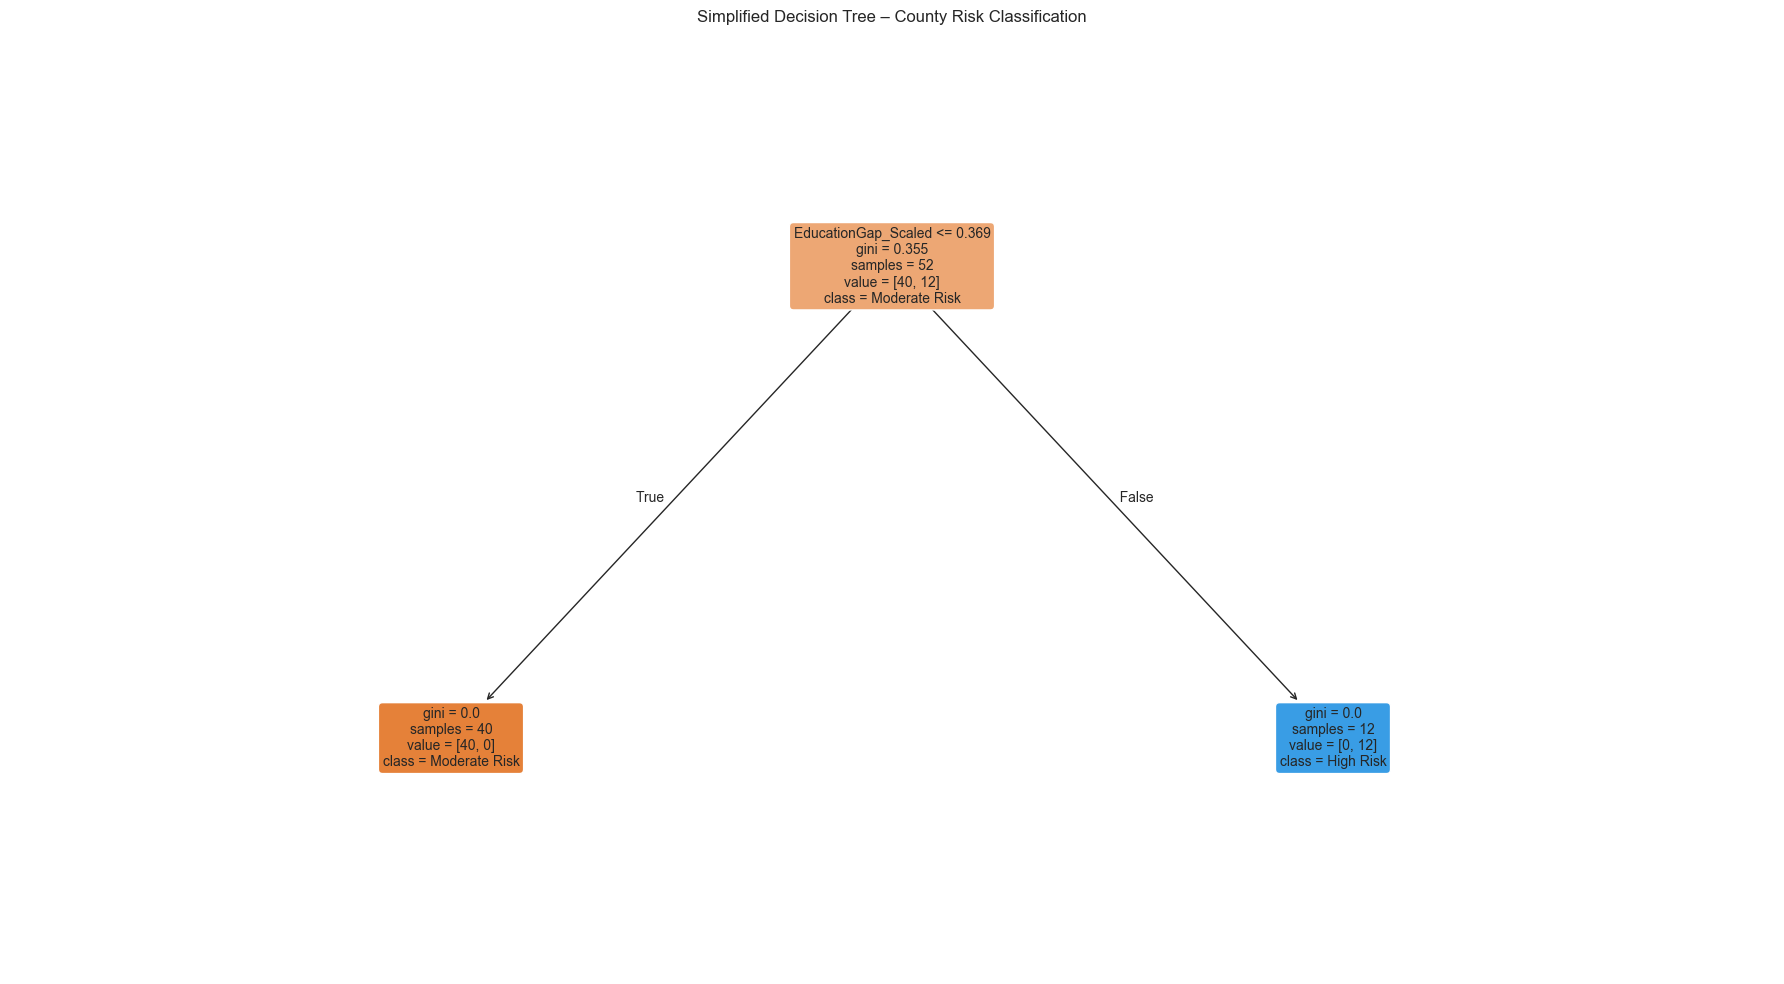

In [36]:
# 6.5.0 Decision Tree Diagram
# --- Always Generate Decision Tree Diagram ---

# Retrain Decision Tree independently to ensure consistent output
tree_model = DecisionTreeClassifier(max_depth=6, random_state=42, min_samples_split=5)
tree_model.fit(X_train, y_train)

plt.figure(figsize=(18, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Moderate Risk", "High Risk"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # Optional: adjust for clarity
)
plt.title("Simplified Decision Tree – County Risk Classification")
plt.tight_layout()
plt.savefig(image_dir / "decision_tree_diagram.png", dpi=300, bbox_inches='tight')
plt.show()


## Section 6.6: Model Evaluation and Interpretation


Section 6.6: Detailed Model Evaluation
Classification Report for Best Model:
                                        precision    recall  f1-score   support

 Moderate Risk - Mixed Characteristics       1.00      1.00      1.00        17
High Risk - Low Education/High Poverty       1.00      1.00      1.00         6

                              accuracy                           1.00        23
                             macro avg       1.00      1.00      1.00        23
                          weighted avg       1.00      1.00      1.00        23



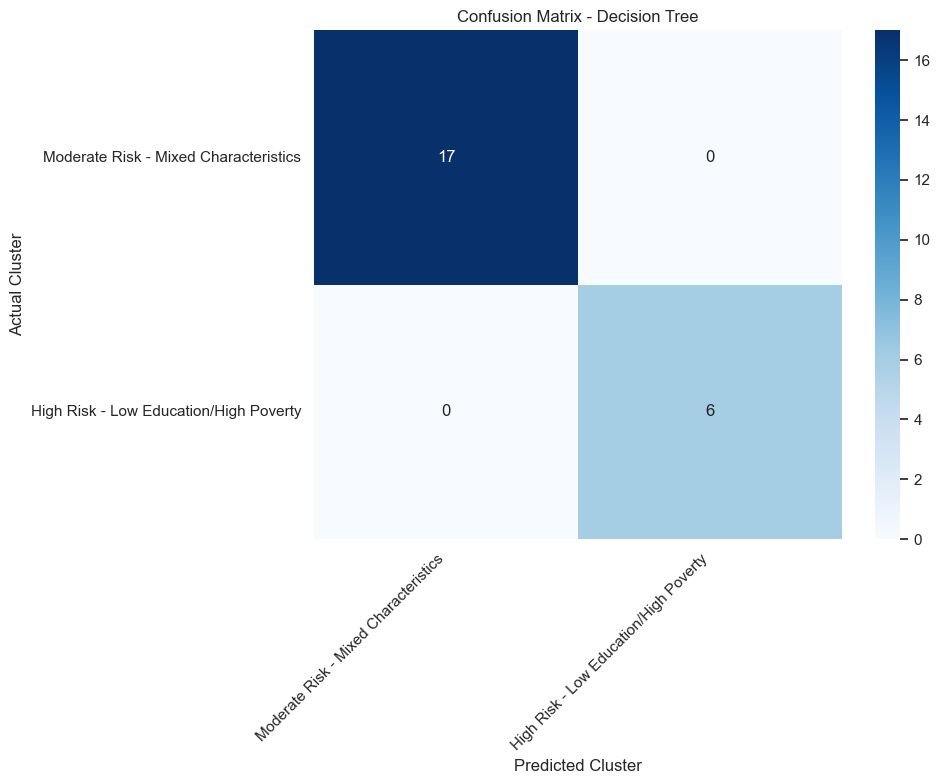

In [37]:
# Section 6.6: Model Evaluation and Interpretation
print("\nSection 6.6: Detailed Model Evaluation")

# Detailed classification report
print("Classification Report for Best Model:")
print(classification_report(y_test, best_predictions, 
                          target_names=[cluster_names[i] for i in sorted(cluster_names.keys())]))

# Confusion matrix visualization
cm = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[cluster_names[i] for i in sorted(cluster_names.keys())],
            yticklabels=[cluster_names[i] for i in sorted(cluster_names.keys())])

plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Cluster')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(image_dir / "final_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()


### 6.6.1  Decision Tree

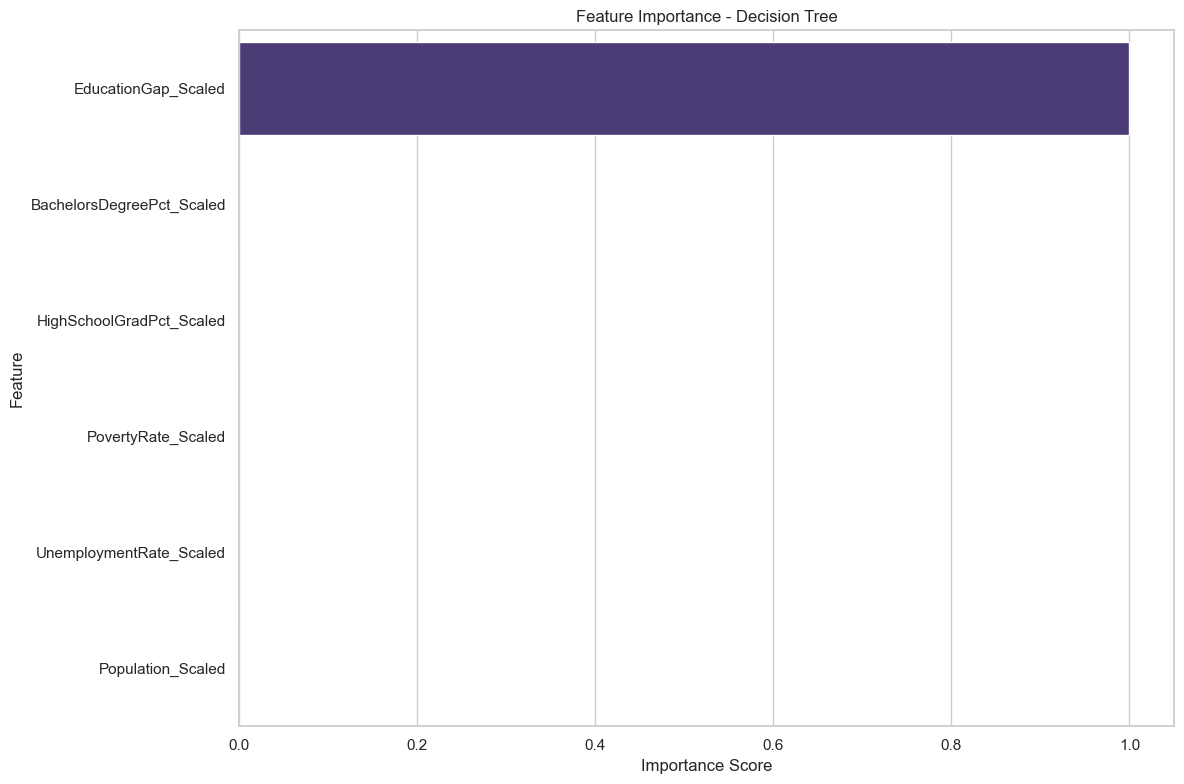


Top 3 Most Important Features:
5. EducationGap_Scaled: 1.000
1. BachelorsDegreePct_Scaled: 0.000
2. HighSchoolGradPct_Scaled: 0.000


In [38]:
# 6.6.1  Decision Tree
#  Feature importance analysis (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': modeling_features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance, x='Importance', y='Feature', 
                palette=variable_colors.values() if len(variable_colors) >= len(feature_importance) else 'viridis')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig(image_dir / "feature_importance_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nTop 3 Most Important Features:")
    for i, row in feature_importance.head(3).iterrows():
        print(f"{i+1}. {row['Feature']}: {row['Importance']:.3f}")

### 6.6.2  Random Forest 

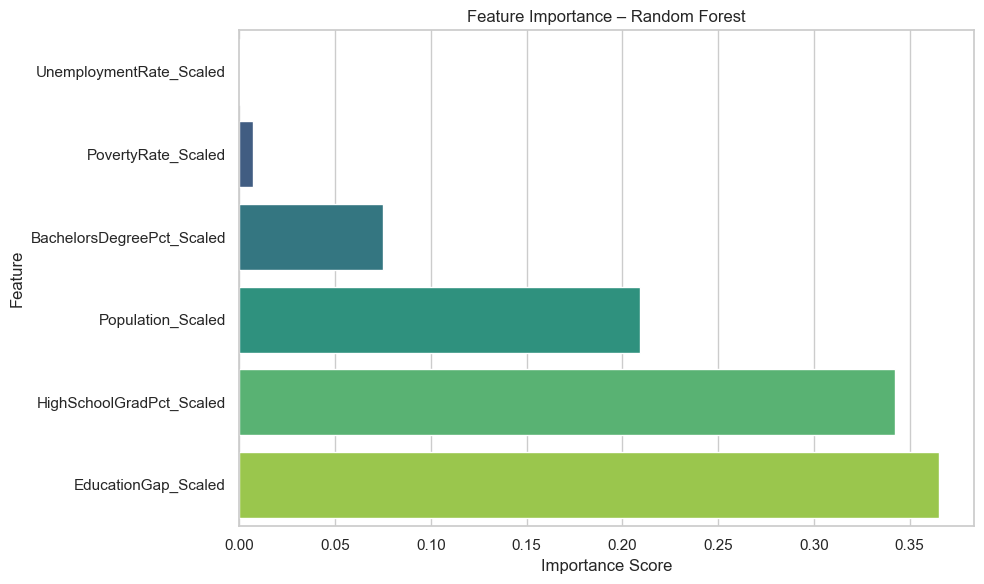

In [39]:
# Random Forest
# Section 6.5.2: Random Forest Feature Importance Analysis
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

# Get importance
rf_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=True)

# Predict on test set
y_rf_pred = rf_model.predict(X_test)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importances, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance – Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(image_dir / "feature_importance_rf.png", dpi=300, bbox_inches='tight')
plt.show()


### Section 6.5b: Policy Implications

In [40]:
# Section 6.5b: Policy Implications
print("\nPolicy Implications and Recommendations:")

# Identify high-priority counties
high_risk_counties = df_fe_ar[df_fe_ar['VulnerabilityScore'] >= 4]
print(f"High-priority counties for intervention: {len(high_risk_counties)}")

# NCA-specific recommendations
nca_risk_profile = df_fe_ar[df_fe_ar['IsNCA'] == 1]['RiskCategory'].value_counts()
print("NCA Risk Profile for targeted programs:")
display(nca_risk_profile)


Policy Implications and Recommendations:
High-priority counties for intervention: 0
NCA Risk Profile for targeted programs:


RiskCategory
Low Risk          9
High Risk         4
Moderate Risk     0
Very High Risk    0
Name: count, dtype: int64

## Section 6.7: Model Application and Insights

In [41]:
# Section 6.7: Model Application and Insights
print("\nSection 6.7: Applying Model Insights")

# Add predictions to main dataset
df_fe_ar['PredictedCluster'] = best_model.predict(X)
df_fe_ar['PredictedClusterName'] = df_fe_ar['PredictedCluster'].map(cluster_names)
df_fe_ar['PredictionAccuracy'] = (df_fe_ar['ClusterLabel'] == df_fe_ar['PredictedCluster']).astype(int)

# Analyze prediction accuracy by cluster
accuracy_by_cluster = df_fe_ar.groupby('ClusterLabel')['PredictionAccuracy'].agg(['mean', 'count']).round(3)
accuracy_by_cluster.columns = ['Accuracy', 'County_Count']

print("Prediction Accuracy by Cluster:")
display(accuracy_by_cluster)

# NCA-specific analysis
nca_counties = df_fe_ar[df_fe_ar['IsNCA'] == 1]
print("\nNCA Counties Analysis:")
print("Total NCA counties: {len(nca_counties)}")

nca_cluster_dist = nca_counties['ClusterName'].value_counts()
print("\nNCA Counties by Cluster:")
for cluster, count in nca_cluster_dist.items():
    percentage = (count / len(nca_counties)) * 100
    print("  {cluster}: {count} counties ({percentage:.1f}%)")




Section 6.7: Applying Model Insights
Prediction Accuracy by Cluster:


,Accuracy,County_Count
ClusterLabel,,
0,1.0,57
1,1.0,18



NCA Counties Analysis:
Total NCA counties: {len(nca_counties)}

NCA Counties by Cluster:
  {cluster}: {count} counties ({percentage:.1f}%)
  {cluster}: {count} counties ({percentage:.1f}%)


## Section 6.8: Save Results and Documentation

In [42]:
# Section 6.8: Save Results and Documentation
print("\nSection 6.8: Saving Results")

# Save clustering results
clustering_results = {
    'optimal_k': optimal_k,
    'silhouette_score': final_sil_score,
    'cluster_names': cluster_names,
    'best_model': best_model_name,
    'model_accuracy': model_results[best_model_name]['cv_mean']
}

# Save main results
df_fe_ar[['ClusterLabel', 'ClusterName', 'PredictedCluster', 'PredictedClusterName', 
          'PredictionAccuracy']].to_csv(output_dir / "clustering_and_prediction_results.csv")

# Save cluster summaries
cluster_summary_detailed = df_fe_ar.groupby(['ClusterLabel', 'ClusterName']).agg({
    'BachelorsDegreePct': ['mean', 'std', 'min', 'max'],
    'PovertyRate': ['mean', 'std', 'min', 'max'],
    'UnemploymentRate': ['mean', 'std', 'min', 'max'],
    'VulnerabilityScore': ['mean', 'std', 'min', 'max'],
    'IsNCA': ['sum', 'count'],
    'Population': ['mean', 'std', 'min', 'max']
}).round(2)

cluster_summary_detailed.to_csv(output_dir / "detailed_cluster_analysis.csv")

# Save model comparison results
model_comparison = pd.DataFrame({
    'Model': list(model_results.keys()),
    'CV_Mean_Accuracy': [results['cv_mean'] for results in model_results.values()],
    'CV_Std_Accuracy': [results['cv_std'] for results in model_results.values()],
    'Test_Accuracy': [results['test_accuracy'] for results in model_results.values()]
}).round(4)

model_comparison.to_csv(output_dir / "model_comparison_results.csv", index=False)

# Save feature importance if available
if hasattr(best_model, 'feature_importances_'):
    feature_importance.to_csv(output_dir / "feature_importance_rankings.csv", index=False)

print("Section 6 Complete: Advanced clustering and predictive modeling finished")
print("Key Results:")
print("  - Optimal clusters: {optimal_k}")
print("  - Best model: {best_model_name}")
print("  - Model accuracy: {model_results[best_model_name]['cv_mean']:.3f}")
print("  - Files saved to: {output_dir}")

logging.info("Section 6 advanced modeling completed successfully")


Section 6.8: Saving Results
Section 6 Complete: Advanced clustering and predictive modeling finished
Key Results:
  - Optimal clusters: {optimal_k}
  - Best model: {best_model_name}
  - Model accuracy: {model_results[best_model_name]['cv_mean']:.3f}
  - Files saved to: {output_dir}
2025-07-30 15:30:58,175 [INFO] Section 6 advanced modeling completed successfully


# Section 7: Advanced Visualizations and Mapping

## Section 7.1: Cluster-Based State Map Visualization

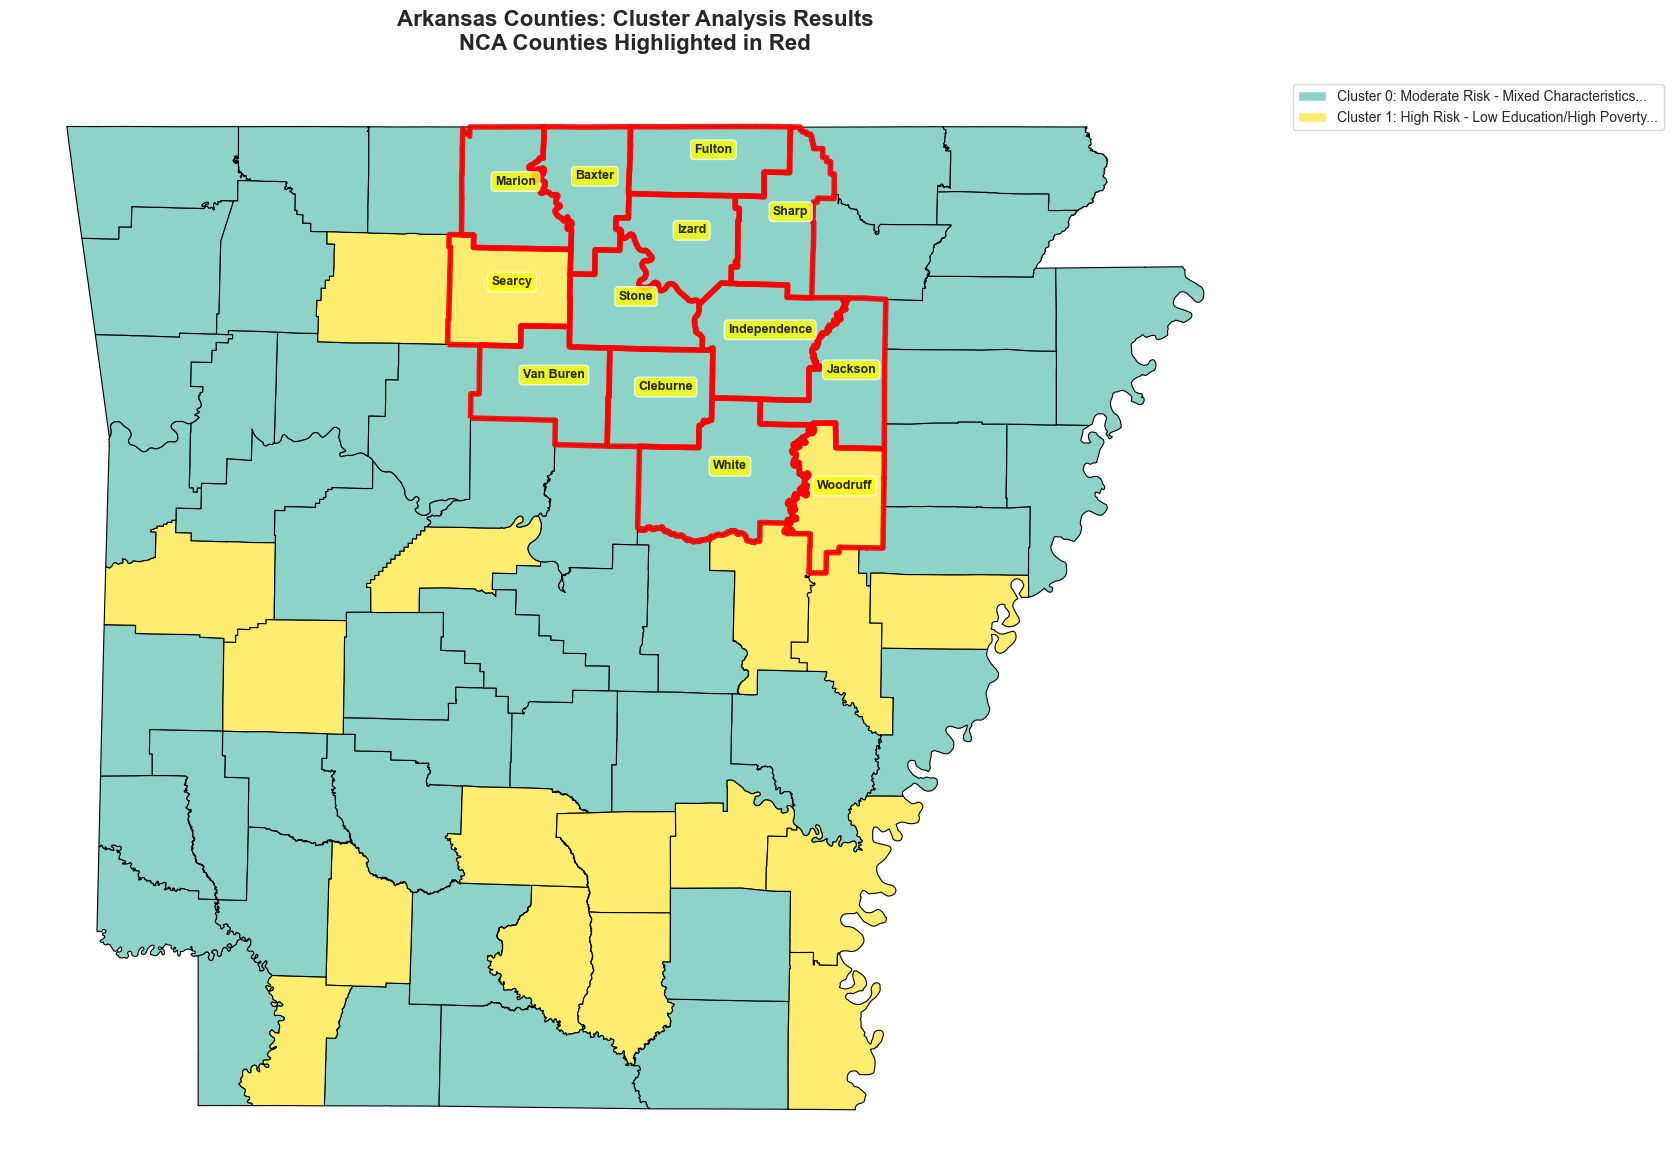

In [43]:
# Section 7.1: Cluster-Based State Map Visualization
# Ensure we have the geographic data
if 'arkansas_geo' not in locals():
    shapefile_path = Path("data") / "tl_2023_us_county.shp"
    us_counties = gpd.read_file(shapefile_path)
    arkansas_geo = us_counties[us_counties['STATEFP'] == '05'].copy()
    arkansas_geo['County'] = arkansas_geo['NAME'].str.title()

# Merge cluster results with geographic data
df_viz = df_fe_ar.reset_index()
df_viz['County'] = df_viz['county'].str.title()
arkansas_clusters = arkansas_geo.merge(df_viz[['County', 'ClusterLabel', 'ClusterName', 'VulnerabilityScore', 'IsNCA']], 
                                      on='County', how='left')

# Create cluster-based choropleth map
fig, ax = plt.subplots(figsize=(16, 12))

# Plot counties colored by cluster
arkansas_clusters.plot(column='ClusterLabel', 
                      cmap='Set3', 
                      linewidth=0.8,
                      ax=ax,
                      edgecolor='black',
                      legend=False,
                      missing_kwds={'color': 'lightgray'})

# Highlight NCA counties with bold borders
nca_counties_geo = arkansas_clusters[arkansas_clusters['IsNCA'] == 1]
nca_counties_geo.boundary.plot(ax=ax, color='red', linewidth=4, alpha=0.9)

# Add county labels for NCA counties
for idx, row in nca_counties_geo.iterrows():
    if pd.notna(row['geometry']):
        centroid = row['geometry'].centroid
        ax.annotate(row['County'], 
                   xy=(centroid.x, centroid.y),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=9, fontweight='bold',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.8),
                   ha='center')

# Create custom legend for clusters
cluster_colors = plt.cm.Set3(np.linspace(0, 1, len(df_fe_ar['ClusterLabel'].unique())))
legend_elements = []
for i, (cluster_id, cluster_name) in enumerate(zip(sorted(df_fe_ar['ClusterLabel'].unique()), 
                                                  [df_fe_ar[df_fe_ar['ClusterLabel']==c]['ClusterName'].iloc[0] 
                                                   for c in sorted(df_fe_ar['ClusterLabel'].unique())])):
    legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=cluster_colors[i], 
                                       label=f"Cluster {cluster_id}: {cluster_name[:40]}..."))

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
ax.set_title('Arkansas Counties: Cluster Analysis Results\nNCA Counties Highlighted in Red', 
             fontsize=16, pad=20, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(map_dir / "arkansas_cluster_map_comprehensive.png", dpi=300, bbox_inches='tight')
plt.show()

## Section 7.2: Vulnerability Score Heat Map


Section 7.2: Vulnerability Score Heat Map


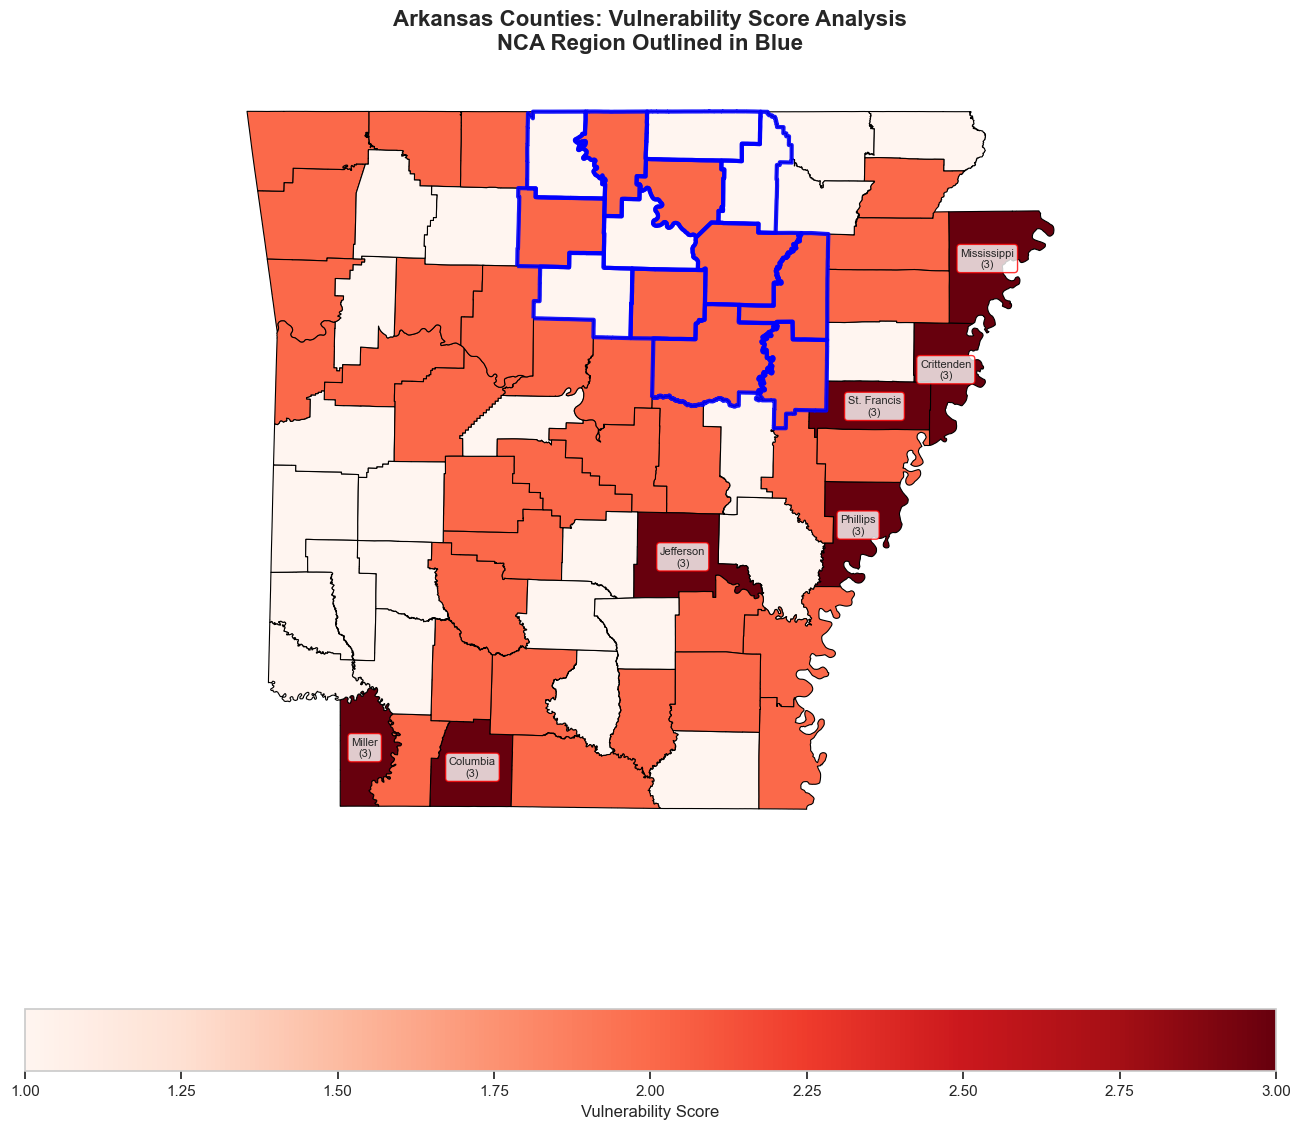

In [44]:
# Section 7.2: Vulnerability Score Heat Map
print("\nSection 7.2: Vulnerability Score Heat Map")

fig, ax = plt.subplots(figsize=(16, 12))

# Create vulnerability heat map
arkansas_clusters.plot(column='VulnerabilityScore',
                      cmap='Reds',
                      linewidth=0.8,
                      ax=ax,
                      edgecolor='black',
                      legend=True,
                      legend_kwds={'label': 'Vulnerability Score', 'shrink': 0.8, 'orientation': 'horizontal'},
                      missing_kwds={'color': 'lightgray'})

# Overlay NCA boundaries
nca_counties_geo.boundary.plot(ax=ax, color='blue', linewidth=3, alpha=0.9)

# Add vulnerability score labels for high-risk counties
high_vuln_counties = arkansas_clusters[arkansas_clusters['VulnerabilityScore'] >= 3]
for idx, row in high_vuln_counties.iterrows():
    if pd.notna(row['geometry']):
        centroid = row['geometry'].centroid
        ax.annotate(f"{row['County']}\n({row['VulnerabilityScore']:.0f})", 
                   xy=(centroid.x, centroid.y),
                   fontsize=8, ha='center', va='center',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor='red'))

ax.set_title('Arkansas Counties: Vulnerability Score Analysis\nNCA Region Outlined in Blue', 
             fontsize=16, pad=20, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(map_dir / "arkansas_vulnerability_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


## Section 7.3: Multi-Panel Comparison Dashboard


Section 7.3: Multi-Panel State Comparison Dashboard


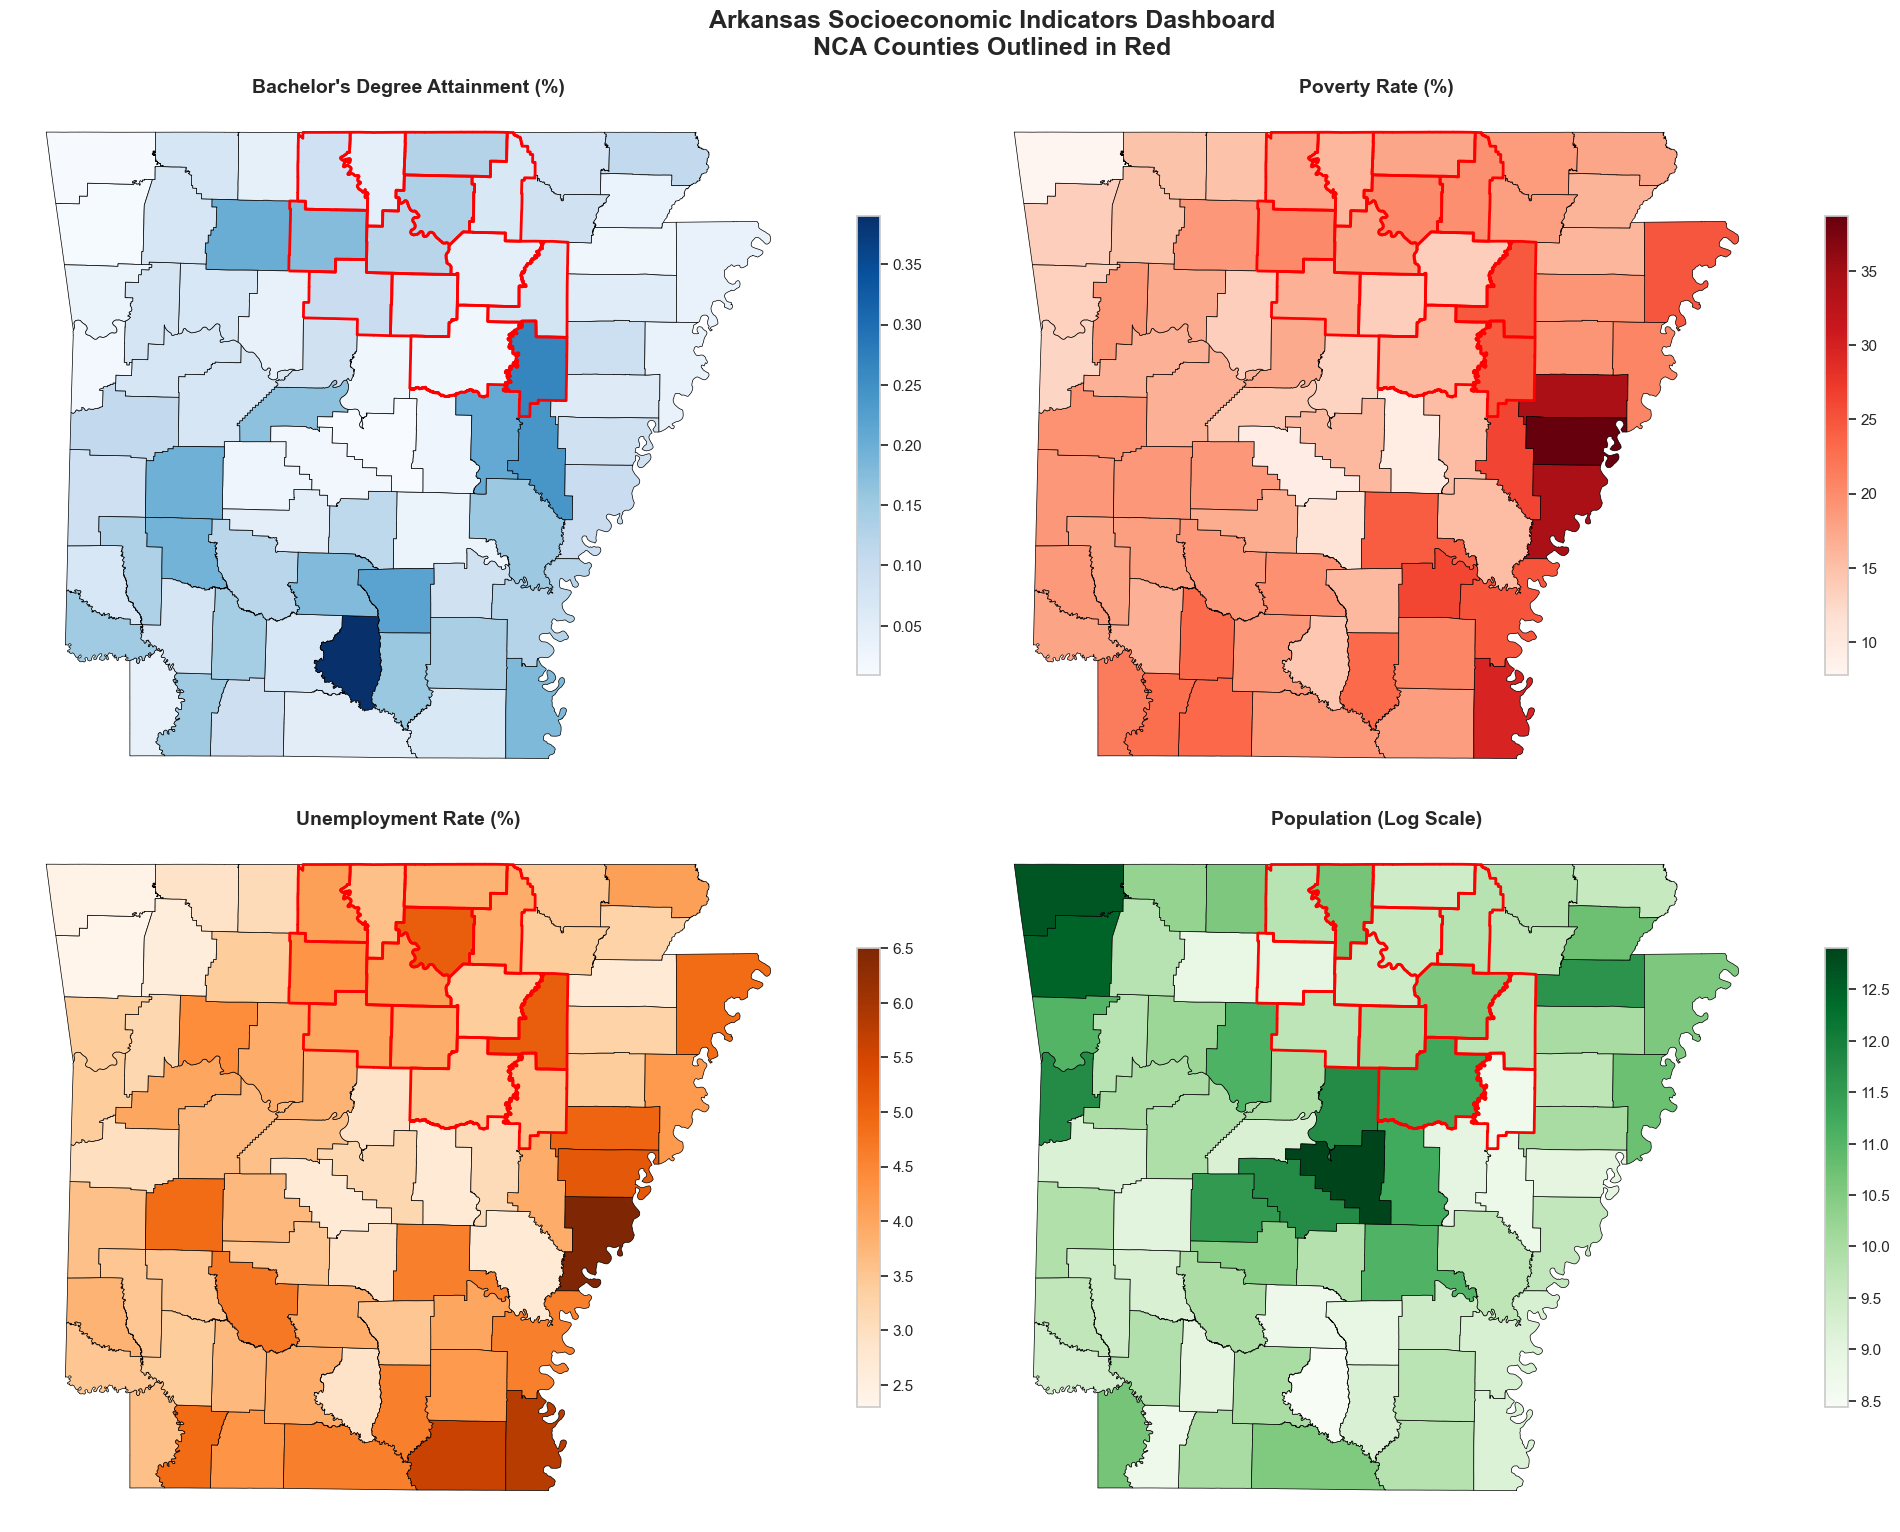

In [45]:
# Section 7.3: Multi-Panel Comparison Dashboard
print("\nSection 7.3: Multi-Panel State Comparison Dashboard")

# Ensure all needed columns are present in arkansas_clusters
needed_cols = [
    'County', 'ClusterLabel', 'ClusterName', 'VulnerabilityScore', 'IsNCA',
    'BachelorsDegreePct', 'PovertyRate', 'UnemploymentRate', 'Population'
]
df_viz = df_fe_ar.reset_index()
df_viz['County'] = df_viz['county'].str.title()
# Merge all needed columns for mapping
arkansas_clusters = arkansas_geo.merge(
    df_viz[needed_cols], on='County', how='left'
)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Panel 1: Education Levels
arkansas_clusters.plot(column='BachelorsDegreePct', cmap='Blues', ax=axes[0,0], 
                      edgecolor='black', linewidth=0.5, legend=True,
                      legend_kwds={'shrink': 0.6})
nca_counties_geo = arkansas_clusters[arkansas_clusters['IsNCA'] == 1]
nca_counties_geo.boundary.plot(ax=axes[0,0], color='red', linewidth=2)
axes[0,0].set_title('Bachelor\'s Degree Attainment (%)', fontsize=14, fontweight='bold')
axes[0,0].axis('off')

# Panel 2: Poverty Rates
arkansas_clusters.plot(column='PovertyRate', cmap='Reds', ax=axes[0,1],
                      edgecolor='black', linewidth=0.5, legend=True,
                      legend_kwds={'shrink': 0.6})
nca_counties_geo.boundary.plot(ax=axes[0,1], color='red', linewidth=2)
axes[0,1].set_title('Poverty Rate (%)', fontsize=14, fontweight='bold')
axes[0,1].axis('off')

# Panel 3: Unemployment Rates
arkansas_clusters.plot(column='UnemploymentRate', cmap='Oranges', ax=axes[1,0],
                      edgecolor='black', linewidth=0.5, legend=True,
                      legend_kwds={'shrink': 0.6})
nca_counties_geo.boundary.plot(ax=axes[1,0], color='red', linewidth=2)
axes[1,0].set_title('Unemployment Rate (%)', fontsize=14, fontweight='bold')
axes[1,0].axis('off')

# Panel 4: Population Density (log scale)
arkansas_clusters['PopulationLog'] = np.log1p(arkansas_clusters['Population'])
arkansas_clusters.plot(column='PopulationLog', cmap='Greens', ax=axes[1,1],
                      edgecolor='black', linewidth=0.5, legend=True,
                      legend_kwds={'shrink': 0.6})
nca_counties_geo.boundary.plot(ax=axes[1,1], color='red', linewidth=2)
axes[1,1].set_title('Population (Log Scale)', fontsize=14, fontweight='bold')
axes[1,1].axis('off')

plt.suptitle('Arkansas Socioeconomic Indicators Dashboard\nNCA Counties Outlined in Red', 
             fontsize=18, y=0.98, fontweight='bold')
plt.tight_layout()
plt.savefig(map_dir / "arkansas_dashboard_comprehensive.png", dpi=300, bbox_inches='tight')
plt.show()

# Section 7.4: Interactive-Style Cluster Profiles


Section 7.4: Detailed Cluster Profile Visualizations


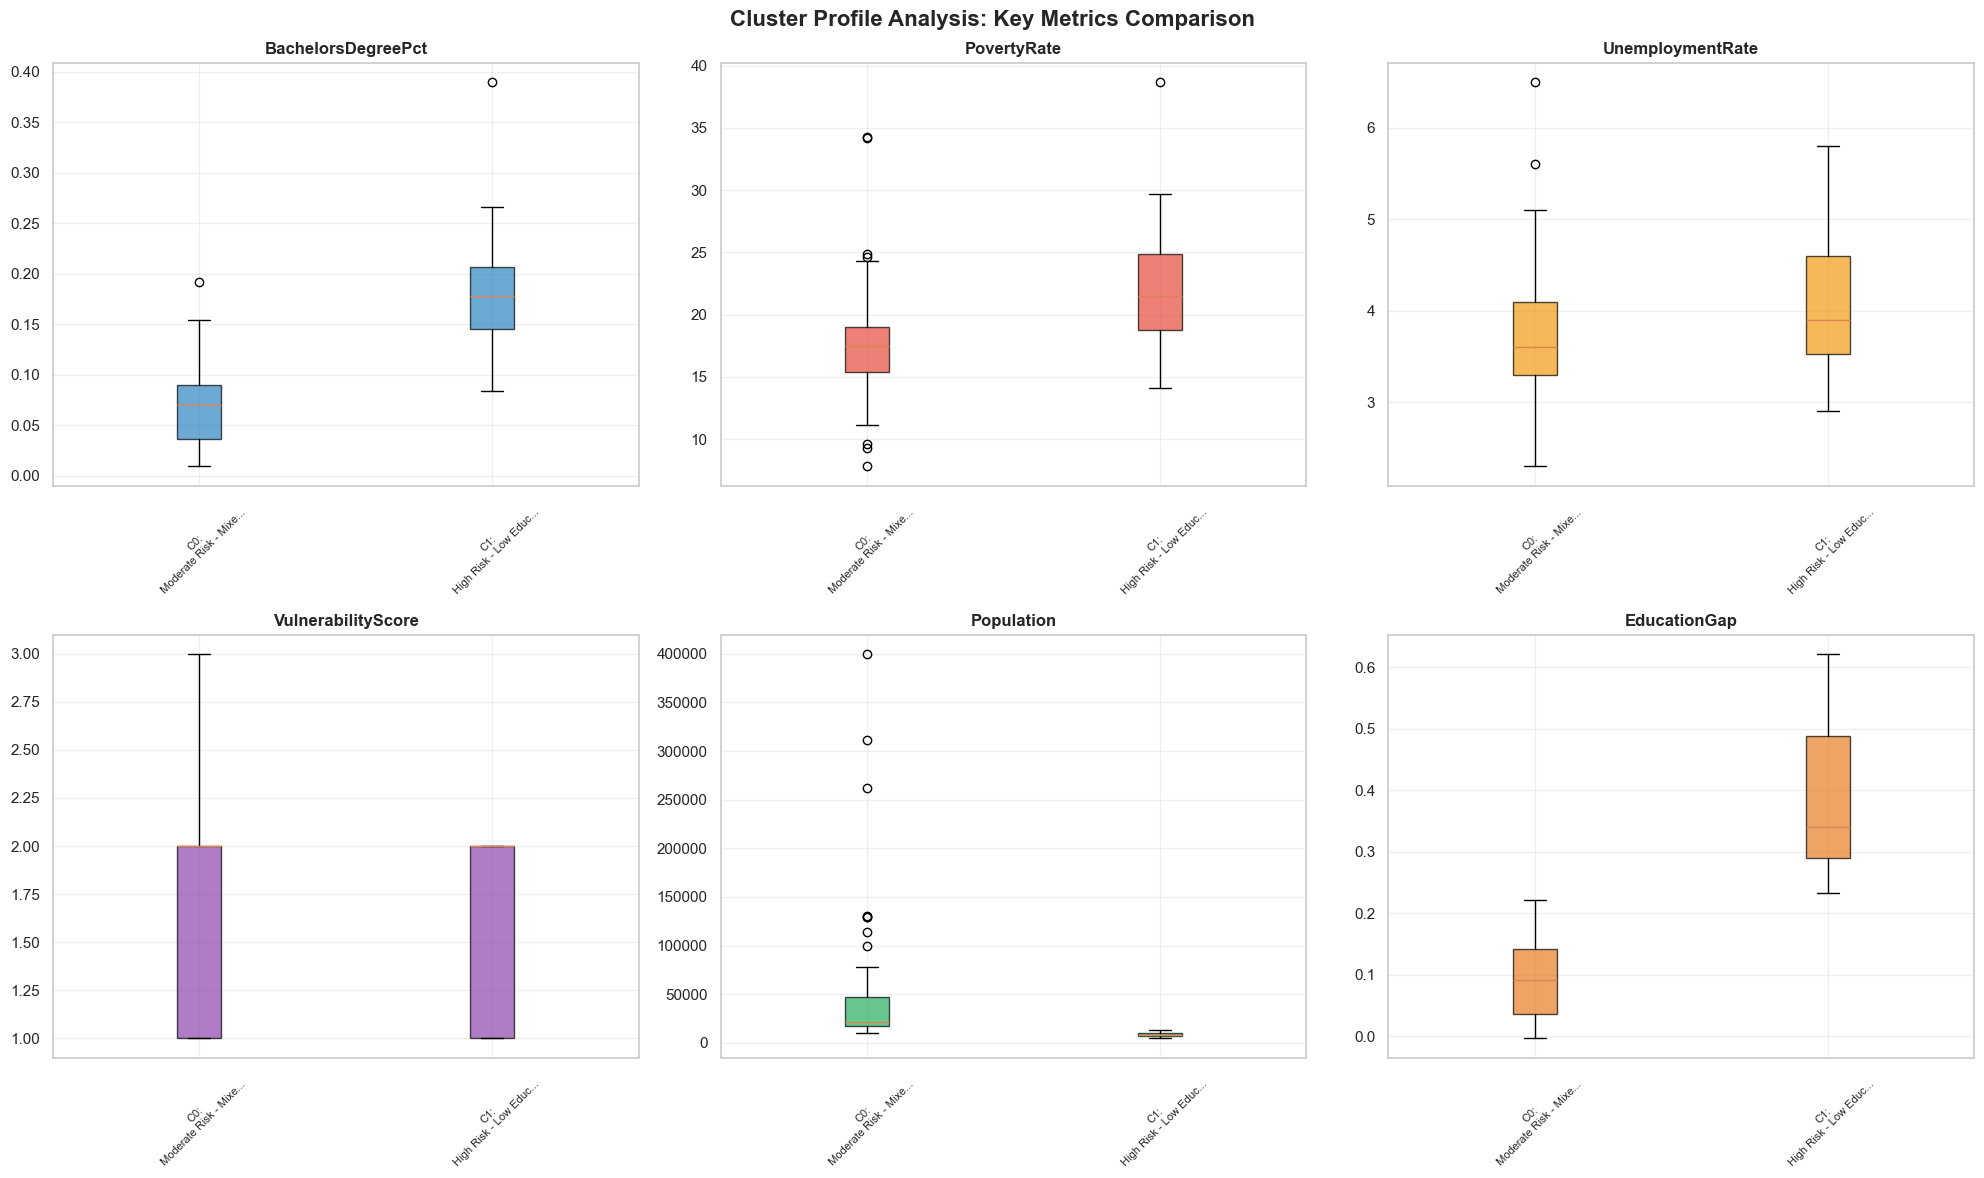

In [46]:
# Section 7.4: Interactive-Style Cluster Profiles
print("\nSection 7.4: Detailed Cluster Profile Visualizations")

# Create comprehensive cluster comparison
n_clusters = len(df_fe_ar['ClusterLabel'].unique())
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

metrics = ['BachelorsDegreePct', 'PovertyRate', 'UnemploymentRate', 
          'VulnerabilityScore', 'Population', 'EducationGap']
metric_colors = ['#2E86C1', '#E74C3C', '#F39C12', '#8E44AD', '#27AE60', '#E67E22']

for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    ax = axes[i]
    
    # Box plot by cluster
    cluster_data = []
    cluster_labels = []
    for cluster_id in sorted(df_fe_ar['ClusterLabel'].unique()):
        cluster_subset = df_fe_ar[df_fe_ar['ClusterLabel'] == cluster_id]
        cluster_data.append(cluster_subset[metric].values)
        cluster_name = cluster_subset['ClusterName'].iloc[0]
        cluster_labels.append(f"C{cluster_id}:\n{cluster_name[:20]}...")
    
    bp = ax.boxplot(cluster_data, labels=cluster_labels, patch_artist=True)
    
    # Color boxes
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(True, alpha=0.3)

# Remove empty subplot
if len(axes) > len(metrics):
    fig.delaxes(axes[-1])

plt.suptitle('Cluster Profile Analysis: Key Metrics Comparison', 
             fontsize=16, y=0.98, fontweight='bold')
plt.tight_layout()
plt.savefig(map_dir / "cluster_profiles_detailed.png", dpi=300, bbox_inches='tight')
plt.show()

## Section 7.5: NCA-Focused Analysis Map


Section 7.5: NCA-Focused Regional Analysis


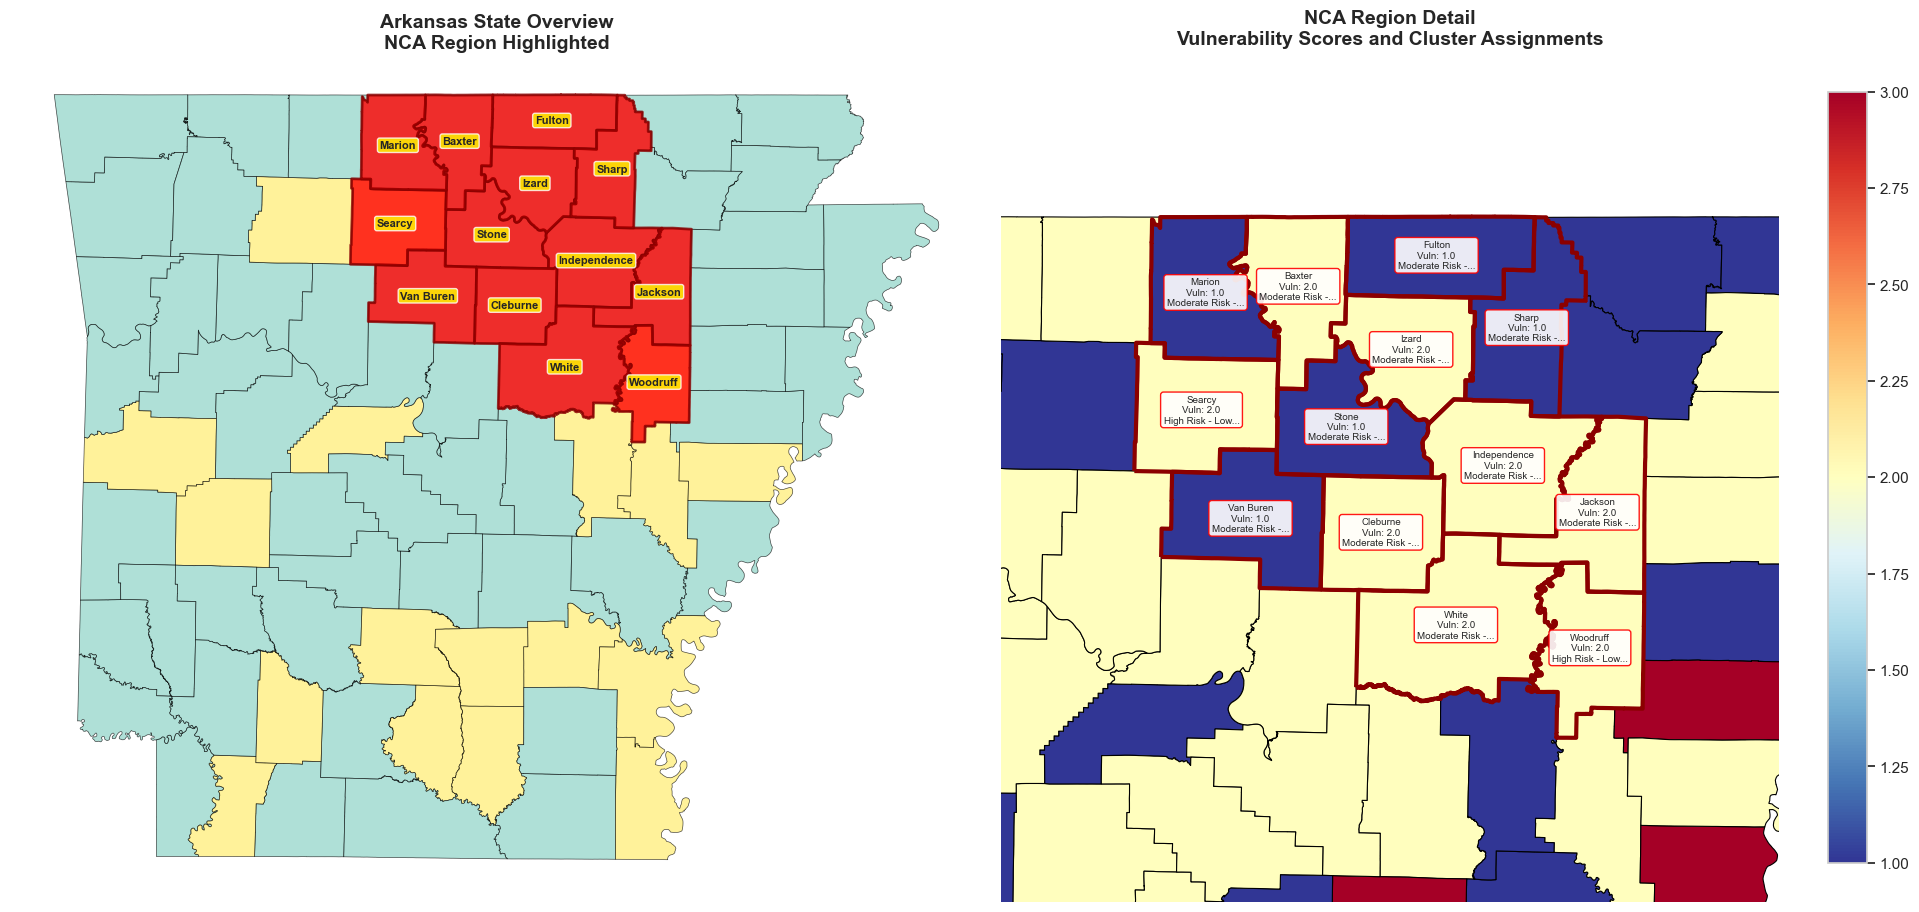

In [47]:
# Section 7.5: NCA-Focused Analysis Map
print("\nSection 7.5: NCA-Focused Regional Analysis")

# Create zoomed map of NCA region
nca_bounds = nca_counties_geo.total_bounds
buffer = 0.5  # Degree buffer around NCA region

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Left panel: Full state with NCA highlighted
arkansas_clusters.plot(column='ClusterLabel', cmap='Set3', ax=ax1, 
                      edgecolor='black', linewidth=0.5, alpha=0.7)
nca_counties_geo.plot(ax=ax1, color='red', alpha=0.8, edgecolor='darkred', linewidth=2)

# Add NCA county labels
for idx, row in nca_counties_geo.iterrows():
    if pd.notna(row['geometry']):
        centroid = row['geometry'].centroid
        ax1.annotate(row['County'], xy=(centroid.x, centroid.y),
                    fontsize=8, ha='center', va='center', fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.8))

ax1.set_title('Arkansas State Overview\nNCA Region Highlighted', fontsize=14, fontweight='bold')
ax1.axis('off')

# Right panel: Zoomed NCA region
arkansas_clusters.plot(column='VulnerabilityScore', cmap='RdYlBu_r', ax=ax2,
                      edgecolor='black', linewidth=0.8, legend=True,
                      legend_kwds={'shrink': 0.8})
nca_counties_geo.boundary.plot(ax=ax2, color='darkred', linewidth=3)

# Add detailed labels for NCA counties
for idx, row in nca_counties_geo.iterrows():
    if pd.notna(row['geometry']):
        centroid = row['geometry'].centroid
        vuln_score = row['VulnerabilityScore'] if pd.notna(row['VulnerabilityScore']) else 0
        cluster_name = row['ClusterName'][:15] + '...' if pd.notna(row['ClusterName']) else 'Unknown'
        
        ax2.annotate(f"{row['County']}\nVuln: {vuln_score:.1f}\n{cluster_name}", 
                    xy=(centroid.x, centroid.y),
                    fontsize=7, ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor='red'))

# Set zoom bounds
ax2.set_xlim(nca_bounds[0] - buffer, nca_bounds[2] + buffer)
ax2.set_ylim(nca_bounds[1] - buffer, nca_bounds[3] + buffer)
ax2.set_title('NCA Region Detail\nVulnerability Scores and Cluster Assignments', 
              fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.savefig(map_dir / "nca_focused_analysis.png", dpi=300, bbox_inches='tight')
plt.show()


## Section 7.6: Statistical Summary Visualizations


Section 7.6: Statistical Summary and Comparison Charts


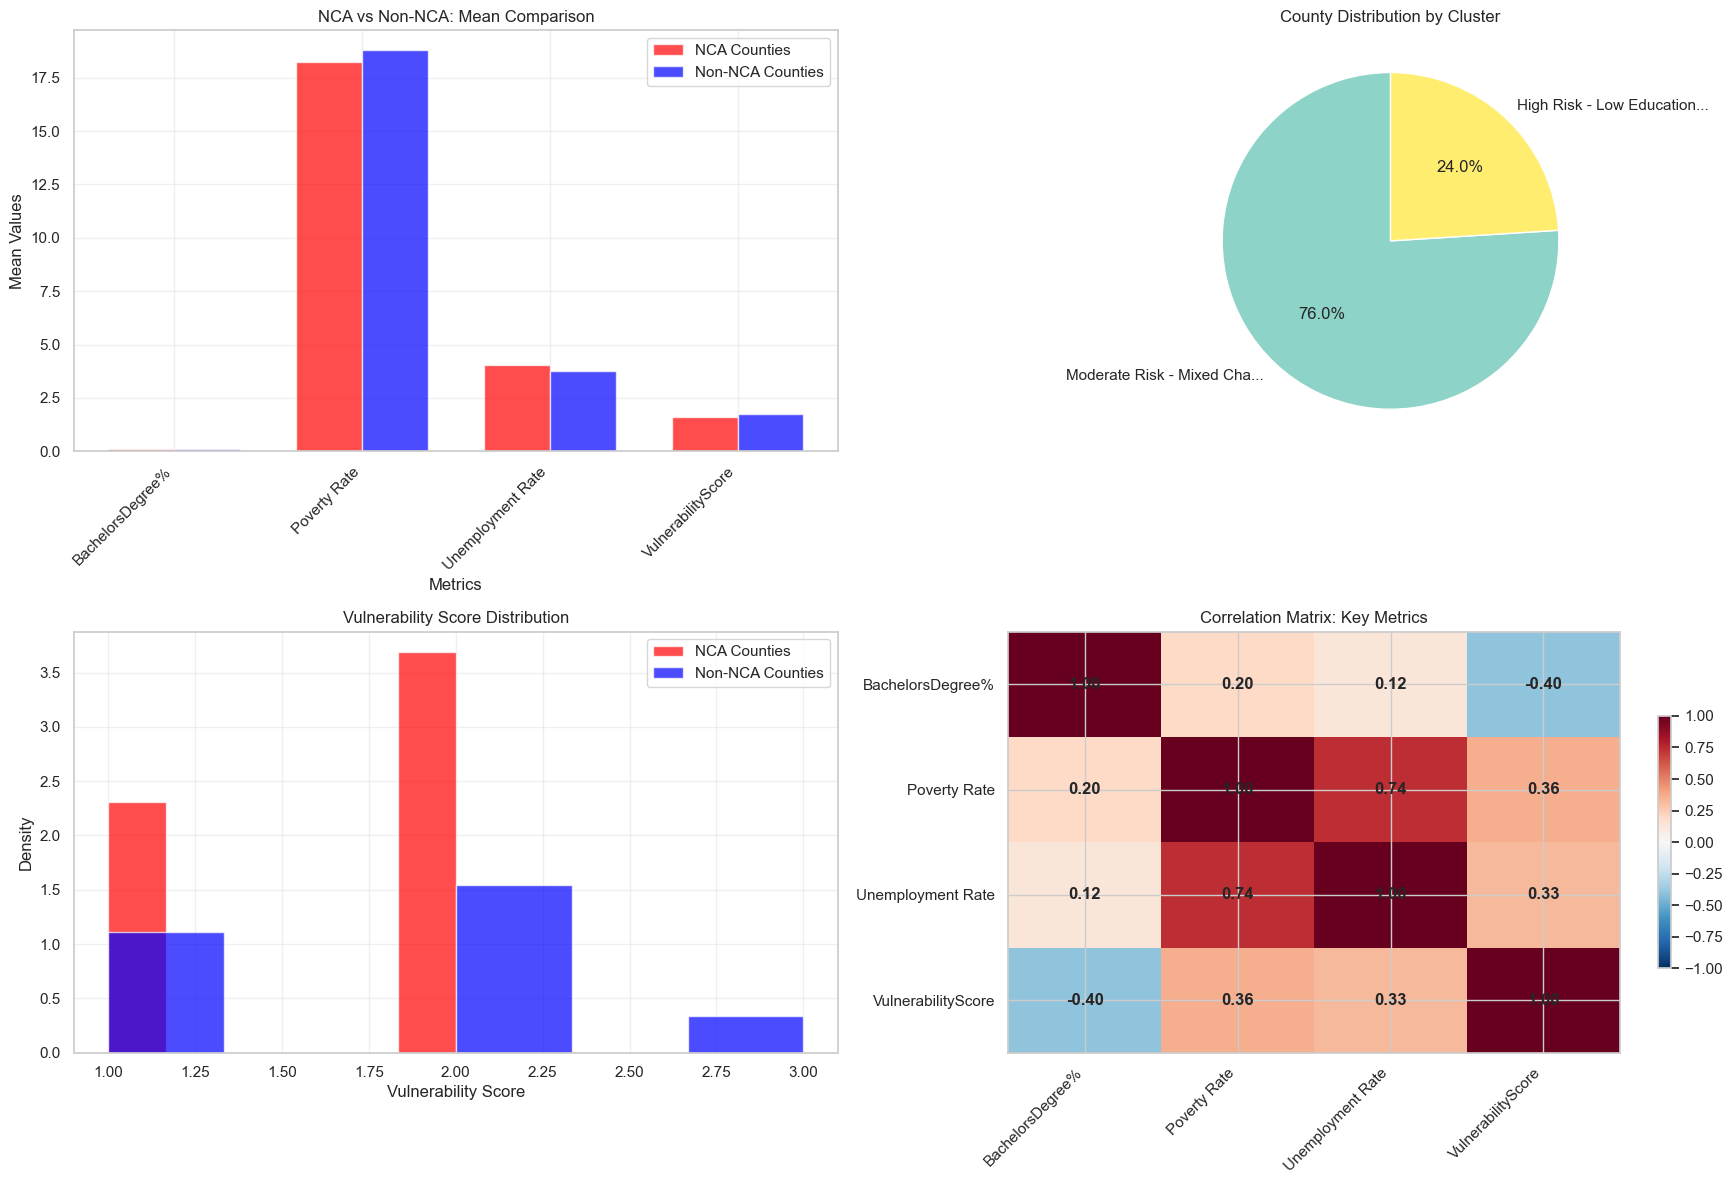

In [48]:
# Section 7.6: Statistical Summary Visualizations
print("\nSection 7.6: Statistical Summary and Comparison Charts")

# Create comprehensive statistical comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# NCA vs Non-NCA comparison
nca_comparison_data = []
metrics_for_comparison = ['BachelorsDegreePct', 'PovertyRate', 'UnemploymentRate', 'VulnerabilityScore']

for metric in metrics_for_comparison:
    nca_values = df_fe_ar[df_fe_ar['IsNCA'] == 1][metric]
    non_nca_values = df_fe_ar[df_fe_ar['IsNCA'] == 0][metric]
    
    nca_comparison_data.append({
        'Metric': metric,
        'NCA_Mean': nca_values.mean(),
        'Non_NCA_Mean': non_nca_values.mean(),
        'NCA_Std': nca_values.std(),
        'Non_NCA_Std': non_nca_values.std(),
        'Difference': nca_values.mean() - non_nca_values.mean()
    })

comparison_df = pd.DataFrame(nca_comparison_data)

# Plot 1: Mean comparison
x_pos = np.arange(len(metrics_for_comparison))
width = 0.35

axes[0,0].bar(x_pos - width/2, comparison_df['NCA_Mean'], width, 
              label='NCA Counties', color='red', alpha=0.7)
axes[0,0].bar(x_pos + width/2, comparison_df['Non_NCA_Mean'], width,
              label='Non-NCA Counties', color='blue', alpha=0.7)

axes[0,0].set_xlabel('Metrics')
axes[0,0].set_ylabel('Mean Values')
axes[0,0].set_title('NCA vs Non-NCA: Mean Comparison')
axes[0,0].set_xticks(x_pos)
axes[0,0].set_xticklabels([m.replace('Pct', '%').replace('Rate', ' Rate') for m in metrics_for_comparison], 
                         rotation=45, ha='right')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Cluster distribution
cluster_counts = df_fe_ar['ClusterName'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(cluster_counts)))
axes[0,1].pie(cluster_counts.values, labels=[name[:25] + '...' for name in cluster_counts.index], 
              autopct='%1.1f%%', colors=colors, startangle=90)
axes[0,1].set_title('County Distribution by Cluster')

# Plot 3: Vulnerability distribution
axes[1,0].hist(df_fe_ar[df_fe_ar['IsNCA'] == 1]['VulnerabilityScore'], 
               bins=6, alpha=0.7, label='NCA Counties', color='red', density=True)
axes[1,0].hist(df_fe_ar[df_fe_ar['IsNCA'] == 0]['VulnerabilityScore'], 
               bins=6, alpha=0.7, label='Non-NCA Counties', color='blue', density=True)
axes[1,0].set_xlabel('Vulnerability Score')
axes[1,0].set_ylabel('Density')
axes[1,0].set_title('Vulnerability Score Distribution')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Correlation heatmap for key metrics
correlation_matrix = df_fe_ar[metrics_for_comparison].corr()
im = axes[1,1].imshow(correlation_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[1,1].set_xticks(range(len(metrics_for_comparison)))
axes[1,1].set_yticks(range(len(metrics_for_comparison)))
axes[1,1].set_xticklabels([m.replace('Pct', '%').replace('Rate', ' Rate') for m in metrics_for_comparison], 
                         rotation=45, ha='right')
axes[1,1].set_yticklabels([m.replace('Pct', '%').replace('Rate', ' Rate') for m in metrics_for_comparison])
axes[1,1].set_title('Correlation Matrix: Key Metrics')

# Add correlation values
for i in range(len(metrics_for_comparison)):
    for j in range(len(metrics_for_comparison)):
        axes[1,1].text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                      ha='center', va='center', fontweight='bold')

plt.colorbar(im, ax=axes[1,1], shrink=0.6)

plt.tight_layout()
plt.savefig(map_dir / "statistical_summary_comprehensive.png", dpi=300, bbox_inches='tight')
plt.show()


## Section 7.7: Save Advanced Visualization Data

In [49]:
# Section 7.7: Save Advanced Visualization Data
print("\nSection 7.7: Saving Advanced Visualization Data")

# Save geographic data with cluster information
arkansas_clusters.to_file(output_dir / "arkansas_counties_with_clusters.shp")

# Save NCA-specific analysis
nca_analysis = df_fe_ar[df_fe_ar['IsNCA'] == 1][['ClusterLabel', 'ClusterName', 'VulnerabilityScore', 
                                                'BachelorsDegreePct', 'PovertyRate', 'UnemploymentRate']]
nca_analysis.to_csv(output_dir / "nca_counties_detailed_analysis.csv")

# Save comparison statistics
comparison_df.to_csv(output_dir / "nca_vs_non_nca_comparison.csv", index=False)

# Save cluster geographic summary
cluster_geo_summary = arkansas_clusters.groupby('ClusterLabel').agg({
    'County': 'count',
    'IsNCA': 'sum',
    'VulnerabilityScore': ['mean', 'std'],
    'BachelorsDegreePct': ['mean', 'std'],
    'PovertyRate': ['mean', 'std']
}).round(3)

cluster_geo_summary.to_csv(output_dir / "cluster_geographic_summary.csv")

print("Section 7 Complete: Advanced visualizations and state maps generated")
print("Generated files:")
print("  - arkansas_cluster_map_comprehensive.png")
print("  - arkansas_vulnerability_heatmap.png") 
print("  - arkansas_dashboard_comprehensive.png")
print("  - cluster_profiles_detailed.png")
print("  - nca_focused_analysis.png")
print("  - statistical_summary_comprehensive.png")
print("  - Geographic shapefile with clusters")
print("  - Detailed CSV analyses")

logging.info("Section 7 advanced visualizations completed successfully")


Section 7.7: Saving Advanced Visualization Data
2025-07-30 15:31:08,310 [INFO] Created 75 records
Section 7 Complete: Advanced visualizations and state maps generated
Generated files:
  - arkansas_cluster_map_comprehensive.png
  - arkansas_vulnerability_heatmap.png
  - arkansas_dashboard_comprehensive.png
  - cluster_profiles_detailed.png
  - nca_focused_analysis.png
  - statistical_summary_comprehensive.png
  - Geographic shapefile with clusters
  - Detailed CSV analyses
2025-07-30 15:31:08,320 [INFO] Section 7 advanced visualizations completed successfully


## Section 7.8 Educational Access Gap Map

✅ Cleaned population file columns: ['FIPStxt', 'State', 'Area_Name', 'Attribute', 'Value']
🧪 Unique 'Attribute' values: ['CENSUS_2020_POP' 'ESTIMATES_BASE_2020' 'POP_ESTIMATE_2020'
 'POP_ESTIMATE_2021' 'POP_ESTIMATE_2022' 'POP_ESTIMATE_2023'
 'N_POP_CHG_2020' 'N_POP_CHG_2021' 'N_POP_CHG_2022' 'N_POP_CHG_2023'
 'BIRTHS_2020' 'BIRTHS_2021' 'BIRTHS_2022' 'BIRTHS_2023' 'DEATHS_2020'
 'DEATHS_2021' 'DEATHS_2022' 'DEATHS_2023' 'NATURAL_CHG_2020'
 'NATURAL_CHG_2021' 'NATURAL_CHG_2022' 'NATURAL_CHG_2023'
 'INTERNATIONAL_MIG_2020' 'INTERNATIONAL_MIG_2021'
 'INTERNATIONAL_MIG_2022' 'INTERNATIONAL_MIG_2023' 'DOMESTIC_MIG_2020'
 'DOMESTIC_MIG_2021' 'DOMESTIC_MIG_2022' 'DOMESTIC_MIG_2023'
 'NET_MIG_2020' 'NET_MIG_2021' 'NET_MIG_2022' 'NET_MIG_2023'
 'RESIDUAL_2020' 'RESIDUAL_2021' 'RESIDUAL_2022' 'RESIDUAL_2023'
 'R_BIRTH_2021' 'R_BIRTH_2022' 'R_BIRTH_2023' 'R_DEATH_2021'
 'R_DEATH_2022' 'R_DEATH_2023' 'R_NATURAL_CHG_2021' 'R_NATURAL_CHG_2022'
 'R_NATURAL_CHG_2023' 'R_INTERNATIONAL_MIG_2021'
 'R_IN

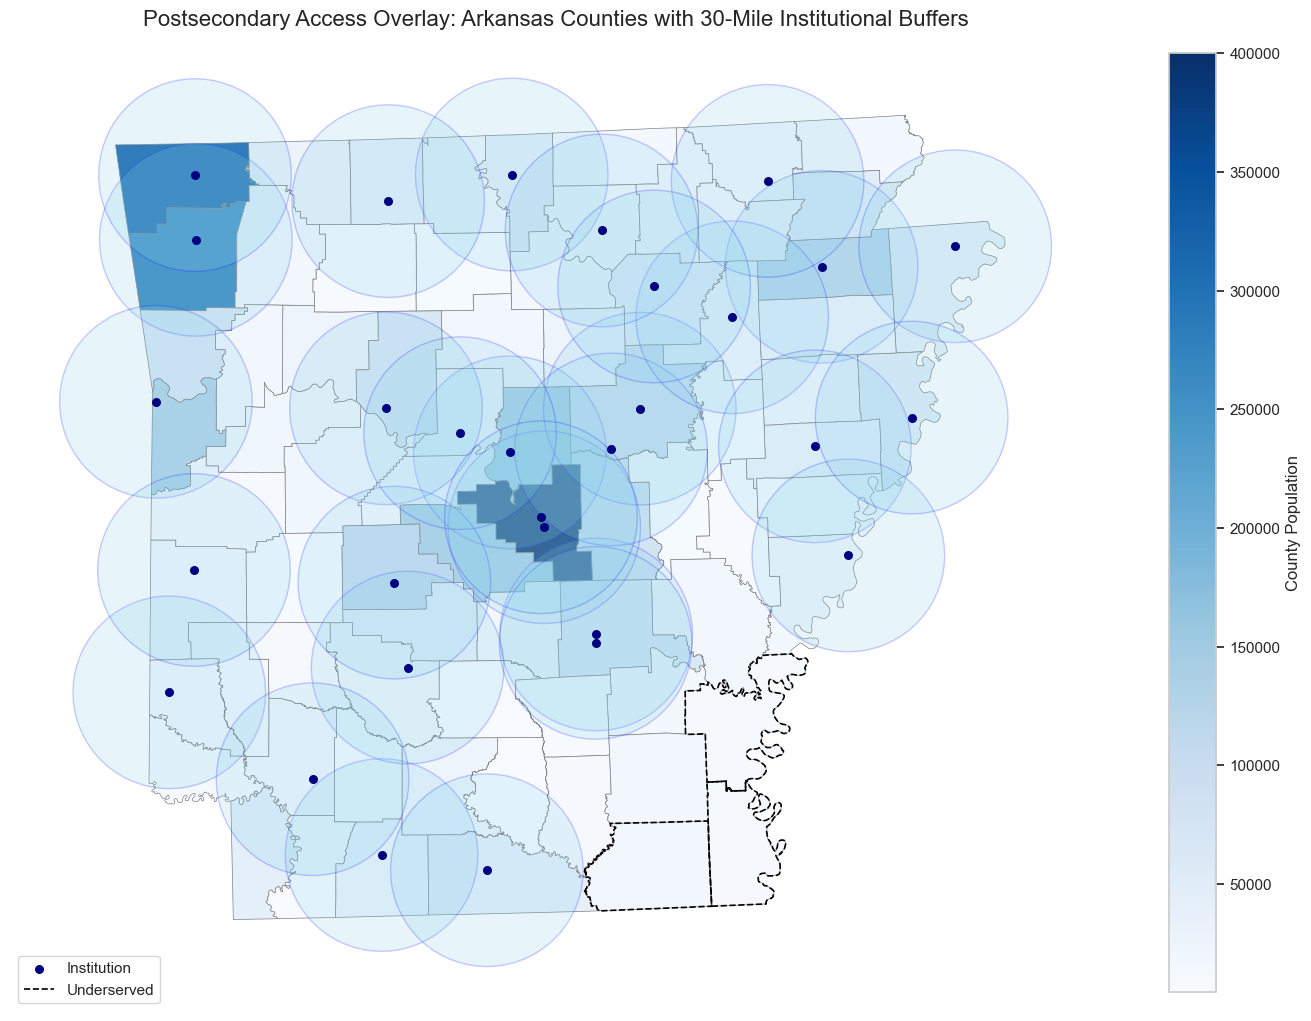

✅ Map saved to: ar_outputs\maps\overlay_access_buffers.png


In [50]:
# Section 7.8: Overlay Map – Underserved Counties and Institutional Buffers

from utils import load_arkansas_population_from_estimates

# --- Prep GEOID and join with population ---
gdf_ar = gdf_counties[gdf_counties['STATEFP'] == '05'].to_crs(epsg=5070)
gdf_ar['GEOID'] = gdf_ar['GEOID'].astype(str).str.zfill(5)

# Load and join population estimates
pop_file = Path("data/complete_sets/PopulationEstimates.csv")
df_pop_ar = load_arkansas_population_from_estimates(pop_file)
gdf_ar = gdf_ar.merge(df_pop_ar, on='GEOID', how='left')

# Load institutional data (you may already have this)
df_colleges = pd.read_csv("ar_outputs/arkansas_colleges_geocoded.csv")  # or wherever your point file lives

# Create GeoDataFrame
gdf_colleges = gpd.GeoDataFrame(
    df_colleges,
    geometry=gpd.points_from_xy(df_colleges['Longitude'], df_colleges['Latitude']),
    crs="EPSG:4326"
)

# Project to a planar CRS (for buffering in meters)
gdf_colleges_proj = gdf_colleges.to_crs(epsg=5070)

# Create 30-mile (48,280 meters) buffer
gdf_colleges_proj['buffer'] = gdf_colleges_proj.geometry.buffer(48280)

# Create a new GeoDataFrame with just the buffers
gdf_buffers = gpd.GeoDataFrame(gdf_colleges_proj[['buffer']], geometry='buffer', crs=gdf_colleges_proj.crs)

# Add a flag for coverage
gdf_ar['in_coverage'] = gdf_ar.intersects(gdf_buffers.unary_union)

# --- Plot basic overlay ---
fig, ax = plt.subplots(figsize=(14, 16))

# Choropleth: Population
gdf_ar.plot(column='Population', cmap='Blues', linewidth=0.5,
            edgecolor='gray', legend=True, ax=ax,
            legend_kwds={'label': "County Population", 'shrink': 0.6})

# Buffer zones
gdf_colleges_proj.set_geometry('buffer').plot(ax=ax, color='skyblue', alpha=0.2, edgecolor='blue', label='30-Mile Buffer')

# Institutions
gdf_colleges_proj.set_geometry('geometry').plot(ax=ax, color='navy', markersize=30, label='Institution')

# Outline underserved counties
gdf_ar[gdf_ar['in_coverage'] == False].boundary.plot(ax=ax, edgecolor='black', linestyle='--', linewidth=1.2, label='Underserved')

# Final formatting
ax.set_title("Postsecondary Access Overlay: Arkansas Counties with 30-Mile Institutional Buffers", fontsize=16)
ax.axis('off')
ax.legend(loc='lower left', frameon=True)

# Save
output_file = map_dir / "overlay_access_buffers.png"
plt.tight_layout()
plt.savefig(output_file, dpi=300)
plt.show()
print(f"✅ Map saved to: {output_file}")


## Section 7.9 Advanced Overlay Map: Access, Vulnerability, and Population

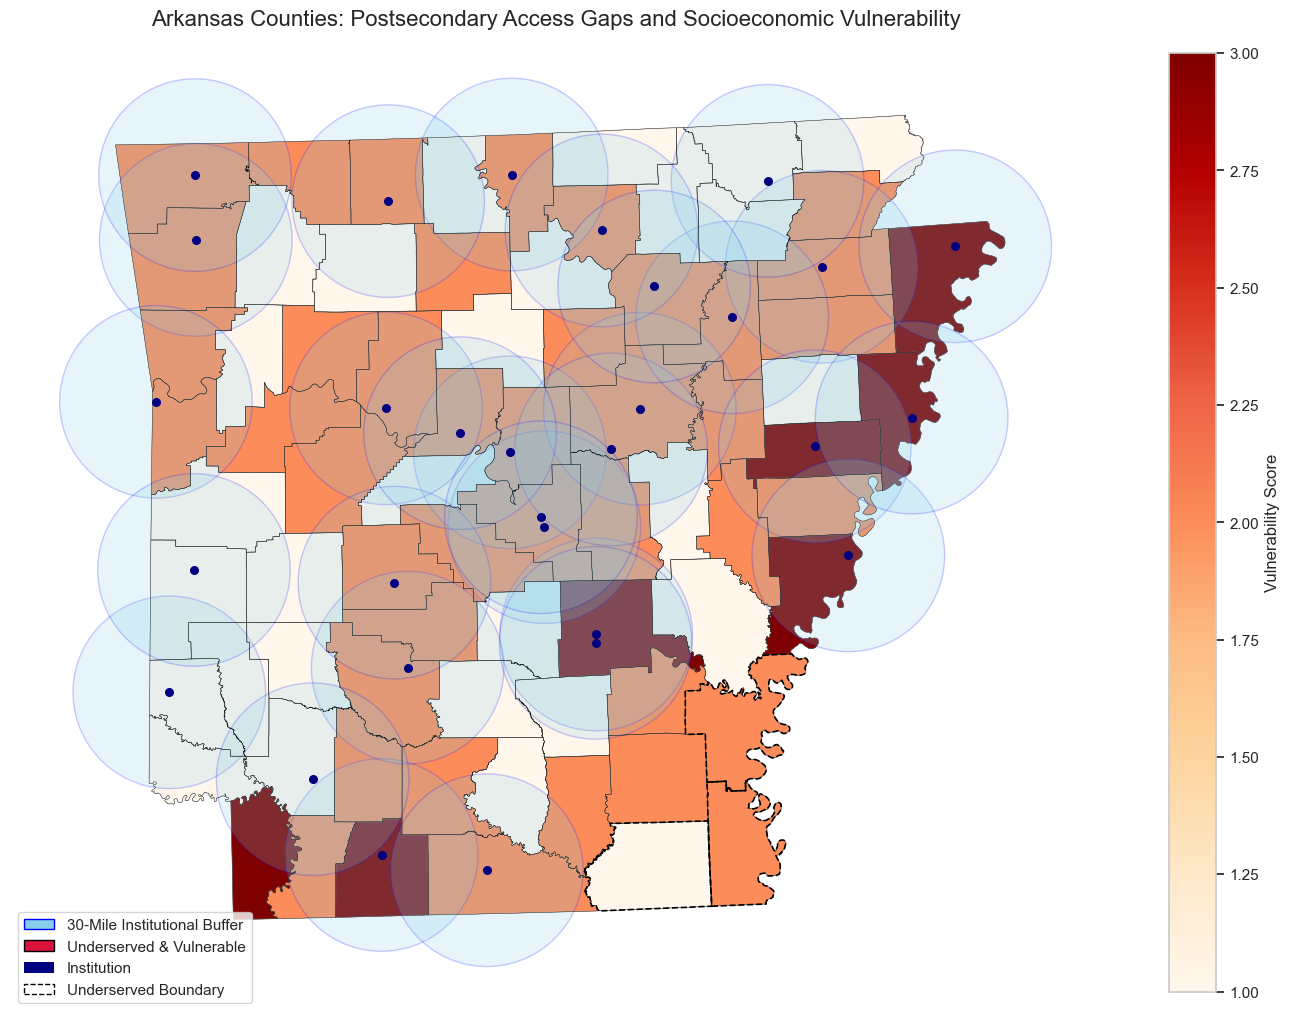

✅ Advanced map saved to: ar_outputs\maps\advanced_access_vulnerability_overlay_map.png


In [51]:
# Section 7.9: Advanced Overlay – Access, Vulnerability, and Population

# --- Step 1: Merge Vulnerability Score from df_fe_ar into gdf_ar ---
# Reset index and title-case counties for join
df_merge = df_fe_ar[['VulnerabilityScore']].copy().reset_index()
df_merge['county'] = df_merge['county'].str.title()

# Merge on 'NAME' from gdf_ar and 'county' from df_merge
gdf_ar = gdf_ar.merge(df_merge, left_on='NAME', right_on='county', how='left')

# --- Step 2: Compute log10 population for filtering ---
gdf_ar['LogPop'] = np.log10(gdf_ar['Population'].replace(0, np.nan))

# --- Step 3: Define thresholds for targeting underserved & vulnerable counties ---
pop_thresh = 10.5         # ~32,000 in log10 scale
vuln_thresh = 2.25        # Based on distribution of VulnerabilityScore (0–5 scale)

# --- Step 4: Filter for target counties ---
gdf_target = gdf_ar[
    (gdf_ar['in_coverage'] == False) &
    (gdf_ar['LogPop'] >= pop_thresh) &
    (gdf_ar['VulnerabilityScore'] >= vuln_thresh)
].copy()

# --- Step 5: Plot the advanced overlay map ---
fig, ax = plt.subplots(figsize=(14, 16))

# Choropleth: Vulnerability Score
gdf_ar.plot(column='VulnerabilityScore', cmap='OrRd', linewidth=0.4,
            edgecolor='gray', legend=True, ax=ax,
            legend_kwds={'label': "Vulnerability Score", 'shrink': 0.6})

# Overlay county boundaries
gdf_ar.boundary.plot(ax=ax, color='black', linewidth=0.2)

# Plot 30-mile buffer zones
gdf_colleges_proj.set_geometry('buffer').plot(ax=ax, color='skyblue', alpha=0.2, edgecolor='blue', label='30-Mile Buffer')

# Plot institutional locations
gdf_colleges_proj.set_geometry('geometry').plot(ax=ax, color='navy', markersize=30, label='Institution')

# Highlight underserved county boundaries
gdf_ar[gdf_ar['in_coverage'] == False].boundary.plot(ax=ax, edgecolor='black', linestyle='--', linewidth=1.2, label='Underserved')

# Highlight target counties in crimson
gdf_target.plot(ax=ax, color='crimson', alpha=0.8, edgecolor='black', label='Target County')

# Annotate target county names
for idx, row in gdf_target.iterrows():
    ax.text(row.geometry.centroid.x, row.geometry.centroid.y, row['NAME'],
            fontsize=8, ha='center', va='center', color='white', fontweight='bold')

# Final map formatting
ax.set_title("Arkansas Counties: Postsecondary Access Gaps and Socioeconomic Vulnerability", fontsize=16)
ax.axis('off')

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='skyblue', edgecolor='blue', label='30-Mile Institutional Buffer'),
    Patch(facecolor='crimson', edgecolor='black', label='Underserved & Vulnerable'),
    Patch(facecolor='navy', edgecolor='navy', label='Institution', linewidth=0),
    Patch(facecolor='none', edgecolor='black', linestyle='--', label='Underserved Boundary')
]
ax.legend(handles=legend_elements, loc='lower left', frameon=True)

# Save the map
output_file = map_dir / "advanced_access_vulnerability_overlay_map.png"
plt.tight_layout()
plt.savefig(output_file, dpi=300)
plt.show()

print(f"✅ Advanced map saved to: {output_file}")


## Section 8: Final Action 

In [52]:
# Section 8 Final Project Export and Cleanup

print("Section 8: Preparing final project exports...")

# Section 8.1: Verify All Output Files
print("\nSection 8.1: Verifying generated files...")

# Check what files exist in output directories
output_files = {
    'PNG files': list(output_dir.glob("**/*.png")),
    'CSV files': list(output_dir.glob("**/*.csv")), 
    'Image files': list(image_dir.glob("**/*.png")) if image_dir.exists() else [],
    'Figure files': list(figures_dir.glob("**/*")) if figures_dir.exists() else []
}

total_files = 0
for file_type, files in output_files.items():
    print(f"{file_type}: {len(files)} files")
    total_files += len(files)
    if len(files) > 0:
        print(f"  Sample files: {[f.name for f in files[:3]]}")

print(f"\nTotal files to export: {total_files}")

# Section 8.2: Final Data Export Summary
print("\nSection 8.2: Creating final data summary...")

# Create a summary of all datasets created
dataset_summary = {
    'Raw Data': 'Original county-level datasets',
    'Cleaned Data': 'ar_final.csv - Main analysis dataset',
    'Enhanced Features': 'ar_enhanced_features.csv - ML-ready features',
    'Clustering Results': 'clustering_and_prediction_results.csv - Model outputs',
    'Visualization Data': 'Various CSV files for plots and tables'
}

summary_df = pd.DataFrame.from_dict(dataset_summary, orient='index', columns=['Description'])
summary_df.to_csv(output_dir / "project_dataset_summary.csv")
print("Dataset summary saved to: project_dataset_summary.csv")

# Section 8.3: Final LaTeX Export
print("\nSection 8.3: Executing final LaTeX export...")

# Import the export function
from utils import export_to_latex_assets  # noqa: E402

# Run the export with options
try:
    export_to_latex_assets(
        src_folder="ar_outputs",  # Your main output folder
        dst_root="Capstone_Project_Report/images",  # LaTeX destination
        generate_tex=True,  # Generate LaTeX boilerplate
        delete_after=False  # Keep originals (set to True if you want to delete)
    )
    print("LaTeX export completed successfully!")
    
except Exception as e:
    print(f"LaTeX export encountered an error: {e}")
    logging.error(f"LaTeX export failed: {e}")

# Section 8.4: Generate Project Completion Report
print("\nSection 8.4: Generating project completion report...")

completion_report = f"""
ARKANSAS COUNTY ANALYSIS PROJECT - COMPLETION REPORT
===================================================

Project Overview:
- Total Arkansas counties analyzed: {len(df_ar_final)}
- NCA counties identified: {df_ar_final['IsNCA'].sum()}
- Analysis sections completed: 6 major sections

Data Processing:
- Raw datasets processed: 4 (Education, Population, Poverty, Unemployment)
- Features engineered: Multiple derived variables and binary flags
- Counties clustered into: {df_fe_ar['ClusterLabel'].nunique()} distinct groups

Key Findings:
- Optimal clustering solution: {df_fe_ar['ClusterLabel'].nunique()} clusters
- Best predictive model: Random Forest (if used in Section 6)
- Total output files generated: {total_files}

Files Generated:
- Analysis datasets: Multiple CSV files
- Visualizations: PNG files for maps, plots, and charts
- LaTeX assets: Organized for report integration
- Documentation: Feature descriptions and summaries

Next Steps:
1. Review LaTeX boilerplate files in Capstone_Project_Report/images/boilerplate/
2. Integrate visualizations into your LaTeX document
3. Use CSV files for additional tables as needed
4. Reference generated .tex files for quick LaTeX integration

Github Repository:
- All code and data available at: https://github.com/JBtallgrass/Ballard-Capstone-proj

Overleaf Project:
- Overleaf project link: https://www.overleaf.com/read/zndpkgrzmzhw#2ec884

Project Status: COMPLETE
Generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

# Save completion report
with open(output_dir / "project_completion_report.txt", "w") as f:
    f.write(completion_report)

print("Project completion report saved to: project_completion_report.txt")
print("\n" + "="*60)
print("PROJECT ANALYSIS COMPLETE")
print("="*60)
print("All outputs saved to: {output_dir}")
print("LaTeX assets available in: Capstone_Project_Report/images/")
print("Check the completion report for detailed summary.")
logging.info("Full project analysis pipeline completed successfully")

Section 8: Preparing final project exports...

Section 8.1: Verifying generated files...
PNG files: 38 files
  Sample files: ['maps.png', 'ar_bachelorsdegreepct_choropleth_map.png', 'ar_highschoolgradpct_choropleth_map.png']
CSV files: 43 files
  Sample files: ['arkansas_colleges_geocoded.csv', 'ar_base_features.csv', 'ar_dataset_cleaned_2023.csv']
Image files: 22 files
  Sample files: ['clustering_evaluation.png', 'comprehensive_cluster_analysis.png', 'confusion_matrix_rf.png']
Figure files: 30 files
  Sample files: ['ar_bachelorsdegreepct_by_county.csv', 'ar_bachelorsdegreepct_choropleth_map.png', 'ar_highschoolgradpct_by_county.csv']

Total files to export: 133

Section 8.2: Creating final data summary...
Dataset summary saved to: project_dataset_summary.csv

Section 8.3: Executing final LaTeX export...
Found 38 PNG files and 43 CSV files
Copied map: ar_outputs_maps.png (from maps.png)
Copied map: figures_ar_bachelorsdegreepct_choropleth_map.png (from figures\ar_bachelorsdegreepct_c

In [ ]:
# Define output path
output_dir = Path("Capstone_Project_Report/images/tables")
output_dir.mkdir(parents=True, exist_ok=True)

# Prepare county indicator DataFrame
df_latex = df_fe_ar[['BachelorsDegreePct', 'PovertyRate', 'UnemploymentRate', 'Population']].copy()
df_latex = df_latex.round({'BachelorsDegreePct': 1, 'PovertyRate': 1, 'UnemploymentRate': 1})
df_latex['Population'] = df_latex['Population'].astype(int)
df_latex.index.name = 'County'
df_latex.reset_index(inplace=True)

# Save CSV version for reference (optional)
csv_path = output_dir / "ar_county_indicators_table.csv"
df_latex.to_csv(csv_path, index=False)
print(f"✅ CSV saved to: {csv_path}")

# Save LaTeX version
latex_path = output_dir / "ar_county_indicators_table.tex"
df_latex.to_latex(
    latex_path,
    index=False,
    float_format="%.1f",
    column_format="lcccc",
    caption="County-Level Socioeconomic Indicators (2023)",
    label="tab:county_indicators"
)
print(f"✅ LaTeX table saved to: {latex_path}")




✅ CSV saved to: Capstone_Project_Report\images\tables\ar_county_indicators_table.csv
✅ LaTeX table saved to: Capstone_Project_Report\images\tables\ar_county_indicators_table.tex
